# Simulation of 'DNA chains on a substrate imaged via AFM'
**This notebook is intended to create simulations of DNA chain relaxation on a substrate imaged via AFM. By simulating physical relaxation and electrostatic attraction between a DNA chain and the substrate it allows users to generate high fidelity data.**

This notebook generates a complete dataset stored within user defined directory `OUT_DIR`, primarily consisting of Synthetic AFM Images saved as `.npy` raw heightmap data (incorporating realistic noise from `.spm` blanks or PSD models) and optional `.png` files for quick visual inspection.

 To support machine learning workflows, the pipeline produces DNA Segmentation Masks in `.npy` format for pixel-wise background separation, alongside specialized Crossing Detection Masks that use Gaussian-weighted targets to highlight molecular intersections. Comprehensive Metadata for every sample, including bead counts and mechanical parameters, is saved in `.csv` or `.json` files, all of which are indexed in a central **manifest.csv** that links each generated image to its corresponding ground-truth masks and input configurations.
>
---
**Cell execution order:** run cells 1 → 12 in sequence.  
Cells 1–9 define functions and globals. Cell 10 is the sanity check. Cell 11 is used for benchmarking the time for execution and generation of the dataset. Cell 12 generates the full dataset.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/Prakhar-Dutta/ASAP/blob/1b5cfc5173e1bed4e59575e6dd4724cb20682620/tutorial/Not_final_version_DNA_notebook%20(1).ipynb)

In [1]:
from __future__ import annotations

# Uncomment codes in this cell if using Colab/Kaggle.
import os
from pathlib import Path
import re
import csv
import traceback
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
from typing import Any
# Image processing
from scipy.ndimage import (
    gaussian_filter, grey_dilation, distance_transform_edt,
    binary_dilation, median_filter, affine_transform, zoom
)

# 1. **With or without molecular dynamics?**
## 1.1. Imports

This notebook allows two possible ways of building the simulated DNA chains; with or without the use of **coarse-grained molecular dynamics**. Molecular dynamics based simulations are computationally expensive, but provide closeness to real AFM imaging. For users who would like to use molecular dynamics, they would need to import all the libraries that will be necessary for simulation of the images.

In [65]:
# Install dependencies (uncomment in a fresh environment / Colab)
# Chain generation mode
USE_MD = True  # True → OpenMM Langevin dynamics
               # False → fast 2-D persistent-walk (no OpenMM needed)
# Molecular dynamics
!pip3 install -q scipy matplotlib pillow
if USE_MD:
  !pip3 install openmm[cuda12]
# change the cuda version
# depending on the CUDA version available on your system.
# Ensure that CUDA can be accessed by OpenMM when running locally.
  import openmm
  import openmm.unit as unit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.4/14.4 MB 41.4 MB/s eta 0:00:00


# 1.2 Defining the variables
Here we define the variables that will be used for the generation of the images and the masks. The variables control how the images and their masks will appear at the end. For training a Machine learning network like a U-Net, all images need to be of a standard size and need reproducible properties. To generate the likeness of DNA chains from simulated data, we start with building a chain by using a random walk in 3D with some set parameters like number of beads, bond length and persistence bonds and to simulate chain relaxation on substrate we raise the chain to a certain height.

In [66]:
# ─────────────────────────────────────────────────────────────────────────────
# Global settings
#(these are the variables that need to be changed
# to change the appearance of the resulting images)
# ─────────────────────────────────────────────────────────────────────────────

# Dataset
OUT_DIR       = "dna_dataset_100_4lengths_MD"
# Name of the output directory that you would like to store your data in
N_SAMPLES     = 50
# Number of samples that will be generated
BASE_SEED     = 1
# Seed for reproducibility

# Image resolution
NX = 512
NY = 512

# Ring + MD
N_BEADS           = 90
# default bead count for vizualization via chain creation cell
BEAD_COUNTS       = [70, 80, 90, 100]
# four chain lengths that will be created in the dataset
#(1 bead corresponds to 10 base pairs on DNA approximately)
BOND_LENGTH       = 1.0
# distance between beads
PERSISTENCE_BONDS = 23.0
# used to determine the range of angles which the chain is allowed to turn
K_ANGLE           = 12.0
# used to determine the angular stiffness during relaxation
# (higher means more stiffness)
BASE_Z            = 5.0
# Height above the substrate that the chain starts at before relaxing

ANGLE_STIFNESS_MULT = 0.4
# If USE_MD is False, then angle stiffness multiplier controls
# chain propogation through space

# MD recording
N_FRAMES         = 200
STEPS_PER_FRAME  = 200
# Between every frame local energy minimization happens for
#the given number of steps

# AFM rendering

tip_radius = 1
# Please select the tip radius here (Ideal range is 1nm-5nm)
nm_per_px  = 2
# Internal AFM render sampling in nm / pixel before downsampling

AFM_KW = dict(
    nx=NX, ny=NY,
    dna_diameter_nm=2.0,
    # mapping to physical values
    tip_radius_nm=0.01*tip_radius,
    # Scaling factor is applied for internal control to match
    max_height_nm=6.0,
    # Maximum height for the colorbar
    target_nm_per_px=0.04*nm_per_px,
    # Scaling factor (0.04) is applied for internal control
    max_radius_px=96,
    # upper limit for the size of the chain in pixels
    radius_shrink_px=0.0,
    # Set to 0 so that rendering can match physical values
    final_blur_sigma_px=0.20,
    # When changing tip radius and nm_per_px to observe the expected
    apply_edge_taper=True,
    # physical effect, remove the scaling factors (0.04) for
    # tip_radius_nm and target_nm_per_px
    taper_sigma_nm=0.45,
    # and scale all other parameters accordingly.
    taper_floor=0.10,
    add_center_ridge=True,
    ridge_sigma_nm=0.25,
    # This controls width of center ridge
    ridge_amp_nm=0.25,
    # This controls height of center ridge
    grain_nm=0.0,
    # This adds more noise to the chain
    grain_sigma_px=0.6,
    enable_crossing_boost=True,
    # To boost the height of the crossings
    min_separation_beads=12,
    # Distance to other chain segments to not boost indiscriminately
    boost_window_beads=2,
    # How many beads to boost the height for
    guaranteed_offset_nm=1.0,
    # How much to boost
    boost_method="additive",
    # add to the height of beads being boosted
    boost_profile="gaussian",
    # Height increase profile
    boost_sigma_beads=None,
    far_clip_nm=2.5,
    # Clip bead heights for beads that are not part of a crossing
    far_clip_window_beads=3,
    # How many beads to clip the height for
    return_crossing_info=True,
    # To ensure that mask information is passed to other functions.
    # Change to False if masks are not needed
    return_masks=True,
)


#-------------------------------------
# DNA mask
DNA_MASK_DILATE_PX = 3
# Dilation of mask for better training
#-------------------------------------

#---------------------------
# Crossing mask
CROSS_MIN_SEP_BEADS   = 12
# Where to stop for the crossing calculation
CROSS_SIGMA_CENTER_PX = 5.0
# How many pixels make up the center of a crossing
CROSS_SIGMA_PERP_PX   = 1.8
# Crossing coloring parameter (how many pixels to modulate for the crossing)
CROSS_CHAIN_EXTENT    = 5.0
# For the chain weighting of the mask
CROSS_CENTER_WEIGHT   = 1.7
# For the chain weighting of the mask (chain-weighted guassian)
CROSS_CHAIN_WEIGHT    = 0.9
CROSS_CLIP_TO_DNA_MASK = True
#---------------------------

#Checking if output directory will be created
os.makedirs(OUT_DIR, exist_ok=True)
for _sub in ["images", "dna_masks", "cross_masks", "meta"]:
    os.makedirs(os.path.join(OUT_DIR, _sub), exist_ok=True)

print("Output folder:", os.path.abspath(OUT_DIR))

Output folder: /content/dna_dataset_100_4lengths_MD


# 1.3 Noise
To add realistic noise to the images so that they closely resemble real AFM images, 2 options have been provided in this notebook.


1. For users that have access to AFM imaging setups and substrates, a **blank ``.spm``** file can be loaded into this enviroment. The blank file is a scan of the substrate **without** the sample of interest. The notebook will parse through the file and add the noise that would appear as if a DNA chain were imaged on that substrate, thus making the output dataset closer to real DNA if it were to be imaged on that setup and substrate.
2. For users that do not have access to AFM imaging setups or available blanks, noise can be generated through an ensemble of blanks that were imaged on nickel susbtrates and processed. The information of that noise is available as a Power spectral density noise model that is available in this repository. There are 3 noise synthesis models offered but *mean_full2d* is preferred and chosen as the default.



In [67]:
#Noise
TARGET_NOISE_RMS_NM   = 0.27
# This variable controls the height of the noise
# in nanometers and this is added to the final image


# Blank SPM noise
USE_BLANK_SPM_NOISE   = True
USE_PLANE_REMOVE      = True
# This flag is used to control plane tilt removal from the noise image
USE_LINE_FLATTEN      = True
# This flag is used to control line flattening (median filtering)
# from the noise image
USE_BANDPASS_FILTER   = True
# This flag is used to control bandpass filtering on the noise image
BLANK_SPM_PATH        = "/content/20240411_blank_water.0_00000.spm"
# optional; if missing/invalid, PSD fallback noise is used
# Change path when running locally. If using Colab, upload the file


# PSD-model fallback noise (used when blank .spm file is not available)
USE_PSD_NOISE_FALLBACK = True
MODEL_PATH             = "/content/psd_noise_model.npz"
# Change path when running locally. If using Colab, upload the noise file
PSD_NOISE_METHOD       = "mean_full2d"
# or "lognormal_full2d" / "empirical_radial"
PSD_NOISE_STD_SCALE    = 2.0


## 2. Chain Creation (3-D Persistent Random Walk)
Now we start with creating the DNA chain. This is the toppology of the chain before relaxation is performed using molecular dynamnics.

The function `make_tangled_ring_initial` builds a closed polymer ring via a persistent random walk and enforces ring-closure.

A 3-D plot is shown at the end of the cell so you can inspect the initial geometry immediately.

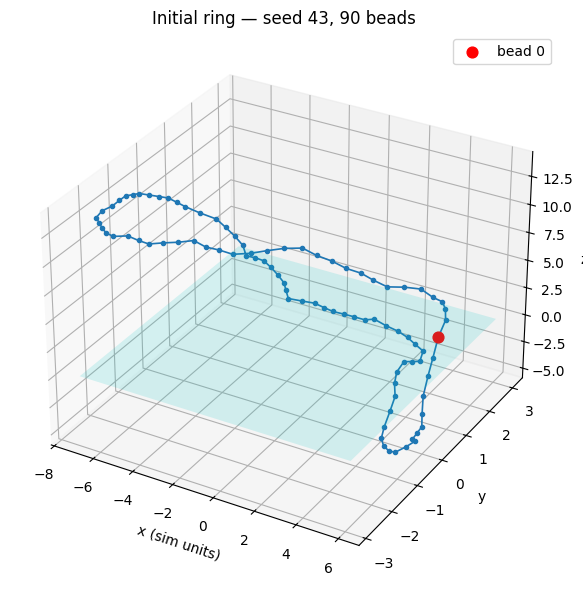

In [68]:
def make_tangled_ring_initial(
    seed: int,
    n_beads: int = N_BEADS,
    bond_length: float = BOND_LENGTH,
    persistence_bonds: float = PERSISTENCE_BONDS,
    base_z: float = BASE_Z,
)-> np.ndarray:
    """Generates a closed (ring) polymer with a persistent random-walk tangent.

    Each step rotates the current direction by a small random angle around a
    perpendicular axis.  Ring closure is enforced by linearly distributing
    the end-to-end gap across all beads. The chain is then lifted to base_z
    so it can relax down to the z=0 substrate during MD.

    Parameters
    ----------
    seed : int
        random seed for reproducibility
    n_beads : int, optional
        number of beads in the polymer ring. Defaults to N_BEADS.
    bond_length : float, optional
        the distance between consecutive beads. Defaults to BOND_LENGTH.
    persistence_bonds : float, optional
        the number of beads used to enforce persistence length in the chain.
        Defaults to PERSISTENCE_BONDS.
    base_z : float
        the height to lift the chain above the substrate. Defaults to BASE_Z.

    Returns
    -------
    Returns a list of [coords] with shape (N, 3).

    """

    rng = np.random.default_rng(int(seed))

    steps = np.zeros((n_beads, 3), dtype=np.float32)
    #Initialization of vector for chain propogation
    vec   = np.array([1.0, 0.0, 0.0], dtype=np.float32)

    for k in range(n_beads):
        dtheta = rng.normal(scale=np.sqrt(1.0 / persistence_bonds))
        #choose an axis at random for chain propogation in 3D
        axis   = rng.normal(size=3).astype(np.float32)
        # remove component along vec
        axis  -= axis.dot(vec) * vec
        axis_norm = np.linalg.norm(axis)
        # failsafe
        if axis_norm < 1e-8:
            axis      = np.array([0.0, 0.0, 1.0], dtype=np.float32)
            axis_norm = 1.0
        axis /= axis_norm
        # Calculating vector for chain propogation
        vec   = vec * np.cos(dtheta) + np.cross(axis, vec) * np.sin(dtheta)
        vec  /= np.linalg.norm(vec)
        steps[k] = bond_length * vec

    coords = np.cumsum(steps, axis=0) # Coordinates for open chain

    # Enforce ring closure
    closure_error = coords[-1] - coords[0]
    # Based on the distance between first and last bead a
    # closure error is propogated to all bead positions to form a closed chain
    t      = np.linspace(0, 1, n_beads, dtype=np.float32).reshape(-1, 1)
    coords -= t * closure_error
    coords -= coords.mean(axis=0)

    # Lift above substrate
    # (z values are changed to lift the chain off the substrate)
    coords[:, 2] += float(base_z)
    return coords.astype(np.float32)


# ── Quick visualisation ──────────────────────────────────────────────────────
demo_coords = make_tangled_ring_initial(seed=43)
cc = np.vstack([demo_coords, demo_coords[0]])  # close the ring for plotting

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.plot(cc[:, 0], cc[:, 1], cc[:, 2], "-o", markersize=3, linewidth=1.2)
ax.scatter(cc[0, 0], cc[0, 1], cc[0, 2], color="red",
           s=60, zorder=5, label="bead 0")

# Draw substrate plane
xs = np.linspace(cc[:, 0].min(), cc[:, 0].max(), 2)
ys = np.linspace(cc[:, 1].min(), cc[:, 1].max(), 2)
X, Y = np.meshgrid(xs, ys)
ax.plot_surface(X, Y, np.zeros_like(X), alpha=0.15, color="cyan")

ax.set_xlabel("x (sim units)"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"Initial ring — seed 43, {len(demo_coords)} beads")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Molecular Dynamics Relaxation
To accurately mimic chain relaxation on a susbstrate a coarse grained molecular dynamics simulation is performed using OpenMM (no water or other molecules simulated). If Molecular dynamics is not needed, please skip this cell.

The function `run_md_relaxation` runs a Langevin-dynamics simulation in the overdampled regime via OpenMM.
Here we have added:

1. Harmonic bonds
2. Bending-angle stiffness
3. A surface-attraction to cause chain relaxation
4. A hard-wall force to keep chain above substrate
5. A short-range WCA repulsion to ensure chain does not take non physical configurations

The function then records `n_frames` snapshots which can be used for visualization.

We start with testing the OpenMM installation (can be tricky at times)

In [ ]:
# Test the OpenMM installation before running the following cell
# to ensure that GPU acceleration will work
import openmm.testInstallation

# Run the standard OpenMM installation test to check for CUDA/GPU support
try:
    openmm.testInstallation.main()
except Exception as e:
    print(f"Test failed: {e}")

And then once we are sure that OpenMM is correctly installed, we run the MD functions

In [69]:
def run_md_relaxation(
    coords0: np.ndarray,
    seed: int,
    n_frames: int = N_FRAMES,
    steps_per_frame: int = STEPS_PER_FRAME,
)-> list[np.ndarray]:
    """
    Takes initial bead coordinates and runs Langevin dynamics using OpenMM

    This function uses the coordinates generated using the
    `make_tangled_ring_initial` function to run a molecular dynamics
    simulation. There are certain forces that are defined and applied to the
    bead which are then resolved using OpenMM.
    The forces applied are:
    - Harmonic bonds + angle stiffness along the ring
    - Surface attraction (linear in z) + hard wall at z = 0
    - Short-range Weeks–Chandler–Andersen (WCA)
      repulsion between non-bonded beads
    Drift removal is also performed using OpenMM's CMMotionRemover.
    The variable langevin integrator from OpenMM is used and the forces are
    resolved for 'steps_per_frame' steps for every frame in n_frames.

    Parameters
    ----------
    initial_coordinates : np.ndarray
        The starting [x, y, z] coordinates of the polymer beads.
    seed : int
        Random seed for the Langevin integrator.
    num_frames : int, optional
        Number of frames to record during the simulation. Defaults to N_FRAMES.
    steps_per_frame : int, optional
        Number of integration steps to perform between recorded frames.
        Defaults to STEPS_PER_FRAME.

    Returns
    -------
    A list of coordinate arrays of shape (num_beads, 3). The list contains
    num_frames + 1 entries, where frame 0 is the pre-minimization geometry.

    Raises
    ------
    RuntimeError
        If no OpenMM platform (CUDA, OpenCL, or CPU) could be initialised.

    Examples
    --------
    >>> frames  = run_md_relaxation(_anim_coords0, seed=1, n_frames=N_FRAMES,
                                    steps_per_frame=STEPS_PER_FRAME)
    >>> print({len(frames), frames[0].shape})
    {11, (100, 3)}

    """

    coords0 = np.asarray(coords0, dtype=np.float32)
    n       = int(coords0.shape[0])

    # how big the bounding box for the molecular dynamics needs to be
    extent = (coords0.max(axis=0) - coords0.min(axis=0)).max()
    box    = float(extent + 10.0)


    # All lengths in nm, energies in kJ/mol.
    BOLTZ_kJmol    = 0.00831445 # kJ / (mol · K)
    temperature    = 1.0 # K  (sets energy scale kT ≈ 0.0083 kJ/mol)
    kT             = BOLTZ_kJmol * temperature # kJ/mol
    conlen         = 1.0 # nm
    mass_amu       = 100.0 # Da per bead
    collision_rate = 0.6 # ps⁻¹
    error_tol      = 0.005

    # ── Build system ─────────────────────────────────────────────────────────
    system = openmm.System()
    system.setDefaultPeriodicBoxVectors(
        openmm.Vec3(box, 0, 0),
        openmm.Vec3(0, box, 0),
        openmm.Vec3(0, 0, box),
    )
    for _ in range(n):
        system.addParticle(mass_amu)

    # Remove COM drift — applied every 50 steps
    system.addForce(openmm.CMMotionRemover(10))
    # To ensure CPU and GPU calculation are consistent
    # (since GPU minimizations calculations can suffer from drift)

    # ── 1. Harmonic bonds ────────────────────────────────────────────────────

    # OpenMM HarmonicBondForce: E = (k/2)·(r − r0)²  →  k = kT / wiggle²
    bond_L = BOND_LENGTH          # nm
    wiggle = 0.1                  # nm  (bondWiggleDistance)
    k_bond = kT / (wiggle ** 2)   # kJ/mol/nm²

    bond_force = openmm.HarmonicBondForce()
    bond_force.setUsesPeriodicBoundaryConditions(True)
    for i in range(n):
        bond_force.addBond(i, (i + 1) % n, bond_L, k_bond)
    system.addForce(bond_force)

    # ── 2. Bending (angle) stiffness ─────────────────────────────────────────
    # E = kT · k_angle · (1 − cos(θ − π))  — equilibrium at θ = π (straight)
    k_angle     = K_ANGLE
    angle_force = openmm.CustomAngleForce(
        "kT * kangle * (1 - cos(theta - 3.141592653589793))"
    )
    angle_force.addGlobalParameter("kT",     kT)
    angle_force.addGlobalParameter("kangle", k_angle)
    for i in range(n):
        angle_force.addAngle((i - 1) % n, i, (i + 1) % n, [])
    system.addForce(angle_force)

    # ── 3. Surface: linear attraction (z > 0) + harmonic hard wall (z < 0) ───
    wall_expr = (
        "kT * ("
        "  F_pull * z * step(z) + "
        "  0.5 * wallK * (z^2) * step(-z)"
        ")"
    )
    wall_force = openmm.CustomExternalForce(wall_expr)
    wall_force.addGlobalParameter("kT",     kT)
    wall_force.addGlobalParameter("F_pull", 9.0)
    wall_force.addGlobalParameter("wallK",  100.0)
    for i in range(n):
        wall_force.addParticle(i, [])
    system.addForce(wall_force)

    # ── 4. WCA repulsion (repulsion between non-bonded pairs only) ───────────
    rep_sigma  = 1.6 * conlen   # nm
    rep_cutoff = 2.3 * conlen   # nm
    rep_expr   = (
        "4*eps * ( (sig / (r + shift))^12 - (sig / (r + shift))^6 + 0.25 )"
        "* step(cutoff - r);"
        "cutoff = 2^(1.0/6.0) * sig"
    )
    rep_force = openmm.CustomNonbondedForce(rep_expr)
    rep_force.setNonbondedMethod(openmm.CustomNonbondedForce.CutoffPeriodic)
    rep_force.setCutoffDistance(rep_cutoff)
    rep_force.addGlobalParameter("eps", 1.7 * kT)
    rep_force.addGlobalParameter("sig", rep_sigma)
    rep_force.addGlobalParameter("shift", 1e-8)
    for i in range(n):
        rep_force.addParticle([])
    # exclude bonded neighbours
    for i in range(n):
        rep_force.addExclusion(i, (i + 1) % n)
    system.addForce(rep_force)

    # ── Integrator ───────────────────────────────────────────────────────────
    integrator = openmm.VariableLangevinIntegrator(temperature,
                                                   collision_rate, error_tol)
    integrator.setRandomNumberSeed(int(seed))

    # ── Platform selection: OpenCL → CPU fallback ────────────────────────────
    context = None
    # OpenCL enables Mac users to be able to use GPU acceleration as well
    for platform_name in ("CUDA","OpenCL","CPU"):
        try:
            platform = openmm.Platform.getPlatformByName(platform_name)
            context  = openmm.Context(system, integrator, platform)
            print(f"Using {platform_name} platform.")
            break
        except openmm.OpenMMException as e:
            print(f"  {platform_name} unavailable: {e}")
        except Exception as e:
            print(f"  {platform_name} failed unexpectedly: {e}")

    if context is None:
        raise RuntimeError("No OpenMM platform could be initialised.")

    # ── Set initial positions and box ────────────────────────────────────────
    positions = [
        openmm.Vec3(float(coords0[i, 0]),
                    float(coords0[i, 1]), float(coords0[i, 2]))
        for i in range(n)
    ]
    context.setPositions(positions)
    context.setPeriodicBoxVectors(
        openmm.Vec3(box, 0, 0),
        openmm.Vec3(0, box, 0),
        openmm.Vec3(0, 0, box),
    )

    # Capture the true initial geometry before any minimisation
    # (just in case the chain reaches substrate even before the 1st frame)
    frames = []
    state = context.getState(getPositions=True)
    pos   = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    frames.append(pos.copy())

    # Cap iterations
    openmm.LocalEnergyMinimizer.minimize(context,
                                         tolerance=50, maxIterations=200)

    # ── Record frames ────────────────────────────────────────────────────────
    for _ in range(int(n_frames)):
        integrator.step(int(steps_per_frame))
        state = context.getState(getPositions=True)
        pos   = state.getPositions(asNumpy=True).value_in_unit(unit.nanometer)
        frames.append(pos.copy())

    return frames   # n_frames + 1 entries (frame 0 = initial geometry)

## 4. Non-MD chain generation
In case you would not like to use molecular dynamics to generate the chains, it is also possible to skip the molecular dynamics and just use a simple 2D persistent walk to generate the DNA chains. The chains generated by this method might have some non physical configurations but the propoerties of the function can be modulated to achieve desired results.

In [6]:
def make_ring_2d_persistent_initial(
    seed: int,
    n_beads: int,
    bond_length: float = BOND_LENGTH,                  # From Cell 1
    persistence_bonds: float = PERSISTENCE_BONDS,      # From Cell 1
    angle_stiffness_mult: float = ANGLE_STIFNESS_MULT, # From Cell 1
    # Small Gaussian noise for Z
    z_std: float = 0.08,
    # Low altitude for "deposited" look
    base_z: float = 0.2,
    # Acts as a soft per-step cap
    angle_limit: float = np.pi/2,
) -> list[np.ndarray]:
    """
    Generate a closed 2D persistent ring and return it as [coords].

    The function builds a periodic sequence of turning angles, smooths the
    sequence to suppress sharp corners, and enforces total turning to ensure
    the tangent field is compatible with a closed loop. The resulting curve is
    resampled by arc length to maintain uniform bead spacing.

    Parameters
    ----------
    seed : int
        Random seed for reproducibility.
    num_beads : int
        Number of beads in the polymer ring.
    bond_length : float, optional
        The desired distance between consecutive beads.
        Defaults to BOND_LENGTH.
    persistence_bonds : float, optional
        Stiffness parameter; larger values result in a smoother ring with
        longer directional memory. Defaults to PERSISTENCE_BONDS.
    angle_stiffness_multiplier : float, optional
        Multiplier for angular fluctuations; larger values result in
        smaller fluctuations. Defaults to ANGLE_STIFNESS_MULT.
    z_standard_deviation : float, optional
        Standard deviation for the Gaussian noise applied to the z-axis.
        Defaults to 0.08.
    base_z : float, optional
        The baseline altitude for the deposited coordinates. Defaults to 0.2.
    angle_limit : float, optional
        A soft cap on local turning increments (radians). Defaults to np.pi/2.

    Returns
    -------
    coords : np.ndarray
        Array of shape (N, 3) containing the [x, y, z] coordinates

    Raises
    ------
    ValueError
        If num_beads is less than 6 or if the generated ring has zero
        contour length.

    Examples
    --------
    >>> coords = make_ring_2d_persistent_initial(seed=42)
    >>> print(coords.shape)
    (90, 3)

    """

    rng = np.random.default_rng(int(seed))
    n = int(n_beads)
    if n < 6:
        raise ValueError("n_beads must be at least"
                         "6 for a stable closed persistent ring.")

    bond_length = float(bond_length)

    # ------------------------------------------------------------------
    # 1) Build a periodic turning-angle process on the ring
    # ------------------------------------------------------------------

    # larger persistence_bonds / angle_stiffness_mult => less angular noise
    sigma_dtheta = (
        np.sqrt(2.0 / max(float(persistence_bonds), 1.0))
        / max(float(angle_stiffness_mult), 1e-6)
    )

    # Raw local turning increments
    dtheta = rng.normal(0.0, sigma_dtheta, size=n).astype(np.float64)
    dtheta = np.clip(dtheta, -float(angle_limit), float(angle_limit))

    # Circular smoothing of turning increments to suppress sharp local corners.
    # Stronger persistence / stiffness => broader smoothing.
    smooth_width = int(np.clip(np.round(max(float(persistence_bonds), 1.0)
                       / 6.0), 1, 8))
    if smooth_width > 0:
        offsets = np.arange(-smooth_width, smooth_width + 1, dtype=np.float64)
        kernel_sigma = max(smooth_width / 2.0, 1e-6)
        kernel = np.exp(-0.5 * (offsets / kernel_sigma) ** 2)
        kernel /= kernel.sum()

        dtheta_smooth = np.zeros_like(dtheta)
        for shift, w in zip(offsets.astype(int), kernel):
            dtheta_smooth += w * np.roll(dtheta, shift)
        dtheta = dtheta_smooth

    # Enforce exact total turning of 2*pi for a closed planar ring.
    # This avoids the nonphysical post hoc closure drift used before.
    total_turn = dtheta.sum()
    dtheta += (2.0 * np.pi - total_turn) / n

    # Re-clip gently after correction, then re-enforce total turning once more.
    dtheta = np.clip(dtheta, -float(angle_limit), float(angle_limit))
    dtheta += (2.0 * np.pi - dtheta.sum()) / n

    # ---------------------------------------------------------------------
    # 2) Build periodic tangent angles and integrate to a dense closed path
    # ---------------------------------------------------------------------
    theta0 = rng.uniform(0.0, 2.0 * np.pi)
    thetas = theta0 + np.cumsum(dtheta)

    # Use a dense piecewise-linear curve first; later resample uniformly.
    tangents = np.stack([np.cos(thetas), np.sin(thetas)], axis=1)

    # Integrate unit-speed steps to get a provisional loop
    xy = np.zeros((n, 2), dtype=np.float64)
    xy[1:] = np.cumsum(tangents[:-1] * bond_length, axis=0)
    end_error = (xy[-1] + tangents[-1] * bond_length) - xy[0]

    # Distribute closure correction through the bond vectors
    bond_corr = end_error / n
    bonds = tangents * bond_length - bond_corr[None, :]

    # Renormalize bond lengths back toward bond_length while keeping closure.
    bond_norms = np.linalg.norm(bonds, axis=1)
    good = bond_norms > 1e-12
    bonds[good] *= (bond_length / bond_norms[good])[:, None]

    # Re-enforce closure after renormalization
    bonds -= bonds.sum(axis=0, keepdims=True) / n

    # Reconstruct coordinates from corrected bonds
    xy = np.zeros((n, 2), dtype=np.float64)
    xy[1:] = np.cumsum(bonds[:-1], axis=0)

    # -----------------------------------------------------------------
    # 3) Arc-length resample so bead spacing stays uniform and physical
    # -----------------------------------------------------------------
    closed_xy = np.vstack([xy, xy[0]])
    seg = np.linalg.norm(np.diff(closed_xy, axis=0), axis=1)
    s = np.concatenate([[0.0], np.cumsum(seg)])
    total_len = s[-1]

    if total_len <= 1e-12:
        raise ValueError("Degenerate ring generated;"
                         "total contour length is zero.")

    target_s = np.linspace(0.0, total_len, n + 1)[:-1]

    x_resamp = np.interp(target_s, s, closed_xy[:, 0])
    y_resamp = np.interp(target_s, s, closed_xy[:, 1])
    xy = np.stack([x_resamp, y_resamp], axis=1)

    # Final contour-length normalization
    # so mean bond length matches bond_length
    final_bonds = np.roll(xy, -1, axis=0) - xy
    mean_bond = np.mean(np.linalg.norm(final_bonds, axis=1))
    if mean_bond > 1e-12:
        xy *= (bond_length / mean_bond)

    # Center at origin
    xy -= xy.mean(axis=0, keepdims=True)

    # ------------------------------------------------------------------
    # 4) Assembly with preserved Gaussian z-noise logic
    # ------------------------------------------------------------------
    coords = np.zeros((n, 3), dtype=np.float32)
    coords[:, 0] = xy[:, 0].astype(np.float32)
    coords[:, 1] = xy[:, 1].astype(np.float32)
    coords[:, 2] = rng.normal(loc=base_z,
                              scale=z_std, size=n).astype(np.float32)

    # Return as a list containing one frame to mimic run_md_relaxation output
    return [coords]

## 5. MD Animation
Now we can visulize the Molecular dynamics simulation to see how the relaxation has worked.

The function `show_md_animation` renders an interactive 3-D animation of MD frames in the notebook.
Running this cell will automatically generate and display the animation for a single deterministic chain (seed 0, default bead count).

In [ ]:
def show_md_animation(
    frames: list[np.ndarray],
    interval_ms: int = 150,
) -> None:
    """
    Renders an in-notebook HTML5 animation of MD frames.

    This function is used to visualize the molecular dynamics simulation
    generated using the `run_md_relaxation` function.
    A plane has been added for visualization purposes and the range of
    absolute z values is also displayed.
    This function is purely for visualisation and does not mutate any arrays.

    Parameters
    ----------
    frames : list
        A list of coordinate arrays of shape (num_beads, 3).
    interval_ms : int, optional
        The time interval between frames in milliseconds. Defaults to 150.

    Returns
    -------
    None
        The function calls `IPython.display.display` to render the
        animation object directly in the notebook.

    Examples
    --------
    >>> show_md_animation(frames)

   """

    frames = [np.asarray(f, dtype=np.float32) for f in frames]

    # Use only the first frame for x/y limits
    # — avoids COM drift blowing the scale
    first = frames[0]
    xy_pad = 5.0
    x_min, x_max = first[:, 0].min() - xy_pad, first[:, 0].max() + xy_pad
    y_min, y_max = first[:, 1].min() - xy_pad, first[:, 1].max() + xy_pad

    # Clamp z: floor at -1 (just below substrate),
    # ceiling from initial max + padding
    z_min = -1.0
    z_max = float(first[:, 2].max()) + 3.0

    x_plane = np.linspace(x_min, x_max, 2)
    y_plane = np.linspace(y_min, y_max, 2)
    X_plane, Y_plane = np.meshgrid(x_plane, y_plane)
    Z_plane = np.zeros_like(X_plane)

    fig = plt.figure(figsize=(6, 6))
    ax  = fig.add_subplot(111, projection="3d")

    def _set_axes():
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_zlim(z_min, z_max)
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z (nm)")

    def init():
        _set_axes()
        return []

    def update(i):
        ax.cla()
        c  = frames[i]
        # Clip beads to visible z range for plotting so outliers don't distort
        visible = (c[:, 2] >= z_min) & (c[:, 2] <= z_max)
        cc = np.vstack([c, c[0]])
        ax.plot(cc[:, 0], cc[:, 1], cc[:, 2], "-", linewidth=1)
        ax.scatter(c[visible, 0], c[visible, 1], c[visible, 2], s=5)
        ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.2, color="cyan")
        _set_axes()
        ax.set_title(f"Frame {i}/{len(frames)-1}  |  "
                     f"z ∈ [{c[:,2].min():.1f}, {c[:,2].max():.1f}] nm")
        return []

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), init_func=init,
        interval=int(interval_ms), blit=False
    )
    plt.close(fig)
    display(HTML(ani.to_jshtml()))


# ── Run animation automatically (deterministic seed) ─────────────────────────
print("Generating initial ring and running MD (seed=0)…")
anim_coords0 = make_tangled_ring_initial(seed=1)
anim_frames  = run_md_relaxation(anim_coords0, seed=1,
                                   n_frames=N_FRAMES,
                                   steps_per_frame=STEPS_PER_FRAME)
print(f"MD done — {len(anim_frames)} frames.  Rendering animation…")
show_md_animation(anim_frames)

## 6. Height based AFM Rendering
Once we have the coordinates of the relaxed chain either via Molecular Dynamics or without, we can start to convert the coordinates into a DNA chain as if it were imaged via AFM. We mimic tip convolution using a spherical tip to get the desired appearance.   

Here we define all the AFM rendering utilities. All functions described here are essential for getting the 'look' of the DNA chains. Function descriptions are added to the functions themselves. Information necessary to build the masks later on is also preserved in these functions.

In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# Low-level geometry helpers
# ─────────────────────────────────────────────────────────────────────────────

def _seg_intersect_2d(
    p1: np.ndarray,
    p2: np.ndarray,
    q1: np.ndarray,
    q2: np.ndarray,
    eps: float = 1e-12,
)-> tuple[bool, np.ndarray | None, float | None, float | None]:
    """Calculates the strict 2-D intersection of 2 line segments.

    This function is one of the functions used for the creation of the
    chain from the bead coordinates.
    The intersection point is defined by the parameters t and u such that:
    point = p1 + t * (p2 - p1) = q1 + u * (q2 - q1)

    Parameters
    ----------
    p1, p2 : np.ndarray
        Start and end points of the first line segment.
    q1, q2 : np.ndarray
        Start and end points of the second line segment.
    eps : float, optional
        A small positive value for numerical stability. Defaults to 1e-12.

    Returns
    -------
    is_intersecting : bool
        True if the segments intersect, False otherwise.
    intersection_point : np.ndarray or None
        The [x, y] coordinates of the intersection point, or None if no
        intersection exists.
    parameter_t : float or None
        The interpolation parameter along the first segment, or None.
    parameter_u : float or None
        The interpolation parameter along the second segment, or None.

    Examples
    --------
    >>> hit, pt, t, u = _seg_intersect_2d(p1, p2, q1, q2)
    >>> print(hit, pt, t, u)
    False None None None

    """

    p1 = np.asarray(p1, dtype=float); p2 = np.asarray(p2, dtype=float)
    q1 = np.asarray(q1, dtype=float); q2 = np.asarray(q2, dtype=float)
    r   = p2 - p1;  s = q2 - q1
    rxs = r[0]*s[1] - r[1]*s[0]
    if abs(rxs) < eps:
        return False, None, None, None
    qp = q1 - p1
    t  = (qp[0]*s[1] - qp[1]*s[0]) / rxs
    u  = (qp[0]*r[1] - qp[1]*r[0]) / rxs
    if 0.0 <= t <= 1.0 and 0.0 <= u <= 1.0:
        return True, p1 + t*r, t, u
    return False, None, None, None


def _circ_sep(
    n: int,
    i: int,
    j: int,
) -> int:
    """Circular distance between bead indices on a ring of n beads.

    This helper function determines the minimal separation between two beads
    along the perimeter of the ring, accounting for the periodic boundary.
    It is used to distinguish between beads that form physical crossings
    and those that are simply sequential neighbors. This function is used
    downstream for crossing calculations

    Parameters
    ----------
    n : int
        Number of beads in the ring.
    i, j : int
        Indices of the two beads for which to calculate the separation.

    Returns
    -------
    int
        The minimal distance between the two beads.

    Examples
    --------
    >>> d = _circ_sep(n, i, j)
    >>> d.type
    int

    """

    d = abs(int(i) - int(j))
    return min(d, n - d)


# ─────────────────────────────────────────────────────────────────────────────
# Structuring-element / grid helpers
# ─────────────────────────────────────────────────────────────────────────────

def disk_footprint(
    r_px: float,
) -> np.ndarray:
    """Boolean circular footprint of radius r_px pixels.

    This function creates a 2D boolean mask representing a disk of a
    specified radius. It is used to convert discrete bead coordinates into a
    continuous chain structure by dilating each bead coordinate into a
    disk-like structure. This is what builds the DNA chain radius.

    Parameters
    ----------
    r_px : float
        Radius of the disk in pixels.

    Returns
    -------
    np.ndarray
        A boolean array with True values inside the disk and false outside.

    Examples
    --------
    >>> footprint = disk_footprint(r_px)
    >>> print(footprint.shape, footprint.dtype)
    (5, 5) bool

    """

    if r_px < 0.5:
        return np.ones((1, 1), dtype=bool)
    r = int(np.ceil(r_px))
    y, x = np.ogrid[-r:r+1, -r:r+1]
    return (x*x + y*y) <= r*r


def upsample_nn(
    a: np.ndarray,
    out_shape: tuple[int, int],
) -> np.ndarray:
    """Nearest-neighbour upsample array a to out_shape.

    This function increases the resolution of an input array (such as an AFM
    height map or a boolean mask) by repeating elements. If the target
    dimensions are not exact multiples of the input dimensions, the resulting
    array is clipped to the specified target shape.

    Parameters
    ----------
    a : np.ndarray
        Input array to be upsampled.
    out_shape : tuple
        Target shape of the upsampled array.

    Returns
    -------
    np.ndarray
        Upsampled array of shape out_shape

    Examples
    --------
    >>> upsampled_array = upsample_nn(input_array, target_shape)
    >>> print(upsampled_array.shape)
    (target_shape[0], target_shape[1])

    """

    ny_out, nx_out = out_shape
    ny_in,  nx_in  = a.shape
    if (ny_out, nx_out) == (ny_in, nx_in):
        return a
    sy = max(ny_out // ny_in, 1)
    sx = max(nx_out // nx_in, 1)
    a_up = a.repeat(sy, axis=0).repeat(sx, axis=1)
    return a_up[:ny_out, :nx_out]


#internal render grid comes directly from extent and user nm_per_px

def compute_internal_render_grid(
    extent: tuple[float, float, float, float],
    target_nm_per_px: float,
    min_size: int = 16,
) -> tuple[int, int, float]:
    """Build the internal render grid from physical extent and user nm_per_px.

    This function determines the size of the grid for the resolution that the
    user desires. It is based on values chosen for target_nm_per_px and
    nm_per_pix. It also handles potential zero-division or negative resolution
    values.

    Parameters
    ----------
    extent : tuple
      boundaries of the simulation space
    target_nm_per_px : float
      desired resolution multiplied by a scaling factor in nm/pixel
    min_size : int, optional
      minimum size of the grid in pixels. Default 16

    Returns
    -------
    tuple
      size of the grid

    Examples
    --------
    >>> nx, ny, p_nm_per_px = compute_internal_render_grid(extent,
                                                           target_nm_per_px)
    >>> print(nx, ny, p_nm_per_px)
    256 256 0.5

    """

    xmin, xmax, ymin, ymax = extent
    width_nm  = float(xmax - xmin)
    height_nm = float(ymax - ymin)
    p_nm_per_px = max(float(target_nm_per_px), 1e-6)
    nx = max(int(min_size), int(np.ceil(width_nm  / p_nm_per_px)) + 1)
    ny = max(int(min_size), int(np.ceil(height_nm / p_nm_per_px)) + 1)
    return nx, ny, p_nm_per_px


def resize_image_to_shape(
    a: np.ndarray,
    out_shape: tuple[int, int],
    order: int =1,
) -> np.ndarray:
    """Resize 2D array a to out_shape using scipy.ndimage.zoom.

    This function utilizes `scipy.ndimage.zoom` to scale the input array. It
    includes safety checks for edge-case padding and cropping to ensure the
    output array matches the requested dimensions exactly.

    Parameters
    ----------
    a : np.ndarray
        Input array to be resized.
    out_shape : tuple
        Target shape of the resized
    order : int, optional
        Order of the interpolation. Defaults to 1.

    Returns
    -------
    np.ndarray
        Resized array of shape out_shape

    Examples
    --------
    >>> resized_array = resize_image_to_shape(input_array, target_shape)
    >>> print(resized_array.shape)
    (target_shape[0], target_shape[1])

    """

    a = np.asarray(a)
    out_shape = tuple(int(v) for v in out_shape)
    if a.shape == out_shape:
        return a.copy()
    zoom_factors = (out_shape[0] / a.shape[0], out_shape[1] / a.shape[1])
    out = zoom(a, zoom_factors, order=order, mode="nearest",
               prefilter=(order > 1))
    out = out[:out_shape[0], :out_shape[1]]
    if out.shape != out_shape:
        pad_y = max(0, out_shape[0] - out.shape[0])
        pad_x = max(0, out_shape[1] - out.shape[1])
        out = np.pad(out, ((0, pad_y), (0, pad_x)), mode="edge")
        out = out[:out_shape[0], :out_shape[1]]
    return out


def dna_shape(
    radius_nm: float,
    p_nm_per_px: float,
    max_radius_px: int = 96,
)-> np.ndarray:
    """Hemispherical structuring element representing the DNA cross-section.

    This function generates a 2D height map representing the physical profile
    of a DNA strand. Each pixel within the radius of the DNA is assigned a
    height value based on the spherical-cap formula, representing the vertical
    profile encountered during an AFM scan.

    Parameters
    ----------
    radius_nm : float
        Radius of the disk in nanometers.
    p_nm_per_px : float
        Physical pixel size in nanometers.
    max_radius_px : int, optional
        Maximum radius in pixels. Defaults to 96.

    Returns
    -------
    np.ndarray
        Height map of shape (2*R+1, 2*R+1)

    Example
    -------
    >>> height_map = dna_shape(radius_nm, p_nm_per_px)
    >>> print(height_map.shape, height_map.dtype)
    (5, 5) float32

    """

    r_px = radius_nm / max(p_nm_per_px, 1e-12)
    R    = int(np.clip(np.ceil(r_px), 1, max_radius_px))
    y, x = np.ogrid[-R:R+1, -R:R+1]
    d2   = x*x + y*y
    inside = d2 <= (r_px * r_px)
    d_nm   = np.sqrt(d2).astype(np.float32) * np.float32(p_nm_per_px)
    structure = np.full((2*R+1, 2*R+1), -1e9, dtype=np.float32)
    structure[inside] = np.sqrt(
        np.maximum(radius_nm**2 - d_nm[inside]**2, 0.0)
    ).astype(np.float32)
    return inside.astype(bool), structure


def AFM_tip(
    tip_radius_nm: float,
    p_nm_per_px: float,
    max_radius_px: int = 128,
) -> tuple[np.ndarray, np.ndarray]:
    """Spherical-cap structuring element representing the AFM tip geometry.


    This function calculates the relative vertical profile of a spherical AFM
    tip. The resulting height map is used to perform a morphological dilation
    on the sample surface, simulating the physical interaction (convolution)
    between the tip and the sample. The height is normalized so that the
    tip apex is at 0.0.

    Parameters
    ----------
    tip_radius_nanometers : float
        The physical radius of the AFM tip in nanometers.
    nanometers_per_pixel : float
        The spatial resolution of the simulation grid in nanometers per pixel.
    maximum_radius_pixels : int, optional
        A safety limit for the pixel radius of the structuring element to
        prevent excessive memory consumption. Defaults to 128.

    Returns
    -------
    occupancy_mask : np.ndarray
        A 2D boolean array representing the circular footprint of the tip.
    height_structure_element : np.ndarray
        A 2D float32 array containing the vertical profile offsets of the
        spherical cap. Pixels outside the tip footprint are assigned a
        large negative value (-1e9).

    Example
    -------
    >>> occupancy_mask, height_structure_element = AFM_tip(tip_radius_nm,
                                                           p_nm_per_px)
    >>> print(occupancy_mask.shape, occupancy_mask.dtype)
    (5, 5) bool

    """

    Rpx = tip_radius_nm / max(p_nm_per_px, 1e-12)
    R   = int(np.clip(np.ceil(Rpx), 1, max_radius_px))
    y, x = np.ogrid[-R:R+1, -R:R+1]
    d2   = x*x + y*y
    inside = d2 <= (Rpx * Rpx)
    d_nm   = np.sqrt(d2).astype(np.float32) * np.float32(p_nm_per_px)
    structure = np.full((2*R+1, 2*R+1), -1e9, dtype=np.float32)
    structure[inside] = (
        np.sqrt(np.maximum(tip_radius_nm**2 - d_nm[inside]**2, 0.0))
        - tip_radius_nm
    ).astype(np.float32)
    return inside.astype(bool), structure


# ─────────────────────────────────────────────────────────────────────────────
# Crossing boost
# ─────────────────────────────────────────────────────────────────────────────

def calculate_crossing_taper_weight(
    idx_off: int,
    w: int,
    profile: str = "gaussian",
    sigma: float | None = None,
) -> float:
    """Smooth weight in [0, 1] used to fade the crossing height boost.

    This function generates a weighting factor between 0 and 1 used to
    gradually decrease the height offset applied to DNA segments near a
    detected crossing. It ensures that the transition between the boosted
    crossing region and the standard polymer chain is smooth.
    There are 3 types of profiles possible to be applied
    for smoothing a crossing, guassian, hemisphere, and linear.

    Parameters
    ----------
    idx_off : int
        The distance in bead indices from the center of the crossing.
    w : int
        The number of beads on either side of the center over which the weight
        should taper to zero.
    profile : str, optional
        The mathematical shape of the taper. Options are:
        - 'gaussian': A smooth bell-shaped decay (recommended).
        - 'hemisphere': A circular arc taper.
        - 'linear': A simple linear ramp.
        Defaults to 'gaussian'.
    sigma : float, optional
        The standard deviation for the Gaussian profile. If None, it is
        automatically determined based on the window width.

    Returns
    -------
    float
        A weighting factor in the range [0.0, 1.0].

    Examples
    --------
    >>> wt = calculate_crossing_taper_weight(idx_off, w)
    >>> print(wt.dtype)
    float32

    """

    if w <= 0:
        return 1.0
    a = abs(idx_off)
    if profile == "linear":
        return 1.0 - (a / (w + 1.0))
    if profile == "hemisphere":
        x = a / (w + 1.0)
        return float(np.sqrt(max(0.0, 1.0 - x*x)))
    # gaussian (default)
    if sigma is None:
        sigma = max(1e-6, 0.5 * (w + 0.5))
    g     = float(np.exp(-(idx_off**2) / (2.0 * sigma**2)))
    g_end = float(np.exp(-(w**2)       / (2.0 * sigma**2)))
    if g_end < 0.999:
        g = float(np.clip((g - g_end) / (1.0 - g_end), 0.0, 1.0))
    return g


def collect_intersections(
    xy_nm: np.ndarray,
    min_separation_beads: int = 12,
    merge_radius_nm: float = 0.5,
)-> list[dict]:
    """Identify all self-intersections in a closed ring polyline.

    This function performs a brute-force search across all segment pairs of
    the polyline to find crossings. It ignores adjacent segments, shared
    vertices, and segments that are close to each other along the contour of
    the ring. Detected intersections are subsequently clustered to handle
    multi-segment vertex hits.

    Parameters
    ----------

    xy_nm : np.ndarray
        Array of shape (n, 2)
    min_separation_beads : int, optional
        Minimum separation between segments in beads. Defaults to 12.
    merge_radius_nm : float, optional
        Maximum separation between segments in nanometers. Defaults to 0.5.

    Returns
    -------
    list of dicts:
      {pt_nm, seg_i, seg_j, t, u, n_hits}
    list[dict]
        A list of dictionaries, where each dictionary represents a unique
        crossing and contains:
        - "pt_nm": The [x, y] coordinates of the intersection.
        - "seg_i": The index of the first segment involved.
        - "seg_j": The index of the second segment involved.
        - "t": Interpolation parameter along segment A.
        - "u": Interpolation parameter along segment B.
        - "n_hits": The number of raw intersections merged into this cluster.

    Examples
    --------
    >>> clusters = collect_intersections(xy_nm,
                      min_separation_beads=int(min_separation_beads),
                      merge_radius_nm=float(merge_radius_nm)
    >>> print(clusters.type)
    list[dicts]

    """

    xy = np.asarray(xy_nm, dtype=float)
    n  = int(xy.shape[0])
    raw = []
    for i in range(n):
        i2   = (i + 1) % n
        p1, p2 = xy[i], xy[i2]
        for j in range(i + 1, n):
            j2 = (j + 1) % n
            if i == j or i2 == j or j2 == i:
                continue
            if _circ_sep(n, i, j) < int(min_separation_beads):
                continue
            q1, q2 = xy[j], xy[j2]
            hit, pt, t, u = _seg_intersect_2d(p1, p2, q1, q2)
            if hit:
                raw.append(dict(pt=np.array(pt, float),
                                seg_i=int(i), seg_j=int(j),
                                t=float(t), u=float(u)))

    clusters = merge_crossing_clusters(raw, merge_radius_nm=merge_radius_nm)
    return clusters


def merge_crossing_clusters(
    raw_list: list[dict],
    merge_radius_nm: float = 0.5,
) -> list[dict]:
    """Group nearby raw intersection points into single averaged clusters.

    This function uses a greedy proximity-based algorithm to cluster
    intersections that occur close to each other (e.g., where multiple
    segments meet at a single vertex). It calculates the centroid for each
    cluster and retains metadata from the first intersection encountered in
    each group.

    Parameters
    ----------
    raw_list : list[dict]
      A list of dictionaries containing raw intersection data. Each
      dictionary must include the key "point" (a 2D numpy array).
    merge_radius_nm : float, optional
      The maximum Euclidean distance allowed between an intersection point
      and a cluster's current centroid for it to be merged. Defaults to 0.5.

    Returns
    -------
    list[dict]

    Examples
    --------
    >>> clusters = merge_crossing_clusters(raw_list,
                                        merge_radius_nm=float(merge_radius_nm))
    >>> print(clusters.type)
    list[dict]

    """

    clusters = []
    for r in raw_list:
        pt = r["pt"].astype(float)
        placed = False
        for c in clusters:
            if np.linalg.norm(pt -
                              c["pt_sum"] / c["n"]) <= float(merge_radius_nm):
                c["pt_sum"] += pt
                c["n"]      += 1
                c["items"].append(r)
                placed = True
                break
        if not placed:
            clusters.append({"pt_sum": pt.copy(), "n": 1, "items": [r]})

    out = []
    for c in clusters:
        pt  = (c["pt_sum"] / c["n"]).astype(np.float32)
        rep = c["items"][0]
        out.append(dict(
            pt_nm  = pt,
            seg_i  = int(rep["seg_i"]),
            seg_j  = int(rep["seg_j"]),
            t      = float(rep["t"]),
            u      = float(rep["u"]),
            n_hits = int(c["n"]),
        ))
    return out


def boost_crossings_intersections(
    x_nm: np.ndarray,
    y_nm: np.ndarray,
    zc_nm: np.ndarray,
    crossings: list[dict] | None = None,
    min_separation_beads: int = 12,
    boost_window_beads: int = 2,
    guaranteed_offset_nm: float = 1.0,
    boost_method: str = "additive",
    boost_profile: str = "gaussian",
    boost_sigma_beads: float | None = None,
    far_clip_nm: float | None =2.5,
    far_clip_window_beads: int = 12,
    merge_radius_nm: float = 0.5,
) -> tuple[np.ndarray, list[dict]]:
    """Boost z-height at strand crossings so they are visually distinct.

    This function identifies self-intersections in a 2D projection and
    physically separates the strands in 3D. For each crossing, it determines
    which segment is 'on top' and raises its vertical profile using a tapered
    window to ensure a realistic and visually distinct crossover point.
    For each crossing it:
    - Determines which strand is on top (higher z)
    - Raises top-strand beads in a tapered window to at least
      (bottom_max + guaranteed_offset_nm)
    - Optionally clips non-crossing beads to far_clip_nm

    Parameters
    ----------
    x_nm : np.ndarray
      The x-coordinates of the polymer chain.
    y_nm : np.ndarray
      The y-coordinates of the polymer chain.
    zc_nm : np.ndarray
      The initial z-coordinates of the polymer chain.
    crossings : list[dict]
      Pre-computed crossing data. If None, crossings are detected
        automatically using `collect_polyline_intersections`.
    min_separation_beads : int, optional
      Minimum separation between segments in beads. Defaults to 12.
    boost_window_beads : int, optional
      The number of beads to boost. Defaults to 2.
    guaranteed_offset_nm : float, optional
      The minimum boost height in nanometers. Defaults to 1.0.
    boost_method : str
      The logic for height calculation
    boost_profile : str
      The shape of the tapering profile
    boost_sigma_beads : float
      The standard deviation for gaussian tapering
    far_clip_nm : float
      If applied caps the height of beads far from any crossing to this value.
    far_clip_window_beads : int
      The number of beads to clip.
    merge_radius_nm : float
      The maximum Euclidean distance for nearby raw intersections.

    Returns
    -------
    z : np.ndarray
        The updated z-coordinates with crossings boosted.
    crossing_info : list[dict]
        Information regarding the identified and modified crossings.

    Examples
    --------
    >>> z, crossing_info = boost_crossings_intersections(x, y, z)
    >>> print(z.shape, type(crossing_info))
    (N,3) <class 'list'>

    """

    x = np.asarray(x_nm, dtype=np.float32)
    y = np.asarray(y_nm, dtype=np.float32)
    z = np.asarray(zc_nm, dtype=np.float32).copy()
    n = int(z.shape[0])
    if n < 5:
        return z.astype(np.float32), []

    if crossings is None:
        xy       = np.stack([x, y], axis=1)
        crossings = collect_intersections(
            xy,
            min_separation_beads=int(min_separation_beads),
            merge_radius_nm=float(merge_radius_nm),
        )

    def get_segment_indices(
        center: int,
        w: int,
    ) -> np.ndarray:
        """
        Calculate indices in a window around a center bead,
        handling periodicity.

        Parameters
        ----------
        center : int
            The index of the center bead.
        w : int
            The number of beads on either side of the center
            to include.

        Returns
        -------
        np.ndarray

        """

        return np.array([(center + k) % n for k in range(-w, w+1)],
                        dtype=np.int32)

    crossing_info    = []
    crossing_centers = []
    w = int(boost_window_beads)

    for c in crossings:
        i  = int(c["seg_i"]); j  = int(c["seg_j"])
        i2 = (i + 1) % n;     j2 = (j + 1) % n
        ti = float(c.get("t", 0.5));  uj = float(c.get("u", 0.5))

        bead_i = i  if ti < 0.5 else i2
        bead_j = j  if uj < 0.5 else j2
        zi     = float((1.0 - ti) * z[i]  + ti * z[i2])
        zj     = float((1.0 - uj) * z[j]  + uj * z[j2])

        top_center, bottom_center = (bead_i, bead_j) if zi >= zj else (bead_j,
                                                                       bead_i)
        top_seg    = get_segment_indices(top_center,    w)
        bottom_seg = get_segment_indices(bottom_center, w)

        bl_max = float(z[bottom_seg].max())
        tl_max    = float(z[top_seg].max())

        if boost_method == "absolute":
            target_height = bl_max + float(guaranteed_offset_nm)
        else:
            target_height = max(tl_max, bl_max) + float(guaranteed_offset_nm)

        for off in range(-w, w+1):
            k   = (top_center + off) % n
            wt  = float(calculate_crossing_taper_weight(off, w,
                                      profile=boost_profile,
                                      sigma=boost_sigma_beads))
            z[k] = float((1.0 - wt) * z[k] + wt * max(z[k], target_height))

        crossing_centers.extend([int(top_center), int(bottom_center)])
        crossing_info.append(dict(
            pt_nm        = np.asarray(c["pt_nm"], dtype=np.float32),
            seg_i        = int(i),
            seg_j        = int(j),
            top_center   = int(top_center),
            bottom_center= int(bottom_center),
        ))

    # Clip beads far from any crossing
    if crossing_centers and far_clip_nm is not None:
        centers = np.array(crossing_centers, dtype=np.int32)
        r       = int(far_clip_window_beads)
        for k in range(n):
            d = int(np.min(np.minimum(np.abs(k - centers),
                                      n - np.abs(k - centers))))
            if d > r:
                z[k] = min(z[k], float(far_clip_nm))

    return z.astype(np.float32), crossing_info


# ─────────────────────────────────────────────────────────────────────────────
# Main AFM renderer
# ─────────────────────────────────────────────────────────────────────────────

def create_z_based_afm(
    coords: np.ndarray,
    nx: int = 800,
    ny: int = 800,
    dna_diameter_nm: float = 2.0,
    tip_radius_nm: float = 0.01,
    max_height_nm: float = 6.0,
    target_nm_per_px: float = 0.08,
    max_radius_px: int = 96,
    radius_shrink_px: float = 2.0,
    final_blur_sigma_px: float = 0.20,
    apply_edge_taper: bool = True,
    taper_sigma_nm: float = 0.45,
    taper_floor: float = 0.10,
    add_center_ridge: bool = True,
    ridge_sigma_nm: float = 0.25,
    ridge_amp_nm: float = 0.25,
    grain_nm: float = 0.0,
    grain_sigma_px: float = 0.6,
    grain_seed: int = 1,
    enable_crossing_boost: bool = True,
    min_separation_beads: int = 12,
    boost_window_beads: int = 2,
    guaranteed_offset_nm: float = 1.0,
    boost_method: str = "additive",
    boost_profile: str = "gaussian",
    boost_sigma_beads: float | None = None,
    crossings_precomputed: list[dict] | None = None,
    far_clip_nm: float | None = 2.5,
    far_clip_window_beads: int = 12,
    return_crossing_info: bool = False,
    return_masks: bool = True,
    extent: tuple[float, float, float, float] | None = None,
) -> tuple[np.ndarray, dict | tuple]:
    """Master AFM renderer for simulating images from 3D coordinates.

    This pipeline projects 3D bead coordinates onto a 2D grid, manages
    crossings, rasterizes the polymer backbone, applies morphological
    dilations for DNA shape and AFM tip convolution, and adds realistic optical
    and physical artifacts (taper, ridge, noise).
    It follows the following steps:
    1. Project 3-D bead coords onto a 2-D effective grid
    2. Rasterise closed polyline with z-interpolation
    3. Optionally boost crossing heights (boost_crossings_intersections)
    4. Apply dna_shape (DNA cylindrical cross-section)
    5. Apply AFM_tip (tip-sample convolution)
    6. Clip, blur, edge-taper, center-ridge
    7. Optional synthetic grain noise
    8. Upsample to requested (nx, ny)

    Parameters
    ----------
    coords : np.ndarray
        Array of shape (n, 3) containing x, y, z coordinates.
    nx : int
        Number of pixels in the x-direction.
    ny : int
        Number of pixels in the y-direction.
    dna_diameter_nm : float
        DNA diameter in nanometers.
    tip_radius_nm : float
        Tip radius in nanometers.
    max_height_nm : float
        Maximum height in nanometers.
    target_nm_per_px : float
        Target number of nanometers per pixel.
    max_radius_px : int
        Maximum radius in pixels.
    radius_shrink_px : float
        Radius shrinking factor.
    final_blur_sigma_px : float
        Final blur sigma in pixels.
    apply_edge_taper : bool
        Apply edge taper.
    taper_sigma_nm : float
        Taper sigma in nanometers.
    taper_floor : float
        Taper floor.
    add_center_ridge : bool
        Add center ridge.
    ridge_sigma_nm : float
        Ridge sigma in nanometers.
    ridge_amp_nm : float
        Ridge amplitude in nanometers.
    grain_nm : float
        Grain size in nanometers.
    grain_sigma_px : float
        Grain sigma in pixels.
    grain_seed : int
        Grain seed.
    enable_crossing_boost : bool
        Enable crossing boost.
    min_separation_beads : int
        Minimum separation between segments in beads.
    boost_window_beads : int
        The number of beads to boost.
    guaranteed_offset_nm : float
        The minimum boost height in nanometers.
    boost_method : str
        The logic for height calculation
    boost_profile : str
        The shape of the tapering profile
    boost_sigma_beads : float
        The standard deviation for gaussian tapering
    crossings_precomputed : list[dict]
        Pre-computed crossing data.
    far_clip_nm : float
        If applied caps the height of beads
        far from any crossing to this value.
    far_clip_window_beads : int
        The number of beads to clip.
    return_crossing_info : bool
        Return crossing info.
    return_masks : bool
        Return masks.
    extent : tuple[float, float, float, float]
        Extent of the output image.

    Returns
    -------
    afm_image : np.ndarray
        The simulated 2D AFM height map.
    debug_dict : dict or tuple
        A dictionary containing masks and metadata (if return_masks=True),
        or a tuple containing the physical (xmin, xmax, ymin, ymax) extent.

    Examples
    --------
    >>> afm_image, debug_dict = create_z_based_afm(coords, nx=800, ny=800,
                                                  return_masks=True)
    >>> print(afm_image.shape, type(debug_dict))
    (800, 800) <class 'dict'>

    """

    x, y, z = coords.T
    if extent is None:
        xmin, xmax = float(x.min() - 2), float(x.max() + 2)
        ymin, ymax = float(y.min() - 2), float(y.max() + 2)
    else:
        xmin, xmax, ymin, ymax = extent

    nx_eff, ny_eff = int(nx), int(ny)
    px_eff = (xmax - xmin) / max(nx_eff - 1, 1)
    py_eff = (ymax - ymin) / max(ny_eff - 1, 1)
    p_eff = 0.5 * (px_eff + py_eff)

    ix = np.clip(((x - xmin) / (xmax - xmin) * (nx_eff - 1)).astype(np.int32),
                 0, nx_eff - 1)
    iy = np.clip(((y - ymin) / (ymax - ymin) * (ny_eff - 1)).astype(np.int32),
                 0, ny_eff - 1)

    zc = (z - z.min()).astype(np.float32)

    # ── Crossing boost ───────────────────────────────────────────────────────
    crossing_info = []
    if enable_crossing_boost:
        zc, crossing_info = boost_crossings_intersections(
            x.astype(np.float32), y.astype(np.float32), zc,
            crossings=crossings_precomputed,
            min_separation_beads=int(min_separation_beads),
            boost_window_beads=int(boost_window_beads),
            guaranteed_offset_nm=float(guaranteed_offset_nm),
            boost_method=str(boost_method),
            boost_profile=str(boost_profile),
            boost_sigma_beads=boost_sigma_beads,
            far_clip_nm=far_clip_nm,
            far_clip_window_beads=int(far_clip_window_beads),
        )

    # ── Rasterise polyline ───────────────────────────────────────────────────
    z_line   = np.zeros((ny_eff, nx_eff), dtype=np.float32)
    line_mask = np.zeros((ny_eff, nx_eff), dtype=bool)
    npts = len(ix)
    for k in range(npts):
        k2       = (k + 1) % npts
        x0, y0, z0 = int(ix[k]),  int(iy[k]),  float(zc[k])
        x1, y1, z1 = int(ix[k2]), int(iy[k2]), float(zc[k2])
        n_seg = int(max(abs(x1 - x0), abs(y1 - y0)) + 1)
        if n_seg <= 1:
            z_line[y0, x0]  = max(z_line[y0, x0], z0)
            line_mask[y0, x0] = True
            continue
        xs = np.linspace(x0, x1, n_seg).astype(np.int32)
        ys = np.linspace(y0, y1, n_seg).astype(np.int32)
        zs = np.linspace(z0, z1, n_seg).astype(np.float32)
        if xs.size > 1:
            keep     = np.ones(xs.shape[0], dtype=bool)
            keep[1:] = (xs[1:] != xs[:-1]) | (ys[1:] != ys[:-1])
            xs, ys, zs = xs[keep], ys[keep], zs[keep]
        z_line[ys, xs]  = np.maximum(z_line[ys, xs], zs)
        line_mask[ys, xs] = True

    # ── DNA cap dilation ─────────────────────────────────────────────────────

    r_eff      = max(0.5 * float(dna_diameter_nm), 0.2)
    fp_dna, cap = dna_shape(r_eff, p_eff, max_radius_px=max_radius_px)
    surface    = grey_dilation(z_line, footprint=fp_dna,
                               structure=cap).astype(np.float32)
    dna_region = grey_dilation(line_mask.astype(np.uint8), footprint=fp_dna)>0
    surface[~dna_region] = 0.0

    # ── Tip convolution ──────────────────────────────────────────────────────
    r_tip_px = float(tip_radius_nm) / max(p_eff, 1e-12)
    if r_tip_px >= 0.5:
        fp_tip, tip_struct = AFM_tip(
            float(tip_radius_nm), p_eff, max_radius_px=max_radius_px)
        surface = grey_dilation(surface, footprint=fp_tip,
                                structure=tip_struct).astype(np.float32)

    np.clip(surface, 0, max_height_nm, out=surface)
    if final_blur_sigma_px > 0:
        fbsp=float(final_blur_sigma_px)
        surface = gaussian_filter(surface,
                                  sigma=fbsp).astype(np.float32)

    # ── Edge taper + center ridge ────────────────────────────────────────────
    if (apply_edge_taper or add_center_ridge) and np.any(line_mask):
        dist_px = distance_transform_edt(~line_mask).astype(np.float32)
        dist_nm = dist_px * np.float32(p_eff)
        if apply_edge_taper:
            sig    = max(float(taper_sigma_nm), 1e-6)
            factor = taper_floor + (1.0 - taper_floor) * np.exp(
                -(dist_nm**2) / (2.0 * sig**2))
            surface[dna_region] *= factor[dna_region]
        if add_center_ridge and ridge_amp_nm > 0:
            rs    = max(float(ridge_sigma_nm), 1e-6)
            ridge = np.exp(-(dist_nm**2) / (2.0 * rs**2))
            surface[dna_region] += ridge_amp_nm * ridge[dna_region]
        np.clip(surface, 0, max_height_nm, out=surface)

    # ── Synthetic grain ──────────────────────────────────────────────────────
    if grain_nm and grain_nm > 0:
        rng = np.random.default_rng(int(grain_seed))
        n   = rng.normal(0.0, 1.0, size=surface.shape).astype(np.float32)
        if grain_sigma_px and grain_sigma_px > 0:
            n = gaussian_filter(n,
                                sigma=float(grain_sigma_px)).astype(np.float32)
        v=n[dna_region].std()
        std = float(v) if np.any(dna_region) else float(n.std())
        if std > 1e-9:
            n /= np.float32(std)
        surface[dna_region] *= (1.0 + np.float32(grain_nm) * n[dna_region])
        np.clip(surface, 0, max_height_nm, out=surface)

    if return_masks:
        debug = {
            "line_mask":   line_mask,
            "dna_region":  dna_region,
            "extent":      (xmin, xmax, ymin, ymax),
            "p_nm_per_px": float(p_eff),
        }
        if return_crossing_info:
            debug["crossings"] = crossing_info
        return surface, debug

    return surface, (xmin, xmax, ymin, ymax)

## 7. Noise Functions
Here we describe all the functions and utilities needed to extract and add the noise to our generated AFM_img. Depending on the choise of the user either:

1.   Bruker/Nanoscope `.spm` file parser and TopoStats-like noise extraction pipeline is used or,
2.   If no blank `.spm` file is supplied, the notebook falls back to a PSD-based synthetic noise model.

Note: Topostats is an AFM imaging software package developed at the University of Sheffield which is used for filtering of AFM data. We desribe functions that perform operations similar to Topostats to clean the noise data from the blank files before adding it to the AFM_img.

### Mathematics of PSD-Matched Noise Synthesis

All three methods in the code utilize **Frequency-Domain Synthesis**. The core principle is that the height field $z(x, y)$ can be generated from a target Power Spectral Density (PSD) using the inverse Fourier Transform.

#### 1. General Synthesis Workflow
For an output image of shape $(N_y, N_x)$:
1. **Define a PSD**: Let $S(f_x, f_y)$ be the target power spectrum.
2. **Generate Complex Spectrum**: A complex field $Z(f_x, f_y)$ is created in the frequency domain:
   $$Z(f_x, f_y) = \sqrt{S(f_x, f_y)} \cdot e^{i \phi(f_x, f_y)}$$
   where $\phi$ is a random phase drawn from a uniform distribution $U(0, 2\pi)$.
3. **Inverse Transform**: The spatial noise $z(x, y)$ is the real part of the Inverse Fast Fourier Transform (IFFT) of $Z$.
4. **RMS Scaling**: The image is normalized such that its standard deviation matches the target Root Mean Square (RMS) roughness.

In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# Parsing the .spm file for height data
# ─────────────────────────────────────────────────────────────────────────────

def robust_range(a:np.ndarray | list) -> tuple[float, float, float]:
    """Calculate the 1st and 99th percentiles of finite values in an array.

    This function provides a robust measure of the data range by ignoring
    extreme outliers (the top and bottom 1%) as well as non-finite values
    (NaNs and infinities).

    Parameters
    ----------
    a : np.ndarray | list
        The input data array to be evaluated.

    Returns
    -------
    tuple[float, float, float]
        A tuple containing:
        - percentile_1: The 1st percentile of the finite data.
        - percentile_99: The 99th percentile of the finite data.
        - robust_spread: The difference between the 99th and 1st percentiles.

    Examples
    --------
    >>> a,b,c = robust_range(img)
    >>> print(a,b,c)
    262 1023 761

    """

    a = np.asarray(a, dtype=np.float32)
    p1, p99 = np.percentile(a[np.isfinite(a)], [1, 99])
    return float(p1), float(p99), float(p99 - p1)


def looks_like_afm_height(img: np.ndarray) -> bool:
    """Determine if an image array represents a valid AFM height map.

    This function checks if the dynamic range of the image (excluding
    extreme outliers) is finite, strictly positive, and within a physically
    sane upper bound.

    Parameters
    ----------
    img : np.ndarray
        The 2D array representing the simulated or real AFM height map.

    Returns
    -------
    bool
        True if the image has a valid, finite, and positive dynamic range;
        False otherwise (e.g., if the array is flat, infinite, or all NaNs).

    Examples
    --------
    >>> Flag = looks_like_afm_height(img)
    >>> print(Flag)
    True

    """

    p1, p99, rng = robust_range(img)
    return np.isfinite(rng) and 0 < rng <= 1e9


def maybe_to_nm(img: np.ndarray) -> tuple[np.ndarray, str]:
    """Auto-convert from metres to nm if values look metre-scale.

    This function is used to convert the height map from metres to nm if the
    measured height is in metres.

    Parameters
    ----------
    img : np.ndarray
        The 2D array representing the AFM height map.

    Returns
    -------
    A tuple consisting of:
      - np.ndarray
          The image after the converion of the height map if needed.
      - str
          either as is or meters to nanometers depending on passed values.

    Examples
    --------
    >>> img = maybe_to_nm(img)
    >>> print(img.shape)
    (800, 800)

    """

    p1, p99, rng = robust_range(img)
    mx = max(abs(p1), abs(p99))
    if mx < 1e-3:
        return img.astype(np.float32) * 1e9, "meters->nm (auto)"
    return img.astype(np.float32), "as-is (nm or counts)"


def parse_blocks(
    filename: str | Path,
    max_blocks: int = 128,
) -> tuple[bytes, str, list[dict]]:
    """Read a .spm file and parse binary data-block metadata.

    This function extracts the ASCII header from a Scanning Probe Microscopy
    (SPM) file, locates the metadata blocks for the image data, and parses the
    structural parameters required to read the raw binary data.

    Parameters
    ----------
    filename: str | Path
      The path to the .spm file to be parsed.
    max_blocks: int
      The maximum number of blocks to parse.

    Returns
    -------
    tuple[bytes, str, list[dict]]
      A tuple containing:
      - raw: The raw binary data from the .spm file.
      - header: The ASCII header from the .spm file.
      - uniq: A list of dictionaries containing the parsed block metadata.

    Raises
    ------
    RuntimeError
      If no 'Data offset' strings are found in the header.

    Examples
    --------
    >>> raw, header, blocks = parse_blocks(filename)
    >>> print(type(raw), type(header), type(blocks))
    <class 'bytes'> <class 'str'> <class 'list'>

    """

    raw    = open(filename, "rb").read()
    i_end  = raw.find(b"\x1a")
    if i_end == -1:
        i_end = min(len(raw), 400_000)
    header = raw[:i_end].decode("latin1", errors="ignore")

    matches = [m.start() for m in re.finditer(r"Data offset", header)]
    if not matches:
        raise RuntimeError("No 'Data offset' found in header.")

    blocks = []
    for k, pos in enumerate(matches[:max_blocks]):
        win = header[max(0, pos-2500): min(len(header), pos+2500)]

        def grab_int(key):
            m = re.search(rf"{re.escape(key)}\s*:\s*([0-9]+)", win)
            return int(m.group(1)) if m else None

        def grab_float(key):
            pattern = (
                        rf"{re.escape(key)}\s*:\s*"
                        r"([+-]?[0-9]*\.?[0-9]+(?:[Ee][+-]?[0-9]+)?)"
                      )
            m = re.search(pattern, win)
            return float(m.group(1)) if m else None

        name_candidate = re.findall(r"@[^:\n\r]{0,40}:\s*([^\n\r]{1,80})", win)
        name = name_candidate[-1].strip() if name_candidate else None

        off    = grab_int("Data offset")
        length = grab_int("Data length")
        bpp    = grab_int("Bytes/pixel")
        nx_b   = grab_int("Samps/line")
        ny_b   = grab_int("Number of lines")
        zscale = grab_float("Z scale")
        zoff   = grab_float("Z offset")

        if None in (off, length, bpp, nx_b, ny_b):
            continue
        blocks.append(dict(name=name or f"block_{k}",
                           off=off, length=length, bpp=bpp,
                           nx=nx_b, ny=ny_b,
                           zscale=zscale, zoff=zoff))

    uniq, seen = [], set()
    for b in blocks:
        if b["off"] not in seen:
            uniq.append(b); seen.add(b["off"])
    if not uniq:
        raise RuntimeError("Found 'Data offset' strings"
                           " but no parseable blocks.")
    return raw, header, uniq


def read_block_candidates(
    raw: bytes,
    b: dict,
) -> list[tuple[str, np.ndarray]]:
    """Decode a binary data block using all plausible NumPy data types.

    This function attempts to parse the binary blob using all logical dtypes
    for the given bytes-per-pixel and applies physical Z-scaling to the
    results.

    Parameters
    ----------
    raw : bytes
      The raw binary data from the .spm file.
    b : dict
      The parsed block metadata.

    Returns
    -------
    list[tuple[str, np.ndarray]]
      A list of candidate tuples. Each tuple contains:
      - dtype_str: The string representation of the data type.
      - image_array: The decoded image array.

    Raises
    ------
    Runtime error
    - Truncated block.

    Examples
    --------
    >>> candidates = read_block_candidates(raw, b)
    >>> print(type(candidates))
    <class 'list'>

    """

    off, length, bpp = b["off"], b["length"], b["bpp"]
    nx_b, ny_b       = b["nx"], b["ny"]
    blob = raw[off:off+length]
    if len(blob) < length:
        raise RuntimeError("Truncated block.")

    n = nx_b * ny_b
    cands = []
    dtype_map = {2: ["<i2", ">i2", "<u2", ">u2"],
                 4: ["<i4", ">i4", "<f4", ">f4"],
                 1: ["u1"]}
    for dt in dtype_map.get(bpp, []):
        arr = np.frombuffer(blob, dtype=np.dtype(dt), count=n)
        if arr.size != n:
            continue
        cands.append((dt, arr.reshape(ny_b, nx_b).astype(np.float32)))

    out = []
    for dt, img in cands:
        z = img
        if b.get("zscale") is not None:
            z = z * np.float32(b["zscale"])
            if b.get("zoff") is not None:
                z = z + np.float32(b["zoff"])
        out.append((dt, z))
    return out


def choose_best_height_image(
    raw: bytes,
    blocks: list[dict],
    verbose: bool = True,
)-> tuple[dict, np.ndarray]:
    """Evaluate all data blocks to find the most plausible AFM height map.

    This function iterate all blocks and dtype candidates and then picks the
    one that:
    - passes looks_like_afm_height
    - has the highest log-variance score
    (which is done to favor candidates with more topographical detail)

    Parameters
    ----------
    raw : bytes
      The raw binary data from the .spm file.
    blocks : list[dict]
      The parsed block metadata.
    verbose : bool
      Whether to print diagnostics.

    Returns
    -------
    tuple[dict, np.ndarray]

    Raises
    ------
    RuntimeError
      If no suitable block is found.

    Examples
    --------
    >>> b, img = choose_best_height_image(raw, blocks)
    >>> print(type(b), type(img))
    <class 'dict'> <class 'numpy.ndarray'>

    """

    best, best_score = None, -np.inf
    for b in blocks:
        try:
            for dt, img in read_block_candidates(raw, b):
                if not looks_like_afm_height(img):
                    continue
                p1, p99, rng = robust_range(img)
                var   = float(np.var(img))
                score = np.log10(var + 1e-9) - 0.001 * max(rng - 1e6, 0)
                if score > best_score:
                    best_score = score
                    best = (b, dt, img, (p1, p99, rng, var))
        except Exception:
            continue

    if best is None:
        raise RuntimeError("Could not find a"
                           "plausible AFM height image decode.")
    b, dt, img, stats = best
    if verbose:
        p1, p99, rng, var = stats
        print(f"Chosen block: {b['name']!r} {b['ny']}x{b['nx']} "
              f"bpp={b['bpp']} decode={dt}")
        print(f"Robust p1={p1:.3g}, p99={p99:.3g}, "
              f"range={rng:.3g}, var={var:.3g}")
    return b, img


# ─────────────────────────────────────────────────────────────────────────────
# TopoStats-like background / noise extraction
# ─────────────────────────────────────────────────────────────────────────────

def plane_remove(
    z: np.ndarray,
    mask: np.ndarray | None = None,
)-> np.ndarray:
    """Fit and subtract a first-order tilted plane from a 2D height map.

    This function performs background leveling by fitting a plane defined by
    the equation z = ax + by + c to the image. If a mask is provided, the fit
    is calculated only using the pixels where the mask is True (typically
    representing the flat substrate).

    Parameters
    ----------
    z : np.ndarray
      The 2D height map.
    mask : np.ndarray | None, optional
      A boolean mask of the same shape as z. If provided, the fit is
      calculated only using the pixels where the mask is True.
      This is useful for excluding features like DNA from the plane fit.
      Defaults to None.

    Returns
    -------
    np.ndarray
      The flattened height map.

    Examples
    --------
    >>> z_flat = plane_remove(z)
    >>> print(z_flat.shape)
    (800, 800)

    """

    ny, nx = z.shape
    Y, X   = np.mgrid[0:ny, 0:nx]
    A = np.c_[X.ravel(), Y.ravel(), np.ones(X.size)]
    b = z.ravel()
    if mask is not None:
        m = mask.ravel().astype(bool)
        A, b = A[m], b[m]
    C, *_ = np.linalg.lstsq(A, b, rcond=None)
    plane  = (C[0]*X + C[1]*Y + C[2]).astype(np.float32)
    return (z - plane).astype(np.float32)


def line_flatten_median(
    z: np.ndarray,
    mask: np.ndarray | None = None,
)-> np.ndarray:
    """Subtract per-row median (background pixels only if mask given).

    AFM images often exhibit horizontal stripes due to low-frequency noise or
    z-axis drift during scanning. This function levels each scan line
    independently by shifting its median value to zero.

    Parameters
    ----------
    z: np.ndarray
      The 2D height map
    mask: np.ndarray | None, optional
      A boolean mask of the same shape as z. If provided,
      the median is calculated only using the pixels where the mask is True.
      This prevents features (like DNA) from biasing the
      flattening of the background. Defaults to None.

    Returns
    -------
    np.ndarray
      The flattened height map.

    Examples
    --------
    >>> z_flat = line_flatten_median(z)
    >>> print(z_flat.shape)
    (800, 800)

    """

    out = z.astype(np.float32, copy=True)
    for i in range(out.shape[0]):
        if mask is None or not np.any(mask[i]):
            med = np.median(out[i])
        else:
            med = np.median(out[i, mask[i]])
        out[i] -= np.float32(med)
    return out


def feature_mask(
    z: np.ndarray,
    smooth_sigma_px: float = 3.0,
    thresh_sigma: float = 3.0,
    dilate_px: int = 4,
)-> np.ndarray:
    """Detects topographical features as pixels deviating by a threshold.

    This function identifies pixels that deviate significantly from a smoothed
    local background. It uses the Median Absolute Deviation (MAD) to estimate
    the noise floor, making it robust against the features it is trying to
    detect.

    Parameters
    ----------
    z : np.ndarray
      The 2D height map.
    smooth_sigma_px : float, optional
      The smoothing width in pixels. Defaults to 3.0.
    thresh_sigma : float, optional
      The number of standard deviations above the median to consider a pixel
      as a feature. Defaults to 3.0.
    dilate_px : int, optional
      The radius of curcular footprint to dilate the feature mask.
      Defaults to 4.

    Returns
    -------
    np.ndarray
      A boolean mask where true indicates a detected feature

    Examples
    --------
    >>> feat = feature_mask(z)
    >>> print(feat.shape, feat.dtype)
    (800, 800) bool

    """

    z_s   = gaussian_filter(z, sigma=float(smooth_sigma_px)).astype(np.float32)
    resid = (z - z_s).astype(np.float32)
    med   = float(np.median(resid))
    mad   = float(np.median(np.abs(resid - med)))
    sig   = 1.4826 * mad if mad > 1e-12 else float(np.std(resid) + 1e-12)
    feat  = np.abs(resid - med) > (float(thresh_sigma) * sig)
    if dilate_px and dilate_px > 0:
        r     = int(dilate_px)
        yy, xx = np.ogrid[-r:r+1, -r:r+1]
        fp    = (xx*xx + yy*yy) <= r*r
        feat  = grey_dilation(feat.astype(np.uint8), footprint=fp) > 0
    return feat


def inpaint_simple(
    z: np.ndarray,
    mask: np.ndarray,
    smooth_sigma_px: float = 8.0,
) -> np.ndarray:
    """Replace masked regions with a smooth estimate of the local background.

    This function calculates a heavily blurred version of the original image to
    serve as a background proxy and patches the masked areas with this
    estimate.

    Parameters
    ----------
    z : np.ndarray
      The 2D height map.
    mask : np.ndarray
      A boolean mask where True indicates pixels to be inpainted (features)
    smooth_sigma_px : float, optional
      The sigma value for the gaussian filter.
      Higher value resutls in smoother inpainted images. Defaults to 8.0.

    Returns
    -------
    np.ndarray
      The inpainted height

    Examples
    --------
    >>> z_bg = inpaint_simple(z, feat)
    >>> print(z_bg.shape)
    (800, 800)

    """

    bg  = gaussian_filter(z, sigma=float(smooth_sigma_px)).astype(np.float32)
    out = z.copy()
    out[mask] = bg[mask]
    return out


def bandpass_noise(
    z: np.ndarray,
    low_sigma_px: float = 1.0,
    high_sigma_px: float = 30.0,
) -> np.ndarray:
    """Performs bandpass filtering on the noise image.

    This function performs a bandpass filter by calculating the difference
    between two Gaussian-blurred versions of the same image. It effectively
    removes:
    1.  High-frequency noise: Suppressed by the `low_sigma` blur.
    2.  Low-frequency trends: (like tilt or bowing) Removed by subtracting
        the `high_sigma` blur.

    Parameters
    ----------
    z : np.ndarray
      The 2D height
    low_sigma_px : float, optional
      The sigma value for gaussian filter defining the high frequency cutoff.
      Defaults to 1.0.
    high_sigma_px : float, optional
      The sigma value for gaussian filter defining the low frequency cutoff.
      Defaults to 30.0.

    Returns
    -------
    np.ndarray
      The bandpassed height map.

    Examples
    --------
    >>> tex = bandpass_noise(z)
    >>> print(tex.shape)
    (800, 800)

    """

    low  = gaussian_filter(z, sigma=float(low_sigma_px)).astype(np.float32)
    high = gaussian_filter(z, sigma=float(high_sigma_px)).astype(np.float32)
    return (low - high).astype(np.float32)


def extract_topostats_like_noise(
    z_in: np.ndarray,
    median_size: int = 3,
    bg_quantile: float = 40.0,
    feature_sigma_px: float = 3.0,
    feature_thresh_sigma: float = 3.0,
    feature_dilate_px: int = 4,
    inpaint_sigma_px: float = 10.0,
    band_low_sigma_px: float = 0.8,
    band_high_sigma_px: float = 35.0,
    target_rms_nm: float | None = None,
    apply_plane_remove: bool = True,
    apply_line_flatten: bool = True,
    apply_bandpass: bool = True,
) -> tuple[float, np.ndarray, np.ndarray, np.ndarray]:
    """Execute the full noise-extraction pipeline on an AFM height map.

    This function isolates the pure substrate noise texture by leveling the
    image (plane flatten and line flatten), masking out topographical features
    (detect features), inpainting those regions, and applying a bandpass
    filter.
    The resulting image can be rescaled to a target RMS value.
    The resulting texture can be used to augment synthetic datasets.

    Parameters
    ----------
    z_in : np.ndarray
      The 2D height map.
    median_size : int, optional
      The size of the median filter to apply. Defaults to 3.
    bg_quantile : float, optional
      The quantile to used to generate a rough initial background guess for the
      preliminary plane and line leveling. Defaults to 40.0.
    feature_sigma_px : float, optional
      The gaussian sigma for background estimation for the feature mask.
      Defaults to 3.0.
    feature_thresh_sigma : float, optional
      The number of standard deviations above the median to consider a pixel as
      a feature. Defaults to 3.0.
    feature_dilate_px : int, optional
      The radius of curcular footprint to dilate the feature mask. Defaults to
      4.
    inpaint_sigma_px : float, optional
      The sigma value for the gaussian filter. Higher value resutls in smoother
      inpainted image. Defaults to 10.0.
    band_low_sigma_px : float, optional
      The sigma value for gaussian filter defining the high frequency cutoff.
      Defaults to 0.8.
    band_high_sigma_px : float, optional
      The sigma value for gaussian filter defining the low frequency cutoff.
      Defaults to 35.0.
    target_rms_nm: float | None, optional
      If provided, rescales the extracted noise textureto match this target RMS
      roughness. Defaults to None.
    apply_plane_remove : bool, optional
      Whether to apply the plane remove step. Defaults to True.
    apply_line_flatten : bool, optional
      Whether to apply the line flatten step. Defaults to True.
    apply_bandpass : bool, optional
      Whether to apply the bandpass step. Defaults to True.

    Returns
    -------
    tuple[float, np.ndarray, np.ndarray, np.ndarray]
      A tuple containing:
      - rms_nm: The RMS roughness of the extracted noise texture.
      - noise_texture: The extracted, zero mean noise texture.
      - z_flat: The flattened height map.
      - feature_mask: A boolean mask where true indicates a detected feature.

    Examples
    --------
    >>> rms_nm, noise_tex, z_flat, feat = extract_topostats_like_noise(z)
    >>> print(rms_nm)
    0.06
    >>> print(noise_tex.shape)
    (800, 800)
    >>> print(z_flat.shape)
    (800, 800)
    >>> print(feat.shape)
    (800, 800)

    """

    z = z_in.astype(np.float32)

    if median_size and median_size > 1:
        z = median_filter(z, size=int(median_size)).astype(np.float32)

    q = np.percentile(z, float(bg_quantile))
    bg0 = z <= q

    z_flat = z.copy()

    if apply_plane_remove:
        z_flat = plane_remove(z_flat, mask=bg0)

    if apply_line_flatten:
        z_flat = line_flatten_median(z_flat, mask=bg0)

    feat = feature_mask(
        z_flat,
        smooth_sigma_px=feature_sigma_px,
        thresh_sigma=feature_thresh_sigma,
        dilate_px=feature_dilate_px,
    )

    z_bg = inpaint_simple(
        z_flat,
        feat,
        smooth_sigma_px=inpaint_sigma_px,
    )

    if apply_bandpass:
        tex = bandpass_noise(
            z_bg,
            low_sigma_px=band_low_sigma_px,
            high_sigma_px=band_high_sigma_px,
        )
    else:
        tex = z_bg.astype(np.float32)

    bg = ~feat
    rms = float(np.std(tex[bg])) if np.any(bg) else float(np.std(tex))

    if target_rms_nm is not None:
        target = float(target_rms_nm)
        if rms > 1e-12:
            tex *= target / rms
            rms = target

    return (
        rms,
        tex.astype(np.float32),
        z_flat.astype(np.float32),
        feat.astype(bool),
    )


def tile_or_crop(
    tex: np.ndarray,
    out_shape: tuple[int, int],
    seed: int | None = 0,
)-> np.ndarray:
    """Tile a texture array and extract a deterministic random crop.

    This function ensures that an extracted background noise texture can be
    resized to fit any target simulated image size. If the texture is smaller
    than the target, it is tiled (repeated) to cover the area. A random crop is
    then taken to prevent obvious repeating patterns at the origin.

    Parameters
    ----------
    tex : np.ndarray
      The 2D height map
    out_shape : tuple[int, int]
      The target output shape.
    seed : int | None, optional
      The random seed. Defaults to 0.

    Returns
    -------
    np.ndarray
      The resized and cropped noise texture.

    Examples
    --------
    >>> tex = tile_or_crop(tex, (ny, nx))
    >>> print(tex.shape)
    (800, 800)

    """

    ty, tx = tex.shape
    oy, ox = out_shape
    if (ty, tx) == (oy, ox):
        return tex
    tiled = np.tile(tex, (int(np.ceil(oy / ty)), int(np.ceil(ox / tx))))
    rng   = np.random.default_rng(seed)
    y0    = int(rng.integers(0, tiled.shape[0] - oy + 1))
    x0    = int(rng.integers(0, tiled.shape[1] - ox + 1))
    return tiled[y0:y0+oy, x0:x0+ox].astype(np.float32)


def load_blank_spm_noise(
    blank_path: str | Path,
    target_rms_nm: float = 0.06,
    verbose: bool = True,
    apply_plane_remove: bool = USE_PLANE_REMOVE,
    apply_line_flatten: bool = USE_LINE_FLATTEN,
    apply_bandpass: bool = USE_BANDPASS_FILTER,
) -> tuple[float, np.ndarray, dict]:
    """Load an SPM file and extract a calibrated background noise texture.

    This high-level function handles the full lifecycle of noise extraction:
    1. Parsing the Bruker .spm binary and metadata.
    2. Heuristically selecting the best height channel.
    3. Calibrating raw digital units to physical nanometers.
    4. Leveling, masking, and bandpass-filtering the substrate noise.

    Parameters
    ----------
    blank_path : str | Path
      The path to the blank .spm file.
    target_rms_nm : float, optional
      The target RMS roughness of the extracted noise texture.
      Defaults to 0.06.
    verbose : bool, optional
      Whether to print progress messages and diagnostic statistics.
      Defaults to True.

    Returns
    -------
    tuple[float, np.ndarray, dict]
      A tuple containing:
      - rms_nm: The RMS roughness of the extracted noise texture.
      - noise_texture: The extracted, zero mean noise texture.
      - diagnostics_dict: A dictionary containing diagnostic information.

    Examples
    --------
    >>> rms_nm, noise_tex, diag = load_blank_spm_noise(blank_path)
    >>> print(rms_nm)
    0.06
    >>> print(noise_tex.shape)
    (800, 800)
    >>> print(diag['flattened'].shape)
    (800, 800)
    >>> print(diag['feature_mask'].shape)
    (800, 800)

    """

    raw, header, blocks = parse_blocks(blank_path)
    b, img0 = choose_best_height_image(raw, blocks, verbose=verbose)
    img_nm, unit_note = maybe_to_nm(img0)
    if verbose:
        print("Loaded via parser:", img0.shape, "| units:", unit_note)

    rms_nm, noise_tex, z_flat, feat = extract_topostats_like_noise(
        img_nm,
        median_size=3,
        bg_quantile=45,
        feature_sigma_px=3.0,
        feature_thresh_sigma=3.0,
        feature_dilate_px=6,
        inpaint_sigma_px=10.0,
        band_low_sigma_px=0.7,
        band_high_sigma_px=40.0,
        target_rms_nm=target_rms_nm,
    )
    diag = {"flattened": z_flat, "feature_mask": feat,
            "height_nm": img_nm, "unit_note": unit_note}
    if verbose:
        print(f"Extracted noise RMS (bg): {rms_nm:.4f} nm | "
              f"tex shape: {noise_tex.shape}")
    return rms_nm, noise_tex, diag

# ─────────────────────────────────────────────────────────────────────────────
# PSD-based fallback noise synthesis
# ─────────────────────────────────────────────────────────────────────────────

TARGET_SHAPE = (NY, NX)       #To match the shape of the AFM_img
#Safety buffer to ensure no division by 0 or square roots producing NaN values
EPS          = 1e-12


def load_model(
    path: str | Path = MODEL_PATH,
) -> dict[str, np.ndarray]:
    """
    Load the Power Spectral Density (PSD) noise model
    from a compressed archive.

    The model typically contains the statistical distribution of substrate
    roughness in the frequency domain, allowing for the generation of
    synthetic noise that matches the 'color' and texture of the substrate.

    Parameters
    ----------
    path : str | Path, optional
      The path to the compressed archive containing the PSD model.

    Returns
    -------
    dict[str, np.ndarray]
      A dictionary containing the PSD model components namely:
        - "log_psd_mean": The mean of the log-transformed radial PSD.
        - "log_psd_std": The standard deviation of the
                         log-transformed radial PSD.
        - "radial_freq": The spatial frequency coordinates.
        - "rms_values_nm": RMS values associated with the training set.

    Examples
    --------
    >>> model = load_model()
    >>> print(type(model))
    <class 'dict'>

    """

    data = np.load(path)
    return {
        "log_psd_mean":  data["log_psd_mean"].astype(np.float32),
        "log_psd_std":   data["log_psd_std"].astype(np.float32),
        "radial_freq":   data["radial_freq"].astype(np.float32),
        "rms_values_nm": data["rms_values_nm"].astype(np.float32),
    }


def generate_noise(
    seed: int,
    target_shape: tuple[int, int] = TARGET_SHAPE,
    target_rms_nm: float | None = TARGET_NOISE_RMS_NM,
    method: str = "mean_full2d",
    std_scale: float = 1.0,
    model: dict | None = None,
    model_path: str | Path | None = MODEL_PATH,
) -> np.ndarray:
    """
    Generate a single random AFM-like background noise image from the PSD.

    This function performs Fourier synthesis to create textures that match
    the spatial frequency characteristics of the PSD model provided.

    Parameters
    ----------
    seed : int
        RNG seed for reproducibility.
    target_shape : tuple[int, int]
        Output image shape (rows, cols).
        The PSD is resized automatically if it differs
        from the shape used when building the model. Defaults to TARGET_SHAPE.
    target_rms_nm : float | None
        RMS amplitude in nm.
        If None a value is randomly taken from the blank-file ensemble.
        Defaults to TARGET_NOISE_RMS_NM.
    method : str
        'mean_full2d'      -- mean log-PSD;
        variance comes only from random phase (recommended).
        'lognormal_full2d' -- Samples a new PSD
         from the log-normal distribution. (more sample to sample variation)
        'empirical_radial' -- isotropic synthesis from the mean radial PSD.
    std_scale : float
        Multiplier for the PSD on log_psd_std
        for lognormal method (>1 -> more variation).
    model : dict | None
        Pre-loaded model dict. If None, loaded from model_path on each call.
    model_path : str | Path | None
        Path to the .npz file (used only when model is None).

    Returns
    -------
    z: np.ndarray

    Raises
    ------
    ValueError
        If an unknown method is provided.

    Examples
    --------
    >>> z = generate_noise(seed=42)
    >>> print(z.shape)
    (800, 800)

    """

    if model is None:
        model = load_model(model_path)

    rng = np.random.default_rng(int(seed))
    out_shape = tuple(target_shape)

    if method == "mean_full2d":
        psd_sample = np.exp(model["log_psd_mean"])

    elif method == "lognormal_full2d":
        mu= model["log_psd_mean"]
        noise = rng.standard_normal(mu.shape).astype(np.float32)
        psd_sample = np.exp(mu + std_scale * mu * noise)

    elif method == "empirical_radial":
        mu = model["log_psd_mean"]
        radial_psd = np.exp(mu.mean(axis=1))
        radial_freq_for_interp = np.abs(np.fft.fftfreq(mu.shape[0], d=1.0))

        fy = np.fft.fftfreq(out_shape[0], d=1.0)
        fx = np.fft.rfftfreq(out_shape[1], d=1.0)
        fy2d, fx2d = np.meshgrid(fy, fx, indexing="ij")
        kr = np.sqrt(fy2d ** 2 + fx2d ** 2)

        psd_sample = np.interp(
            kr.ravel(),
            radial_freq_for_interp,
            radial_psd,
            left=float(radial_psd[0]),
            right=float(radial_psd[-1]),
        ).reshape(kr.shape).astype(np.float32)

    else:
        raise ValueError(
            f"Unknown method {method!r}. "
            "Choose 'mean_full2d', 'lognormal_full2d', or 'empirical_radial'."
        )

    psd_ny, psd_nx = psd_sample.shape
    out_ny, out_nx = out_shape
    rfft_nx = out_nx // 2 + 1

    if (psd_ny, psd_nx) != (out_ny, rfft_nx):
        from scipy.ndimage import zoom
        psd_sample = zoom(psd_sample, (out_ny / psd_ny, rfft_nx / psd_nx),
                          order=1)

    psd_sample = psd_sample.astype(np.float32)

    phase = rng.uniform(0.0, 2.0 * np.pi, size=psd_sample.shape)
    spec  = np.sqrt(np.maximum(psd_sample, EPS)) * np.exp(1j * phase)

    z = np.fft.irfft2(spec, s=out_shape).real.astype(np.float32)
    z -= np.float32(np.mean(z))
    rmsv = model["rms_values_nm"]
    trmsf = float(target_rms_nm)
    target = float(rng.choice(rmsv)) if target_rms_nm is None else trmsf
    cur = float(np.std(z))
    if cur > EPS:
        z *= target / cur

    return z

def random_transform_noise_texture(
    tex: np.ndarray,
    seed: int,
) -> np.ndarray:
    """Apply a deterministic random affine transform to a noise texture.

    This function generates a reproducible random transformation of an input
    texture using the provided seed. The transformation includes rotation,
    anisotropic scaling, translation, optional vertical and horizontal flips,
    and a final amplitude jitter.
    It is intended to produce visually distinct noise realizations from a
    single acquired blank SPM texture, while preserving the overall texture
    statistics.

    Parameters
    ----------
    tex: np.ndarray
      Input noise texture of shape (H, W).
    seed: int
      Random seed controlling the random transformation.

    Returns
    -------
    out: np.ndarray
      Transformed noise texture of shape (H, W).

    Examples
    --------
    >>> transformed = random_transform_noise_texture(tex, seed=42)
    transformed
    >>> transformed.shape == tex.shape
    True

    """

    rng  = np.random.default_rng(int(seed))
    tex  = np.asarray(tex, dtype=np.float32)

    theta      = np.deg2rad(float(rng.uniform(0.0, 360.0)))
    base_scale = float(rng.uniform(0.85, 1.15))
    anis       = float(rng.uniform(0.85, 1.15))
    sx, sy     = base_scale * anis, base_scale / anis

    c, s = float(np.cos(theta)), float(np.sin(theta))
    A    = np.array([[c*sx, -s*sy], [s*sx, c*sy]], dtype=np.float32)
    M    = np.linalg.inv(A).astype(np.float32)

    h, w   = tex.shape
    center = np.array([(h-1)/2.0, (w-1)/2.0], dtype=np.float32)
    t      = np.array([float(rng.uniform(-0.15*h, 0.15*h)),
                       float(rng.uniform(-0.15*w, 0.15*w))], dtype=np.float32)
    offset = center - M @ (center + t)

    out = affine_transform(tex, matrix=M, offset=offset,
                           output_shape=tex.shape, order=1,
                           mode="wrap", prefilter=False).astype(np.float32)

    if bool(rng.integers(0, 2)):
        out = out[::-1, :]
    if bool(rng.integers(0, 2)):
        out = out[:, ::-1]
    out *= float(rng.uniform(0.90, 1.10))
    return out.astype(np.float32)


def sample_noise_image(
    noise_source: str,
    noise_asset: dict | np.ndarray | None,
    seed: int,
    out_shape: tuple[int, int],
    target_rms_nm: float | None,
) -> np.ndarray | None:
    """Return a per-sample noise image from either blank.spm or PSD fallback.

    Parameters
    ----------
    noise_source : str
      'blank_spm' or 'psd_model'
    noise_asset : dict | np.ndarray | None
      If 'blank_spm', this is the 2D texture array.
      If 'psd_model', this is the dictionary containing PSD statistics.
    seed : int
      RNG seed for reproducibility.
    out_shape : tuple[int, int]
      The (rows, cols) of the desired height map.
    target_rms_nm : float | None
      If provided, rescales the extracted noise texture
      to match this target RMS roughness.

    Returns
    -------
    np.ndarray | None
      The per-sample noise image or None if disabled.

    Examples
    --------
    >>> noise_tex = sample_noise_image(noise_source, noise_asset,
                                       seed, out_shape, target_rms_nm)
    >>> print(noise_tex.shape)
    (800, 800)

    """

    if noise_asset is None:
        return None

    if noise_source == "blank_spm":
        noise_tex = random_transform_noise_texture(noise_asset, seed=seed)
        return tile_or_crop(noise_tex, out_shape, seed=seed).astype(np.float32)

    if noise_source == "psd_model":
        return generate_noise(
            seed=seed,
            target_shape=out_shape,
            target_rms_nm=target_rms_nm,
            method=PSD_NOISE_METHOD,
            std_scale=PSD_NOISE_STD_SCALE,
            model=noise_asset,
        ).astype(np.float32)

    return None


## 8. DNA Ground-Truth Mask
Now that we have produced the AFM_img and added noise to it, we can generate the ground truth mask for the DNA chain, which is useful for training of machine learning models for classification and segmentation.

The functions described here perform rasterization of the closed bead polyline into a binary mask using the same coordinate mapping as the AFM renderer, then dilates with a disk footprint. So, it takes the coordinates that are being used to generate the chain, and uses those to create the mask, thus removing any influence of the noise on the mask.

We also dilate the mask by a value of **DNA_MASK_DILATE_PX** to ensure that the mask has enough width for optimal training.

In [73]:
def nm_to_px(
    coords_xy_nm: np.ndarray,
    extent: tuple[float, float, float, float],
    nx: int,
    ny: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Map (x, y) coordinates in nanometres to integer pixel indices (ix, iy).

    Linearly maps each coordinate from the physical extent to the discrete
    pixel grid, then clips to valid index bounds.

    Parameters
    ----------
    coords_xy_nm : np.ndarray
      The (x, y) coordinates in nanometres.
    extent : tuple[float, float, float, float]
      The physical extent (xmin, xmax, ymin, ymax) in nanometres.¨
    nx : int
      The number of pixels in the x-direction.
    ny : int
      The number of pixels in the y-direction.

    Returns
    -------
    ix, iy : tuple[np.ndarray, np.ndarray]
      The integer pixel indices which are:
        - ix: The x-coordinate indices.
        - iy: The y-coordinate indices.

    Examples
    --------
    >>> ix, iy = nm_to_px(coords_xy_nm, extent, nx, ny)
    >>> print(ix.dtype, iy.dtype)
    int32 int32

    """

    x = coords_xy_nm[:, 0];  y = coords_xy_nm[:, 1]
    xmin, xmax, ymin, ymax = extent
    ix = np.clip(((x - xmin) / (xmax - xmin) * (nx - 1)).astype(np.int32),
                 0, nx - 1)
    iy = np.clip(((y - ymin) / (ymax - ymin) * (ny - 1)).astype(np.int32),
                 0, ny - 1)
    return ix, iy


def rasterize_closed_polyline_mask(
    coords: np.ndarray,
    extent: tuple[float, float, float, float],
    nx: int,
    ny: int,
) -> np.ndarray:
    """Rasterize a closed bead polyline into a 1-pixel-wide binary mask.

    Each consecutive bead pair (including the wrap-around from the last bead
    back to the first) is drawn onto the grid using dense linear interpolation
    along the segment. Duplicate pixels that would arise at segment junctions
    are de-duplicated before writing.

    Parameters
    ----------
    coords : np.ndarray
      Array of shape (N, 3) or (N, 2) containing bead positions in
        nanometres. Only the first two columns (x, y) are used.
    extent : tuple[float, float, float, float]
      The physical bounding box (xmin, xmax, ymin, ymax) in nanometres.
    nx : int
      The number of pixels in the x-axis.
    ny : int
      The number of pixels in the y-axis.

    Returns
    -------
    np.ndarray
      A binary mask of shape (ny, nx),
      with True at every pixel where the polyline is present
      and False everywhere else.

    Examples
    --------
    >>> mask = rasterize_closed_polyline_mask(coords, extent, nx=512, ny=512)
    >>> print(mask.shape, mask.dtype)
    (512, 512) bool

    """

    coords = np.asarray(coords, dtype=np.float32)
    ix, iy = nm_to_px(coords[:, :2], extent, nx, ny)
    out    = np.zeros((ny, nx), dtype=bool)
    npts   = len(ix)
    for k in range(npts):
        k2 = (k + 1) % npts
        x0, y0 = int(ix[k]),  int(iy[k])
        x1, y1 = int(ix[k2]), int(iy[k2])
        n_seg  = int(max(abs(x1 - x0), abs(y1 - y0)) + 1)
        if n_seg <= 1:
            out[y0, x0] = True
            continue
        xs = np.linspace(x0, x1, n_seg).astype(np.int32)
        ys = np.linspace(y0, y1, n_seg).astype(np.int32)
        if xs.size > 1:
            keep     = np.ones(xs.shape[0], dtype=bool)
            keep[1:] = (xs[1:] != xs[:-1]) | (ys[1:] != ys[:-1])
            xs, ys   = xs[keep], ys[keep]
        out[ys, xs] = True
    return out


def make_dna_mask_from_beads(
    coords: np.ndarray,
    extent: tuple[float, float, float, float],
    nx: int,
    ny: int,
    dilate_px: int = 3,
) -> np.ndarray:
    """Build a binary DNA segmentation mask from bead coordinates.

    Rasterizes the closed bead polyline into a 1-pixel-wide line mask and
    optionally dilates it by a disk of radius ``dilate_px`` pixels to produce a
    mask wide enough for robust segmentation training.

    Parameters
    ----------
    coords : np.ndarray
      Array of shape (N, 3) or (N,2) containing bead positions in nanometres.
      Only the first two columns (x, y) are used.
    extent : tuple[float, float, float, float]
      The physical bounding box (xmin, xmax, ymin, ymax) in nanometres.
    nx : int
      The number of pixels in the x-axis.
    ny : int
      The number of pixels in the y-axis.
    dilate_px : int, optional
      Radius in pixels of the disk structuring element used to dilate
      the rasterized line. Set to 0 to skip dilation. Defaults to 3.

    Returns
    -------
    np.ndarray
      unit8 binary mask of shape (ny, nx)
      with values 0 (background) or 1 (DNA).

    Examples
    --------
    >>> mask = make_dna_mask_from_beads(coords, extent, nx=512, ny=512,
                                        dilate_px=DNA_MASK_DILATE_PX)
    >>> print(mask.shape)
    (512, 512)

    """

    line = rasterize_closed_polyline_mask(coords, extent, nx, ny)
    if dilate_px and dilate_px > 0:
        fdp = float(dilate_px)
        line = binary_dilation(line, structure=disk_footprint(fdp))
    return line.astype(np.uint8)

## 9. Crossing Detection & Crossing Mask

The functions in this cell decribe how crossings are detected. Crossings are detected using polyline intersections for different chain segments and the height information of the beads in those segments is used to assign top chain segment and bottom chain segment (also used for boosting crossings).

We have set the masks for the crossings as chain weighted gaussians so that the machine learning models can have more information about the crossings and thus have better predictions.

In [74]:
def canon_axis(
    u: np.ndarray) -> np.ndarray | None:
    """Normalize a 2-D vector and canonicalise its sign.

    Ensures that +v and -v are treated as the same axis direction by flipping
    the sign so the first nonzero component is always positive. This makes axis
    comparisons order-independent.

    Parameters
    ----------
    u: np.ndarray
      A 2-D vector to normalize

    Returns
    -------
    np.ndarray | None
      Unit vector with canonicalized sign, or None if u is zero or if input has
      a norm below 1e-12.

    Examples
    --------
    >>> u = np.array([1.0, 2.0])
    >>> v = canon_axis(u)
    >>> print(v)
    [0.4472136 0.8944272]

    """

    u   = np.asarray(u, dtype=float)
    nrm = float(np.linalg.norm(u))
    if nrm < 1e-12:
        return None
    u = u / nrm
    if (u[0] < 0) or (abs(u[0]) < 1e-12 and u[1] < 0):
        u = -u
    return u


def find_polyline_crossings(
    coords_xy: np.ndarray,
    min_separation_beads: int = CROSS_MIN_SEP_BEADS,
    merge_radius_nm: float = 0.5,
) -> list[dict]:
    """Detect all strand crossings of a closed ring polyline in XY.

    Performs a brute-force search over all segment pairs, skipping adjacent
    segments, shared-vertex pairs, and pairs whose circular contour separation
    is less than ``minimum_separation_beads``. Raw intersection hits that land
    within ``merge_radius_nm`` of each other are clustered into a single
    crossing, and duplicate chain-axis directions (within ~18°) are
    deduplicated per cluster.

    Parameters
    ----------
    coords_xy : np.ndarray
      Array of shape (N,2) containing the [x,y] bead positions in nanometers
    min_separation_beads: int, optional
      Minimum circular contour separation (in beads) required between 2
      segments before their intersection is considered. Defaults to
      CROSS_MIN_SEP_BEADS.
    merge_radius_nm: float, optional
      Maximum distance in nanometers between 2 raw intersections that are
      clustered into a single crossing. Defaults to 0.5 nm.

    Returns
    -------
    list[dict]
      Each dict represents one crossing and contains:
        - ``pt_nm``   : np.ndarray, shape (2,) — position in nanometres.
        - ``axes_nm`` : list of np.ndarray — deduplicated unit chain
                        direction vectors at the crossing.
        - ``seg_i``   : int — index of the first segment.
        - ``seg_j``   : int — index of the second segment.
        - ``t``       : float — parametric position along segment i.
        - ``u``       : float — parametric position along segment j.
        - ``n_hits``  : int — number of raw hits merged into this cluster.

    Examples
    --------
    >>> crossings = find_polyline_crossings(coords[:,:2])
    >>> print(type(crossings))
    <class 'list'>

    """

    xy = np.asarray(coords_xy, dtype=float)
    n  = int(xy.shape[0])

    raw = []
    for i in range(n):
        i2   = (i + 1) % n
        p1, p2 = xy[i], xy[i2]
        for j in range(i + 1, n):
            j2 = (j + 1) % n
            if i == j or i2 == j or j2 == i:
                continue
            if _circ_sep(n, i, j) < int(min_separation_beads):
                continue
            q1, q2 = xy[j], xy[j2]
            hit, pt, t, u = _seg_intersect_2d(p1, p2, q1, q2)
            if not hit:
                continue
            ua = canon_axis(p2 - p1)
            ub = canon_axis(q2 - q1)
            if ua is None or ub is None:
                continue
            raw.append(dict(pt=np.array(pt, float),
                            axes=[ua, ub],
                            seg_i=int(i), seg_j=int(j),
                            t=float(t), u=float(u)))

    # Cluster nearby raw intersections
    clusters = []
    for r in raw:
        pt     = r["pt"]
        placed = False
        for c in clusters:
            fmc=float(merge_radius_nm)
            if np.linalg.norm(pt - c["pt_sum"] / c["n"]) <= fmc:
                c["pt_sum"] += pt
                c["n"]      += 1
                c["axes"].extend(r["axes"])
                c["items"].append(r)
                placed = True
                break
        if not placed:
            clusters.append({"pt_sum": pt.copy(), "n": 1,
                              "axes": list(r["axes"]), "items": [r]})

    out = []
    for c in clusters:
        pt_mean = c["pt_sum"] / c["n"]
        axes    = []
        for uvec in c["axes"]:
            uvec = canon_axis(uvec)
            if uvec is None:
                continue
            if any(abs(np.dot(uvec, v)) > 0.95 for v in axes):  # ~18°
                continue
            axes.append(uvec)
        rep = c["items"][0]
        out.append(dict(
            pt_nm   = np.asarray(pt_mean, dtype=np.float32),
            axes_nm = [np.asarray(v, dtype=np.float32) for v in axes]
                      if axes else [np.array([1.0, 0.0], np.float32)],
            seg_i   = int(rep["seg_i"]),
            seg_j   = int(rep["seg_j"]),
            t       = float(rep["t"]),
            u       = float(rep["u"]),
            n_hits  = int(c["n"]),
        ))
    return out


def add_crossing_patch(
    mask: np.ndarray,
    pt_px: tuple[float, float],
    axes_px: list[np.ndarray],
    sigma_center: float = 2.0,
    chain_extent: float = 5.0,
    sigma_perp: float = 1.8,
    center_weight: float = 1.0,
    chain_weight: float = 0.8,
) -> None:
    """Paint one crossing onto a float mask using a chain-weighted Gaussian.

    The patch is the sum of two components, composed with np.maximum so that
    multiple crossings accumulate correctly without overwriting:

    - An isotropic Gaussian centred on the crossing point, scaled by
      ``center_weight``.
    - The per-axis maximum of anisotropic Gaussians aligned to each chain
      direction (elongated along the chain, narrow across it), scaled by
      ``chain_weight``.

    Parameters
    ----------
    mask: np.ndarray
      Float32 array of shape (H,W) to paint onto.
    pt_px: tuple[float, float]
      (x,y) crossing point in pixel coordinates.
    axes_px: list[np.ndarray]
      Unit vectors giving chain directions at the crossing,
      in pixel coordinates
    sigma_center: float, optional
      Parameter for standard deviation in pixels of the
      isotropic center gaussian. Defaults to 2.0.
    chain_extent: float, optional
      Multiplier applied to "sigma_center" to set the
      parallel standard deviation of the anisotropic chain gaussians.
      Defaults to 5.0.
    sigma_perp: float, optional
      Parameter for standard deviation in pixels across each chain direction.
      Defaults to 1.8
    center_weight: float, optional
      Amplitude of the isotropic center gaussian. Defaults to 1.0.
    chain_weight: float, optional
      Amplitude of the anisotropic chain gaussians. Defaults to 0.8.

    """

    H, W = mask.shape
    cx, cy = float(pt_px[0]), float(pt_px[1])
    sigma_parallel = max(1e-6, float(chain_extent) * float(sigma_center))
    R  = int(np.ceil(3.0 * max(sigma_center, sigma_parallel, sigma_perp)))
    x0 = max(0, int(np.floor(cx - R)));  x1 = min(W-1, int(np.ceil(cx + R)))
    y0 = max(0, int(np.floor(cy - R)));  y1 = min(H-1, int(np.ceil(cy + R)))

    xs = np.arange(x0, x1+1, dtype=float)
    ys = np.arange(y0, y1+1, dtype=float)
    X, Y = np.meshgrid(xs, ys)
    dx = X - cx;  dy = Y - cy

    gc = np.exp(-0.5 * (dx*dx + dy*dy) / (sigma_center**2))

    g_chain = np.zeros_like(gc)
    for v in axes_px:
        vx, vy = float(v[0]), float(v[1])
        u_par  = dx*vx + dy*vy
        u_perp = -dx*vy + dy*vx
        g = np.exp(-0.5 * (u_par**2 / sigma_parallel**2
                          + u_perp**2 / sigma_perp**2))
        g_chain = np.maximum(g_chain, g)

    patch = center_weight * gc + chain_weight * g_chain
    mask[y0:y1+1, x0:x1+1] = np.maximum(mask[y0:y1+1, x0:x1+1], patch)


def make_crossing_mask(
    coords: np.ndarray,
    extent: tuple[float, float, float, float],
    nx: int,
    ny: int,
    sigma_center_px: float = CROSS_SIGMA_CENTER_PX,
    sigma_perp_px: float = CROSS_SIGMA_PERP_PX,
    chain_extent: float = CROSS_CHAIN_EXTENT,
    center_weight: float = CROSS_CENTER_WEIGHT,
    chain_weight: float = CROSS_CHAIN_WEIGHT,
    min_separation_beads: int = CROSS_MIN_SEP_BEADS,
    crossings_precomputed: list[dict] | None = None,
    merge_radius_nm: float = 0.5,
) -> tuple[np.ndarray, list[dict]]:
    """Build the crossing ground-truth mask (float32, normalised to [0, 1]).

    For each detected (or precomputed) crossing, paints a chain-weighted
    Gaussian blob onto a float32 canvas using ``add_crossing_patch``.The final
    mask is normalised to [0, 1].

    Passing ``crossings_precomputed`` is strongly recommended in the dataset
    generation pipeline: reusing the same crossing list that was passed to the
    AFM renderer guarantees that the mask and the image are perfectl
    spatially aligned.

    Parameters
    ----------
    coords : np.ndarray
      Array of shape (N,3) or (N,2) containing bead positions in nanometers.
      Only the first two columns (x, y) are used.
    Extent: tuple[float, float, float, float]
      The physical bounding box (xmin, xmax, ymin, ymax) in nanometers.
    nx: int
      Number of pixels along the x-axis
    ny: int
      Number of pixels along the y-axis
    sigma_center_px: float, optional
      Parameter for standard deviation in pixels of the
      isotropic center gaussian. Defaults to CROSS_SIGMA_CENTER_PX.
    sigma_perp_px: float, optional
      Parameter for standard deviation in pixels across the
      chain direction at each crossing. Defaults to CROSS_SIGMA_PERP_PX.
    chain_extent: float, optional
      Multiplier on "sigma_center_px" that controls how far the
      chain aligned gaussians extend along the strand.
      Defaults to CROSS_CHAIN_EXTENT.
    center_weight: float, optional
      Amplitude of the isotropic center gaussian.
      Defaults to CROSS_CENTER_WEIGHT.
    chain_weight: float, optional
      Amplitude of the anisotropic chain gaussians.
      Defaults to CROSS_CHAIN_WEIGHT.
    min_separation_beads: int, optional
      Minimum circular contour separation (in beads)
      required between 2 segments before their intersection is considered.
      Defaults to CROSS_MIN_SEP_BEADS.
    crossings_precomputed: list[dict] | None, optional
      precomputed crossing list from "find_polyline_crossings"
      or the AFM renderer. If None, crossings are detected automatically.
      Defaults to None.
    merge_radius_nm: float, optional
      Maximum distance in nanometers between 2 raw
      intersections that are clustered into a single crossing.
      Defaults to 0.5 nm.

    Returns
    -------
    crossing_mask: np.ndarray
      Float32 array of shape (ny, nx) with values in [0, 1].
    crossings: list[dict]
      Each dict represents one crossing

    Examples
    --------
    >>> crossing_mask, crossings = make_crossing_mask(coords,
           extent, nx=512, ny=512, crossings_precomputed=precomputed_crossings)
    >>> print(crossing_mask.shape, len(crossings))
    (512, 512) 4

    """

    coords = np.asarray(coords, dtype=np.float32)
    xy_nm  = coords[:, :2].astype(float)

    if crossings_precomputed is None:
        crossings = find_polyline_crossings(
            xy_nm,
            min_separation_beads=min_separation_beads,
            merge_radius_nm=float(merge_radius_nm),
        )
    else:
        crossings = crossings_precomputed

    xmin, xmax, ymin, ymax = extent
    sx = (nx - 1) / (xmax - xmin)
    sy = (ny - 1) / (ymax - ymin)

    mask = np.zeros((ny, nx), dtype=np.float32)

    for c in crossings:
        x_nm, y_nm = c["pt_nm"]
        px = (x_nm - xmin) * sx
        py = (y_nm - ymin) * sy

        axes_px = []
        for v in c["axes_nm"]:
            vx_px = v[0] * sx;  vy_px = v[1] * sy
            nrm   = float(np.hypot(vx_px, vy_px))
            if nrm < 1e-12:
                continue
            axes_px.append(np.array([vx_px/nrm, vy_px/nrm], dtype=float))
        if not axes_px:
            axes_px = [np.array([1.0, 0.0], dtype=float)]

        add_crossing_patch(
            mask,
            pt_px=(px, py),
            axes_px=axes_px,
            sigma_center=float(sigma_center_px),
            chain_extent=float(chain_extent),
            sigma_perp=float(sigma_perp_px),
            center_weight=float(center_weight),
            chain_weight=float(chain_weight),
        )

    m = float(mask.max())
    if m > 1e-12:
        mask /= m
    return mask.astype(np.float32), crossings

## 10. Decoy Chain Functions

real AFM images often contain small chain segments that are not part of the main chain and thus constitute the noise in that sample, but since those segments are broken off DNA, they cannot be neatly integrated into the noise model.
Therefore, we offer the possibility of addition of small DNA chains to every every sample in the dataset where ``add_decoy = True`` which would then contain a small 2–4 bead "decoy" fragment placed in a corner of the image.

The decoy appears in the AFM image but is **excluded** from both
ground-truth masks, training the model to ignore isolated unconnected fragments.

In [75]:
def make_decoy_chain(
    seed: int,
    n_beads_range: tuple[int, int] = (2, 4),
    bond_length: float = BOND_LENGTH,
) -> np.ndarray:
    """Generate a small (2–4 bead) slightly curved chain without MD relaxation.

    This function is used to generate a small decoy chain segment with the
    number of beads given by ``n_beads_range``.

    Parameters
    ----------
    seed: int
      Random seed for number of beads within range, ``n_beads_range``.
    n_beads_range: tuple[int, int], optional
      Range of number of beads to generate the decoy. Defaults to (2,4)
    bond_length: float, optional
      Bond length in nanometers. Defaults to BOND_LENGTH.

    Returns
    -------
    coords: np.ndarray
      Array of shape (N,3) containing bead positions in nanometers.

    Examples
    --------
    >>> coords = make_decoy_chain(seed=42)
    >>> print(coords.shape)
    (3, 3)

    """

    rng    = np.random.default_rng(int(seed))
    n_b    = rng.integers(n_beads_range[0], n_beads_range[1] + 1)
    coords = np.zeros((n_b, 3), dtype=np.float32)
    angle  = rng.uniform(0, 2 * np.pi)
    dirn   = np.array([np.cos(angle), np.sin(angle), 0.0], dtype=np.float32)

    for i in range(1, n_b):
        da = rng.normal(0, 0.3)
        c, s = np.cos(da), np.sin(da)
        R    = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]], dtype=np.float32)
        dirn = R @ dirn
        dirn = dirn / np.linalg.norm(dirn)
        coords[i] = coords[i-1] + bond_length * dirn

    coords[:, 2] = rng.uniform(2.5, 4.0, n_b)
    return coords


def place_decoy_in_corner(
    decoy_coords: np.ndarray,
    global_extent: tuple[float, float, float, float],
    corner_margin_nm: float = 2.0,
    seed: int | None = None,
) -> np.ndarray:
    """Translate decoy_coords so its centroid lands in a random corner.

    This function takes the coordinates of the decoy and places it at a
    distance of corner_margin_nm away from one of the corners of the image.

    Parameters
    ----------
    decoy_coords: np.ndarray
      Array of shape (N,3) containing bead positions in nanometers.
    global_extent: tuple[float float float float]
      The physical bounding box (xmin, xmax, ymin, ymax) in nanometers.
    corner_margin_nm: float, optional
      Distance in nanometers to place the decoy inside the frame.
      Defaults to 2.0.
    seed: int | None, optional
      Random seed for corner selection. Defaults to None.

    Returns
    -------
    decoy_coords: np.ndarray

    Examples
    --------
    >>> decoy_coords = place_decoy_in_corner(decoy_coords, global_extent)
    >>> print(decoy_coords.shape)
    (3, 3)

    """

    if seed is None:
        seed = int(np.sum(decoy_coords))
    rng    = np.random.default_rng(int(seed))
    xmin, xmax, ymin, ymax = global_extent
    corner = rng.integers(0, 4)
    targets = [
        (xmin + corner_margin_nm, ymax - corner_margin_nm),   # top-left
        (xmax - corner_margin_nm, ymax - corner_margin_nm),   # top-right
        (xmin + corner_margin_nm, ymin + corner_margin_nm),   # bottom-left
        (xmax - corner_margin_nm, ymin + corner_margin_nm),   # bottom-right
    ]
    tx, ty = targets[corner]
    centroid = decoy_coords.mean(axis=0)
    offset   = np.array([tx, ty, 0.0]) - centroid
    return decoy_coords + offset

## 11. Chain Generation Pipeline

Now, we  are finally ready to generate on sample in our dataset. The following functions are used for building the final image and masks:
- `generate_chain_with_beads` with `n_beads` defaulting to `N_BEADS`
- `generate_one_sample_multilength` generates the image and mask (this is what iterates to produce the dataset)
- `random_transform_noise_texture` applies a per-sample random affine transform to the noise texture for variety (in case of blank .spm files)
- Noise injection uses `blank.spm` when available and the PSD model fallback otherwise


In [76]:
def generate_chain_with_beads(
    seed: int,
    n_beads: int = N_BEADS,
    add_decoy: bool = False,
) -> dict[str, Any]:
    """Build a tangled ring with n_beads and run MD relaxation if needed.

    This function creates an initial ring polymer with a specified number of
    beads, optionally relaxes it using molecular dynamics, and extracts the
    final bead coordinates. Self-crossings are then detected from the final
    2D projection of the chain.
    Optionally, a decoy chain fragment can also be generated and placed near
    one corner of the main chain bounding box.

    Parameters
    ----------
    seed: int
      Random seed for initial ring creation.
    n_beads: int
      Number of beads in the initial ring. Defaults to N_BEADS.
    add_decoy: bool
      Whether to add a corner-placed decoy fragment. Defaults to False.

    Returns
    -------
    A dict containing the following keys:
      - ``"seed"`` : int
            The normalized integer seed.
        - ``"n_beads"`` : int
            Number of beads in the generated chain.
        - ``"coords"`` : np.ndarray
            Final bead coordinates with shape ``(N, 3)`` and dtype
            ``np.float32``.
        - ``"crossings"`` : list
            Detected self-crossings in the 2D projected chain.
        - ``"decoy_coords"`` : np.ndarray or None
            Coordinates of the optional decoy fragment, or ``None`` if no
            decoy was added.

    Examples
    --------
    >>> chain = generate_chain_with_beads(seed=42, n_beads=10)
    >>> chain["seed"]
    42
    >>> chain["n_beads"]
    10
    >>> chain["coords"].shape
    (10, 3)

    """

    seed    = int(seed)
    n_beads = int(n_beads)

    if USE_MD:
        coords0 = make_tangled_ring_initial(
            seed,
            n_beads=n_beads,
            bond_length=BOND_LENGTH,
            persistence_bonds=PERSISTENCE_BONDS,
            base_z=BASE_Z,
        )
        frames = run_md_relaxation(coords0, seed=seed,
                                   n_frames=N_FRAMES,
                                   steps_per_frame=STEPS_PER_FRAME)
    else:
        frames = make_ring_2d_persistent_initial(
            seed,
            n_beads=n_beads,
            bond_length=BOND_LENGTH,
            persistence_bonds=PERSISTENCE_BONDS,
            angle_stiffness_mult=ANGLE_STIFNESS_MULT,
        )

    last_coords = frames[-1].astype(np.float32)

    crossings = find_polyline_crossings(
        last_coords[:, :2],
        min_separation_beads=CROSS_MIN_SEP_BEADS,
        merge_radius_nm=0.5,
    )

    decoy_coords = None
    if add_decoy:
        xmin, xmax = last_coords[:, 0].min(), last_coords[:, 0].max()
        ymin, ymax = last_coords[:, 1].min(), last_coords[:, 1].max()
        decoy_raw = make_decoy_chain(seed + 9999)
        decoy_coords = place_decoy_in_corner(
            decoy_raw, (xmin, xmax, ymin, ymax),
            corner_margin_nm=15.0, seed=seed)

    return dict(seed=seed, n_beads=n_beads,
                coords=last_coords, crossings=crossings,
                decoy_coords=decoy_coords)


def render_chain_and_masks(
    chain: dict,
    noise_source: str = "none",
    noise_asset: dict | np.ndarray | None = None,
) -> dict[str, Any]:
    """Render AFM image + DNA mask + crossing mask for a chain dict.

    This function renders a high-resolution AFM image from a chain sample,
    optionally composites a decoy fragment into the image, adds background
    noise, and generates corresponding DNA and crossing masks.
    The AFM image is first rendered on an internal physical grid determined
    from the chain extent and the target pixel size. The image and masks are
    then resized to the final network resolution.
    Decoy fragments, when present, are composited into the AFM image using
    maximum-intensity blending, but are deliberately excluded from both the
    DNA mask and crossing mask.

    Parameters
    ----------
    chain: dict
      A dict containing the following keys:
       -``"seed"``
       -``"coords"``
       -``"crossings"``.
       The optional key
        ``"decoy_coords"`` may also be present
    noise_source: str
     Noise generation source passed to `sample_noise_image`.
    noise_asset: dict | np.ndarray | None
      Noise asset passed to `sample_noise_image`

    Returns
    -------
    A dict containing the following keys:
        - ``"seed"`` : int
            Random seed associated with the sample.
        - ``"afm_img"`` : np.ndarray
            Final AFM image with shape ``(NY, NX)`` and dtype
            ``np.float32``.
        - ``"dna_mask"`` : np.ndarray
            Final binary DNA mask with shape ``(NY, NX)`` and dtype
            ``np.uint8``.
        - ``"cross_mask"`` : np.ndarray
            Final crossing mask with shape ``(NY, NX)`` and dtype
            ``np.float32``.
        - ``"extent"`` : np.ndarray
            Physical image extent as ``(xmin, xmax, ymin, ymax)`` with dtype
            ``np.float32``.
        - ``"n_crossings"`` : int
            Number of crossing regions included in the crossing mask.
        - ``"decoy_coords"`` : np.ndarray or None
            Final decoy coordinates, or ``None`` if no decoy was used.

    Examples
    --------
    >>> sample = generate_chain_with_beads(seed=1)
    >>> rendered = render_chain_and_masks(sample)
    >>> rendered["afm_img"].shape
    (NY, NX)
    >>> rendered["dna_mask"].dtype
    dtype('uint8')

    """

    seed         = int(chain["seed"])
    coords       = chain["coords"]
    crossings    = chain["crossings"]
    decoy_coords = chain.get("decoy_coords", None)

    padding = 10.0
    xmin = coords[:, 0].min() - padding
    xmax = coords[:, 0].max() + padding
    ymin = coords[:, 1].min() - padding
    ymax = coords[:, 1].max() + padding
    global_extent = (xmin, xmax, ymin, ymax)

    # internal render grid is determined from extent and nm_per_px
    nx_phys, ny_phys, _ = compute_internal_render_grid(
        global_extent, AFM_KW["target_nm_per_px"]
    )
    afm_kw_phys = {**AFM_KW, "nx": nx_phys, "ny": ny_phys}

    afm_img_hr, dbg = create_z_based_afm(
        coords, grain_seed=seed,
        crossings_precomputed=crossings,
        extent=global_extent,
        **afm_kw_phys
    )

    if decoy_coords is not None:
        decoy_coords = place_decoy_in_corner(
            decoy_coords, global_extent,
            corner_margin_nm=8.0, seed=seed)
        decoy_kw = {**afm_kw_phys,
                    "apply_edge_taper": False,
                    "enable_crossing_boost": False,
                    "add_center_ridge": False}
        decoy_afm_hr, _ = create_z_based_afm(
            decoy_coords, extent=global_extent, **decoy_kw)
        afm_img_hr = np.maximum(afm_img_hr, decoy_afm_hr)

    actual_extent = dbg["extent"]

    noise_img = sample_noise_image(
        noise_source=noise_source,
        noise_asset=noise_asset,
        seed=seed,
        out_shape=afm_img_hr.shape,
        target_rms_nm=TARGET_NOISE_RMS_NM,
    )
    if noise_img is not None:
        afm_img_hr = np.clip((afm_img_hr + noise_img).astype(np.float32),
                             0, AFM_KW["max_height_nm"])

    dna_mask_hr = make_dna_mask_from_beads(
        coords, actual_extent, nx_phys, ny_phys, dilate_px=DNA_MASK_DILATE_PX)

    cross_mask_hr, crossings_out = make_crossing_mask(
        coords, actual_extent, nx_phys, ny_phys,
        sigma_center_px=CROSS_SIGMA_CENTER_PX,
        sigma_perp_px=CROSS_SIGMA_PERP_PX,
        chain_extent=CROSS_CHAIN_EXTENT,
        center_weight=CROSS_CENTER_WEIGHT,
        chain_weight=CROSS_CHAIN_WEIGHT,
        min_separation_beads=CROSS_MIN_SEP_BEADS,
        crossings_precomputed=crossings,
        merge_radius_nm=0.5,
    )

    if CROSS_CLIP_TO_DNA_MASK:
        cross_mask_hr = cross_mask_hr * dna_mask_hr.astype(np.float32)

    #Logic for maintaining user defined resolution
    afm_img = resize_image_to_shape(afm_img_hr.astype(np.float32),
                                    (NY, NX), order=1).astype(np.float32)
    dna_mask = (resize_image_to_shape(dna_mask_hr.astype(np.float32),
                                      (NY, NX), order=0)>0.5).astype(np.uint8)
    cross_mask = resize_image_to_shape(cross_mask_hr.astype(np.float32),
                                       (NY, NX), order=1).astype(np.float32)

    return dict(
        seed=seed,
        afm_img=afm_img.astype(np.float32),
        dna_mask=dna_mask.astype(np.uint8),
        cross_mask=cross_mask.astype(np.float32),
        extent=np.array(actual_extent, dtype=np.float32),
        n_crossings=int(len(crossings_out)),
        decoy_coords=decoy_coords,
    )


def generate_one_sample_multilength(
    seed: int,
    n_beads: int,
    noise_source: str = "none",
    noise_asset: dict | np.ndarray | None = None,
    add_decoy: bool = False,
) -> dict[str, Any]:
    """Generate one complete sample at a specified bead count.

    This function generates a single chain realization with the requested
    number of beads, renders the corresponding AFM image and supervision masks,
    and appends the bead count to the returned sample dictionary.

    Noise can optionally be injected during rendering using either a blank
    SPM-derived texture or a PSD-based synthetic noise model, depending on
    the provided noise configuration.

    Parameters
    ----------
    seed: int
      Random seed for initial ring creation.
    n_beads: int
      Number of beads in the initial ring.
    noise_source: str, optional
     Noise generation source passed to `render_chain_and_masks`.
     Defaults to "none".
    noise_asset: dict | np.ndarray | None, optional
      Noise asset passed to `render_chain_and_masks`. Defaults to `None`.
    add_decoy: bool, optional
      Whether to add a corner-placed decoy fragment. Defaults to `False`.

    Returns
    -------
    dict[str, Any]
      Dictionary containing the rendered sample, including AFM image,
      DNA mask, crossing mask, physical extent, crossing count, optional
      decoy coordinates, and the bead count under ``"n_beads"``.

    Notes
    -----
    This function prints which noise model is being used for the noise
    injection and if no noise model has been provided then
    it prints a statement that reflects that noise injection has been disabled.

    Examples
    --------
    >>> sample = generate_one_sample_multilength(seed=1, n_beads=300)
    >>> sample["n_beads"]
    300

    >>> sample["afm_img"].shape
    (NY, NX)

    """

    chain = generate_chain_with_beads(seed, n_beads, add_decoy=add_decoy)

    s = render_chain_and_masks(
        chain,
        noise_source=noise_source,
        noise_asset=noise_asset,
    )
    s["n_beads"] = int(n_beads)
    return s


# ── Load noise asset once; prefer blank.spm, fall back to PSD model ──────────
noise_source = "none"
noise_asset = None
noise_diag = {"source": "none"}

if USE_BLANK_SPM_NOISE:
    blank_path = str(BLANK_SPM_PATH) if BLANK_SPM_PATH else ""
    if blank_path and os.path.isfile(blank_path):
        try:
            noise_rms_nm, noise_asset, noise_diag = load_blank_spm_noise(
                blank_path,
                target_rms_nm=TARGET_NOISE_RMS_NM,
                verbose=True,
            )
            noise_source = "blank_spm"
            print(f"Loaded blank .spm noise texture"
                  f"  RMS ≈ {noise_rms_nm:.3f} nm")
        except Exception as e:
            print("blank .spm noise failed; trying PSD fallback. Error:", e)
    else:
        print("No blank .spm file found; trying PSD fallback noise model.")

if noise_source == "none" and USE_PSD_NOISE_FALLBACK:
    try:
        noise_asset = load_model(MODEL_PATH)
        noise_source = "psd_model"
        noise_diag = {
            "source": "psd_model",
            "model_path": str(MODEL_PATH),
            "method": PSD_NOISE_METHOD,
            "target_rms_nm": float(TARGET_NOISE_RMS_NM),
        }
        print(f"Loaded PSD fallback noise model from: {MODEL_PATH}")
    except Exception as e:
        print("PSD fallback noise model failed;"
              "proceeding without noise. Error:", e)
        noise_asset = None

if noise_source == "none":
    print("Noise injection disabled.")


Chosen block: 'Z offset: V [Sens. DeformationSens] (0.00000000093132 V/LSB) 0.01733094 V' 512x512 bpp=4 decode=<i4
Robust p1=262, p99=9.96e+04, range=9.94e+04, var=7.89e+08
Loaded via parser: (512, 512) | units: as-is (nm or counts)
Extracted noise RMS (bg): 0.2700 nm | tex shape: (512, 512)
Loaded blank .spm noise texture  RMS ≈ 0.270 nm


## 12. Sanity Check

It is always a good idea to check if the pipeline is working correctly and producing the inteded resutls and so we have added a sanity check that can be performed before starting the generation of the entire dataset.
Here we render one sample per bead count for the bead counts provided in the global variables and by default we have set `add_decoy=True` here.

This check displays the AFM image, DNA mask, and crossing mask side-by-side.
We also print the extent / decoy-placement diagnostics for verification and adjustment.

Using CUDA platform.
Using CUDA platform.
Using CUDA platform.
Using CUDA platform.

==================== SAMPLE 1 (Seed: 1, 70 beads) ====================
Image window (nm): X=[-16.7, 16.5], Y=[-16.4, 16.1]
Decoy XY bounds (nm): X=[8.2, 8.8], Y=[7.7, 8.5]
Decoy Z range (nm):   -0.03 – 0.03
Decoy inside extent.
 Decoy height ≈ 0

==================== SAMPLE 2 (Seed: 2, 80 beads) ====================
Image window (nm): X=[-20.8, 19.6], Y=[-20.7, 20.9]
Decoy XY bounds (nm): X=[11.4, 11.9], Y=[-13.6, -11.7]
Decoy Z range (nm):   -0.26 – 0.15
Decoy inside extent.

==================== SAMPLE 3 (Seed: 3, 90 beads) ====================
Image window (nm): X=[-27.8, 25.9], Y=[-14.4, 14.1]
Decoy XY bounds (nm): X=[17.6, 18.2], Y=[-7.8, -4.9]
Decoy Z range (nm):   -0.39 – 0.44
Decoy inside extent.

==================== SAMPLE 4 (Seed: 4, 100 beads) ====================
Image window (nm): X=[-20.9, 20.9], Y=[-24.3, 21.5]
Decoy XY bounds (nm): X=[-13.0, -12.7], Y=[-16.8, -15.8]
Decoy Z range (nm):

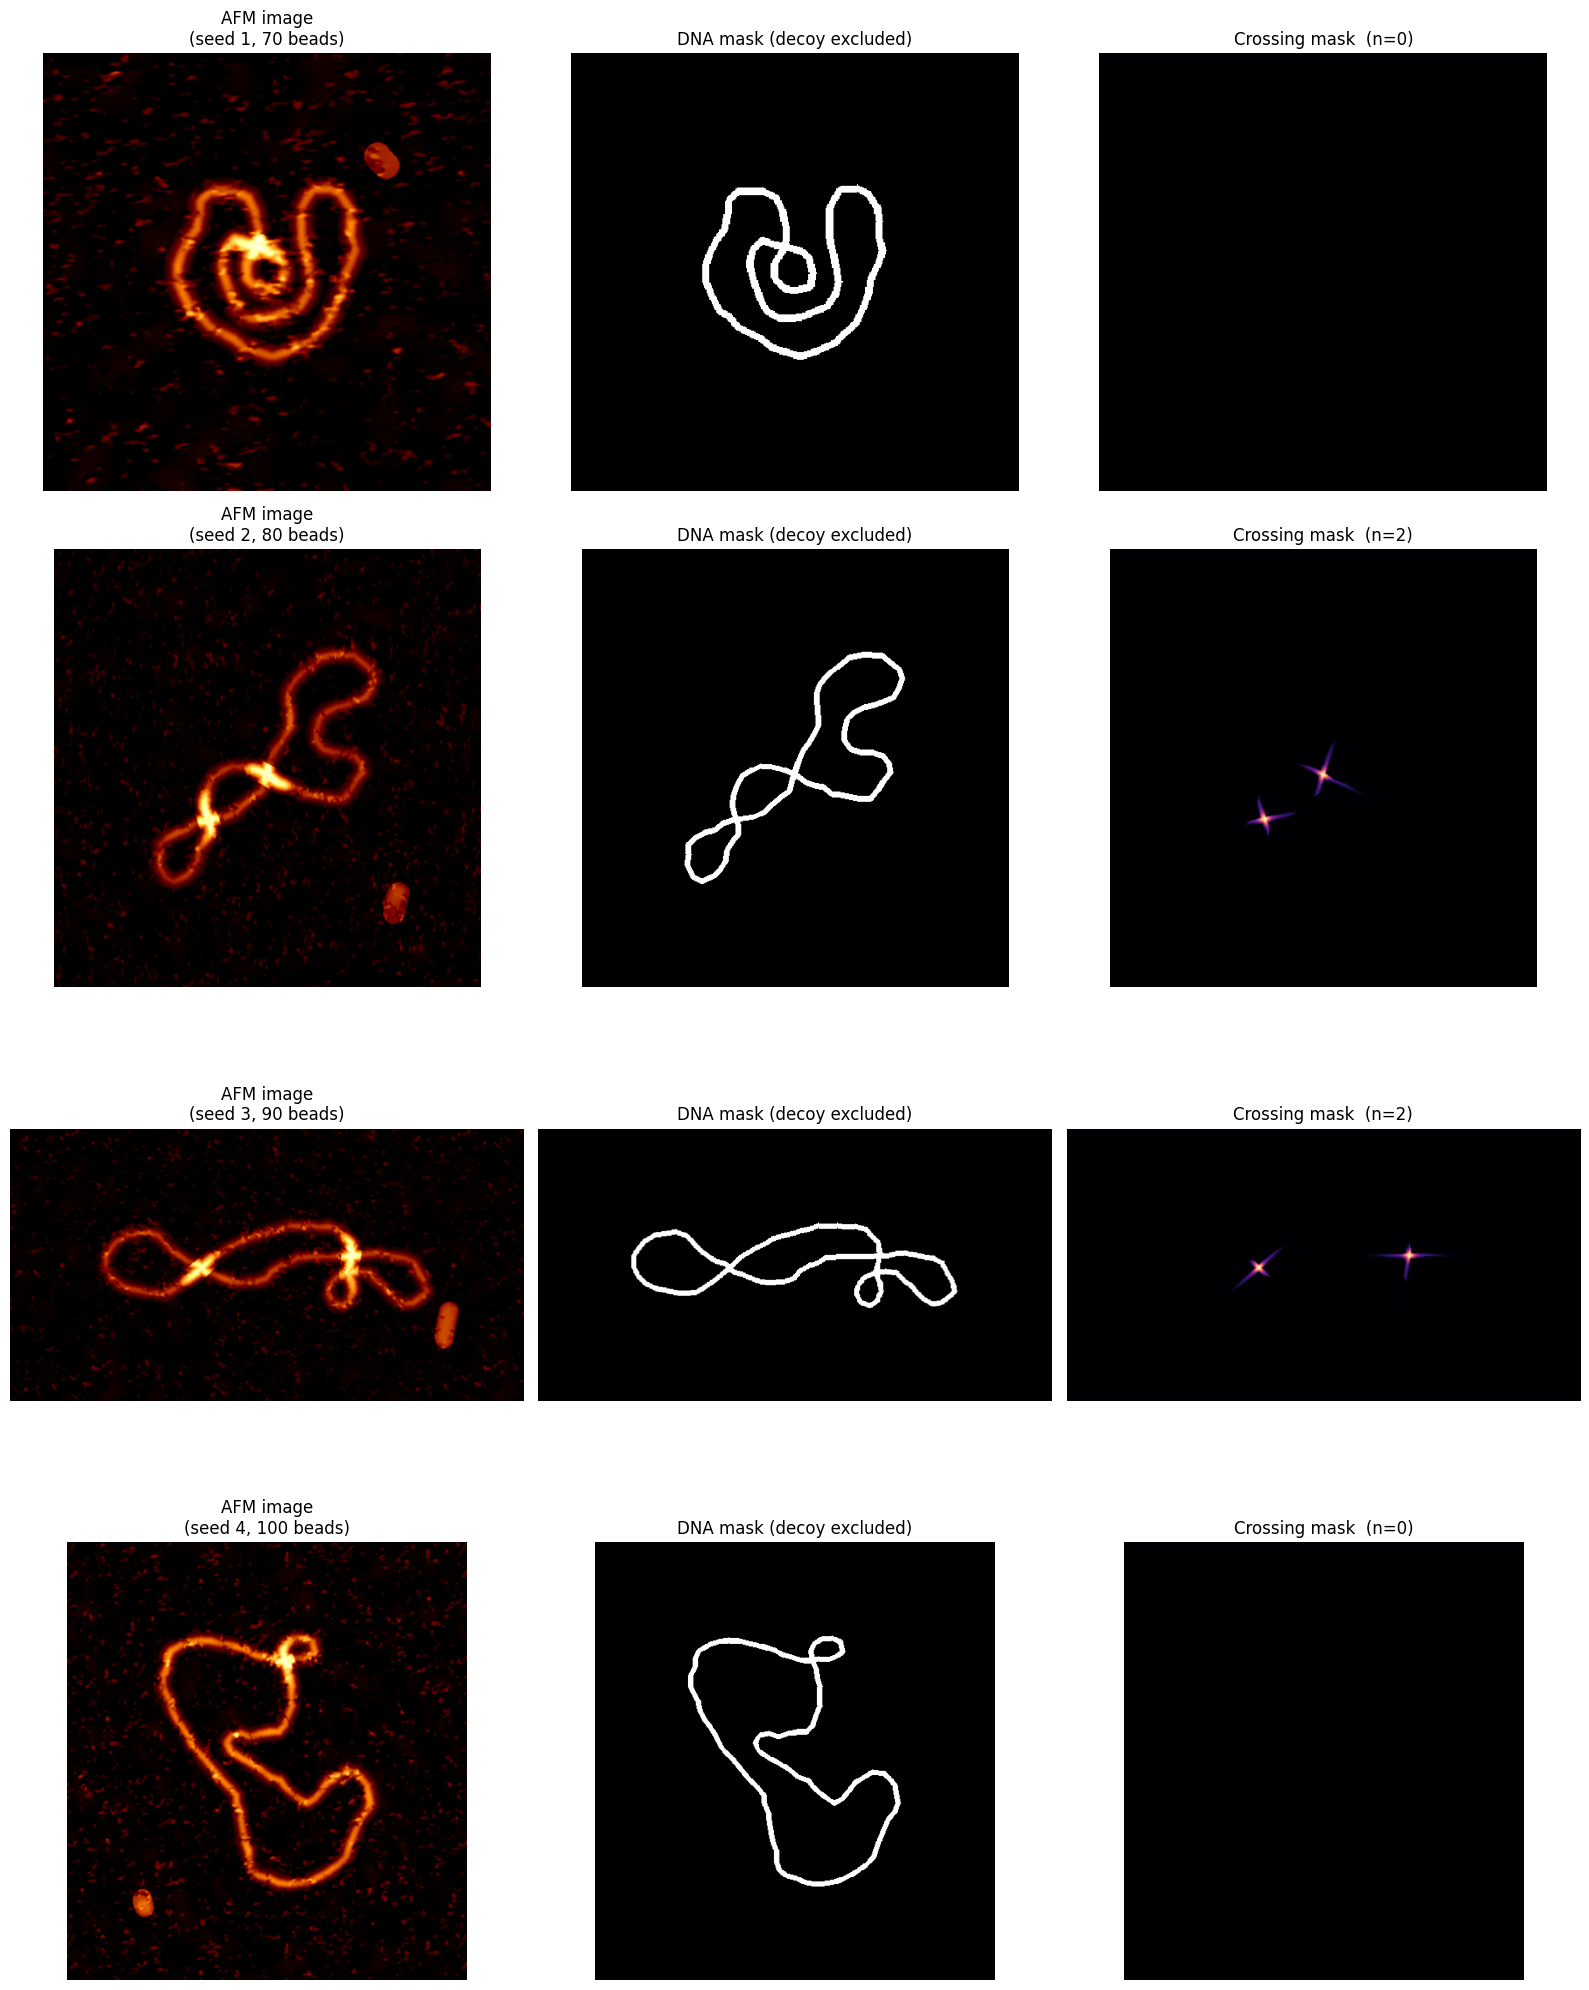

In [77]:
bead_counts = list(BEAD_COUNTS)
seeds       = [int(BASE_SEED + k) for k in range(len(bead_counts))]

samples = [
    generate_one_sample_multilength(
        seeds[i], n_beads=bead_counts[i],
        noise_source=noise_source, noise_asset=noise_asset, add_decoy=True
    )
    for i in range(len(bead_counts))
]
#---------Plotting-------------------------------------------------------------

fig, axes = plt.subplots(len(samples), 3, figsize=(16, 5 * len(samples)))

for r, s in enumerate(samples):
    extent = s["extent"]
    img    = s["afm_img"]

    print(f"\n{'='*20} SAMPLE {r+1} (Seed: {s['seed']}, "
          f"{s['n_beads']} beads) {'='*20}")
    print(f"Image window (nm): X=[{extent[0]:.1f}, {extent[1]:.1f}], "
          f"Y=[{extent[2]:.1f}, {extent[3]:.1f}]")

    if s.get("decoy_coords") is not None:
        d = s["decoy_coords"]
        print(f"Decoy XY bounds (nm): "
              f"X=[{d[:,0].min():.1f}, {d[:,0].max():.1f}], "
              f"Y=[{d[:,1].min():.1f}, {d[:,1].max():.1f}]")
        print(f"Decoy Z range (nm):   {d[:,2].min():.2f} – {d[:,2].max():.2f}")
        oob = (d[:,0].min() < extent[0] or d[:,0].max() > extent[1] or
               d[:,1].min() < extent[2] or d[:,1].max() > extent[3])
        print(" Decoy out-of-bounds!" if oob else "Decoy inside extent.")
        if d[:,2].max() < 0.1:
            print(" Decoy height ≈ 0")

    ax1, ax2, ax3 = axes[r]
    ext_list = list(extent)

    ax1.imshow(img,           cmap="afmhot", origin="lower", extent=ext_list)
    ax1.set_title(f"AFM image\n(seed {s['seed']}, {s['n_beads']} beads)")
    ax1.axis("off")

    ax2.imshow(s["dna_mask"], cmap="gray",   origin="lower", extent=ext_list)
    ax2.set_title("DNA mask (decoy excluded)")
    ax2.axis("off")

    ax3.imshow(s["cross_mask"], cmap="magma", origin="lower", extent=ext_list)
    ax3.set_title(f"Crossing mask  (n={s['n_crossings']})")
    ax3.axis("off")

plt.tight_layout()
plt.show()

## 13. Benchmarking

We also provide the option to benchmark the performance of the pipeline and to see estimates on how long it might take to generate the required amount of samples. This can be very useful to compare which system might be optimal for production of the dataset and how GPU acceleration can be used to improve the time needed for dataset generation.

In [ ]:
import time
import tracemalloc
import os
import platform
import psutil
import threading
import statistics

class _PeakMemTracker:
    """Track peak resident memory usage in a background thread.

    This helper periodically samples the current process RSS and stores the
    largest value observed during the tracked interval.

    Attributes
    ----------
    peak_mb : float
        Peak resident set size observed during tracking, in megabytes.
    """

    def __init__(self, poll_interval_s: float = 0.05) -> None:
        """Initialize the memory tracker.

        Parameters
        ----------
        poll_interval_s : float, optional
            Sampling interval in seconds, by default ``0.05``.
        """
        self._process = psutil.Process(os.getpid())
        self._poll_interval_s = float(poll_interval_s)
        self._stop_event = threading.Event()
        self._thread: threading.Thread | None = None
        self.peak_mb = 0.0

    def _run(self) -> None:
        """Continuously sample RSS until tracking is stopped."""
        while not self._stop_event.is_set():
            try:
                rss_mb = self._process.memory_info().rss / 1e6
                if rss_mb > self.peak_mb:
                    self.peak_mb = rss_mb
            except Exception:
                pass

            self._stop_event.wait(self._poll_interval_s)

    def start(self) -> None:
        """Start background memory tracking."""
        self._stop_event.clear()
        self._thread = threading.Thread(target=self._run, daemon=True)
        self._thread.start()

    def stop(self) -> None:
        """Stop background memory tracking."""
        self._stop_event.set()
        if self._thread is not None:
            self._thread.join()


def _bench_stages(
    seed: int,
    n_beads: int
) -> dict[str, float]:
    """Benchmark the major stages of one sample-generation pipeline run.

    Parameters
    ----------
    seed : int
        Random seed for the benchmarked sample.
    n_beads : int
        Number of beads in the benchmarked chain.

    Returns
    -------
    dict[str, float]
        Stage timings in seconds. Keys are:
        ``"1_chain_init"``, ``"2_md_relax"``, ``"3_crossing_detect"``,
        and ``"4_afm_render_masks"``.

    """

    seed = int(seed)
    n_beads = int(n_beads)

    timings: dict[str, float] = {}
    t0 = time.perf_counter()

    if USE_MD:
        coords0 = make_tangled_ring_initial(seed, n_beads=n_beads)
        timings["1_chain_init"] = time.perf_counter() - t0

        t0 = time.perf_counter()
        frames = run_md_relaxation(
            coords0,
            seed=seed,
            n_frames=N_FRAMES,
            steps_per_frame=STEPS_PER_FRAME,
        )
        timings["2_md_relax"] = time.perf_counter() - t0
    else:
        timings["1_chain_init"] = 0.0

        t0 = time.perf_counter()
        frames = make_ring_2d_persistent_initial(seed, n_beads=n_beads)
        timings["2_md_relax"] = time.perf_counter() - t0

    last_coords = frames[-1]

    t0 = time.perf_counter()
    crossings = find_polyline_crossings(last_coords[:, :2])
    timings["3_crossing_detect"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    chain = {
        "seed": seed,
        "n_beads": n_beads,
        "coords": last_coords,
        "crossings": crossings,
    }
    render_chain_and_masks(
        chain,
        noise_source="none",
        noise_asset=None,
    )
    timings["4_afm_render_masks"] = time.perf_counter() - t0

    return timings


def benchmark_pipeline(
    seed: int,
    n_beads: int,
    n_reps: int = 3,
    total_samples: int | None = None,
    print_report: bool = True,
) -> dict[str, Any]:
    """Benchmark the sample-generation pipeline and report timing statistics.

    This function prints a system profile, runs repeated benchmark passes for
    one representative sample configuration, tracks peak RSS memory usage, and
    estimates the total runtime for the full dataset.

    Parameters
    ----------
    seed : int
        Base random seed for the benchmark runs.
    n_beads : int
        Number of beads used in each benchmarked sample.
    n_reps : int, optional
        Number of benchmark repetitions, by default ``3``.
    total_samples : int or None, optional
        Total number of samples to use when projecting full runtime. If
        ``None``, the projection is omitted.
    print_report : bool, optional
        Whether to print the system and benchmark summary, by default ``True``.

    Returns
    -------
    dict[str, Any]
        Dictionary containing benchmark results, including wall times, stage
        timings, median runtime, peak RSS memory, and projected total runtime.

    Notes
    -----
    When ``USE_MD`` is enabled, the function also reports available OpenMM
    platforms and uses the same MD settings as the rest of the notebook.

    Examples
    --------
    >>> results = benchmark_pipeline(seed=0, n_beads=300, n_reps=3)
    >>> results["median_wall_time_s"] > 0
    True

    """

    seed = int(seed)
    n_beads = int(n_beads)
    n_reps = int(n_reps)

    cpu_logical = psutil.cpu_count(logical=True)
    available_ram_gb = psutil.virtual_memory().available / 1e9

    platforms = None
    active_platform = None
    if USE_MD:
        platforms = [
            openmm.Platform.getPlatform(i).getName()
            for i in range(openmm.Platform.getNumPlatforms())
        ]
        active_platform = (
            "CUDA" if "CUDA" in platforms else
            "OpenCL" if "OpenCL" in platforms else
            "CPU"
        )

    if print_report:
        print("=" * 62)
        print("  SYSTEM PROFILE")
        print("=" * 62)
        print(f"  OS              : {platform.system()} {platform.release()}")
        print(f"  CPU (logical)   : {cpu_logical} cores")
        print(f"  RAM available   : {available_ram_gb:.1f} GB")
        if USE_MD:
            print(f"  OpenMM Platforms: {platforms}")
            print(f"  Active Platform : {active_platform}")
        print(f"  Mode    : {'MD (OpenMM)' if USE_MD else 'Non-MD (2D Walk)'}")
        print()

        print("=" * 62)
        print("  RUNNING BENCHMARK")
        print("=" * 62)

    wall_times: list[float] = []
    stage_timings: list[dict[str, float]] = []

    mem_tracker = _PeakMemTracker()
    mem_tracker.start()

    for rep in range(n_reps):
        rep_seed = seed + rep
        t0 = time.perf_counter()
        rep_stage_timings = _bench_stages(rep_seed, n_beads)
        elapsed = time.perf_counter() - t0

        wall_times.append(elapsed)
        stage_timings.append(rep_stage_timings)

        if print_report:
            print(f"  Rep {rep + 1}/{n_reps}: {elapsed:.2f}s")

    mem_tracker.stop()

    median_wall_time_s = statistics.median(wall_times)
    mean_wall_time_s = statistics.mean(wall_times)

    stage_keys = stage_timings[0].keys() if stage_timings else []
    median_stage_times_s = {
        key: statistics.median(t[key] for t in stage_timings)
        for key in stage_keys
    }
    ts = total_samples
    projected_total_hours = None
    if ts is not None:
        projected_total_hours = (median_wall_time_s * int(ts)) / 3600

    if print_report:
        print("=" * 62)
        print(f"  Median Wall Time: {median_wall_time_s:.2f} s")
        print(f"  Mean Wall Time  : {mean_wall_time_s:.2f} s")
        print(f"  Peak RAM (RSS)  : {mem_tracker.peak_mb:.1f} MB")
        if projected_total_hours is not None:
            print(
                f"  Projected Total : {projected_total_hours:.1f} hours "
                f"for {int(ts)} samples"
            )
        print("=" * 62)

    return {
        "seed": seed,
        "n_beads": n_beads,
        "n_reps": n_reps,
        "mode": "md" if USE_MD else "non_md",
        "cpu_logical": cpu_logical,
        "available_ram_gb": available_ram_gb,
        "openmm_platforms": platforms,
        "active_platform": active_platform,
        "wall_times_s": wall_times,
        "stage_timings_s": stage_timings,
        "median_wall_time_s": median_wall_time_s,
        "mean_wall_time_s": mean_wall_time_s,
        "median_stage_times_s": median_stage_times_s,
        "peak_rss_mb": mem_tracker.peak_mb,
        "total_samples": int(ts) if ts is not None else None,
        "projected_total_hours": projected_total_hours,
    }


BENCH_SEED = int(BASE_SEED)
BENCH_N_BEADS = int(BEAD_COUNTS[0])
BENCH_REPS = 3

benchmark_results = benchmark_pipeline(
    seed=BENCH_SEED,
    n_beads=BENCH_N_BEADS,
    n_reps=BENCH_REPS,
    total_samples=int(N_SAMPLES) * len(BEAD_COUNTS),
    print_report=True,
)

## 14.Dataset Generation

Finally, we are ready to generate the full dataset. The amount of samples and the lenghts of the chains is defined in the global variables and will be referenced here.
This notebook generates the full dataset (default: 1000 samples × 4 chain lengths). There is added functionality to preview the images for a gives set or range of indices.


Progress is printed every 10 samples and a `manifest.csv` tracks all file paths.

In [78]:
import csv
import json
import os
import subprocess
import sys
import time
from concurrent.futures import TimeoutError as FutureTimeoutError

import matplotlib.pyplot as plt
import numpy as np

try:
    from joblib.externals.loky import get_reusable_executor
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "joblib"]
    )
    from joblib.externals.loky import get_reusable_executor


SAMPLE_TIMEOUT_S = 10.0 #How long to wait for every seed before skipping
_SAMPLE_EXECUTOR = None


def get_sample_executor():
    """Return the reusable process executor for sample generation.

    The executor runs sample generation in a separate Python process.
    This makes the timeout independent of operating-system-specific
    signal handling, so it works on Linux, macOS, and Windows.

    Returns
    -------
    loky.reusable_executor._ReusablePoolExecutor
        Executor used to run one simulation task at a time.

    Notes
    -----
    The executor is created only when it is actually needed. After that, the
    same executor is reused for future samples. That avoids creating a
    brand-new process for every seed, which would be much slower.

    """

    global _SAMPLE_EXECUTOR

    if _SAMPLE_EXECUTOR is None:
        _SAMPLE_EXECUTOR = get_reusable_executor(max_workers=1)

    return _SAMPLE_EXECUTOR


def reset_sample_executor():
    """Shut down and recreate the sample-generation process pool.

    This is called after a timeout or worker-side exception. Killing the
    worker prevents a long-running OpenMM calculation from continuing in
    the background after the seed has already been skipped.

    Returns
    -------
    None

    """

    global _SAMPLE_EXECUTOR

    if _SAMPLE_EXECUTOR is not None:
        _SAMPLE_EXECUTOR.shutdown(
            wait=False,
            kill_workers=True,
        )

    _SAMPLE_EXECUTOR = None


def generate_sample_worker(seed, n_beads, add_decoy):
    """Generate one DNA sample inside the worker process.

    Parameters
    ----------
    seed : int
        Random seed used by the DNA simulator.
    n_beads : int
        Number of beads in the simulated DNA chain.
    add_decoy : bool
        Whether an additional decoy DNA chain should be included.

    Returns
    -------
    dict
        Sample dictionary returned by ``generate_one_sample_multilength``.
        It is expected to contain ``afm_img``, ``dna_mask``,
        ``cross_mask``, ``seed``, ``n_beads``, ``extent``, and
        ``n_crossings``.

    """

    return generate_one_sample_multilength(
        int(seed),
        n_beads=int(n_beads),
        noise_source=noise_source,
        noise_asset=noise_asset,
        add_decoy=bool(add_decoy),
    )


def generate_sample_with_timeout(seed, n_beads, add_decoy):
    """Generate and validate one DNA sample with a time limit.

    The simulation is submitted to a separate process. If it does not
    finish within ``SAMPLE_TIMEOUT_S`` seconds, the worker is killed and
    the caller can skip the seed. Exceptions raised by OpenMM or by the
    simulation code are also propagated so the seed can be skipped.

    Parameters
    ----------
    seed : int
        Candidate random seed for the sample.
    n_beads : int
        Number of beads to simulate.
    add_decoy : bool
        Whether to add a decoy chain to this sample.

    Returns
    -------
    dict
        Validated generated sample.

    Raises
    ------
    TimeoutError
        If sample generation takes longer than ``SAMPLE_TIMEOUT_S``.
    ValueError
        If one of the output arrays contains non-finite values.
    Exception
        Re-raises any exception from the simulator.

    """

    executor = get_sample_executor()
    start_time = time.perf_counter()

    future = executor.submit(
        generate_sample_worker,
        int(seed),
        int(n_beads),
        bool(add_decoy),
    )

    try:
        sample = future.result(timeout=SAMPLE_TIMEOUT_S)
    except FutureTimeoutError as exc:
        future.cancel()
        reset_sample_executor()
        raise TimeoutError("Simulation took too long!") from exc
    except Exception:
        future.cancel()
        reset_sample_executor()
        raise

    elapsed = time.perf_counter() - start_time

    if elapsed > SAMPLE_TIMEOUT_S:
        reset_sample_executor()
        raise TimeoutError("Simulation took too long!")

    for key in ("afm_img", "dna_mask", "cross_mask"):
        arr = np.asarray(sample[key])
        if not np.all(np.isfinite(arr)):
            raise ValueError(f"Non-finite values found in {key}")

    return sample


def save_preview_png(sample, idx, preview_dir):
    """Save visual PNG file previews for generated samples.

    The preview is useful for quickly checking that the generated AFM
    image looks reasonable without opening the NumPy arrays manually.
    This function only saves the AFM image, not the masks.

    Parameters
    ----------
    sample : dict
        Generated sample dictionary containing ``afm_img``.
    idx : int
        Dataset index used to name the preview file.
    preview_dir : str
        Directory where preview PNG files are written.

    Returns
    -------
    str
        Path to the written preview PNG file.

    """

    preview_path = os.path.join(
        preview_dir,
        f"preview_{idx:04d}.png",
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(sample["afm_img"], cmap="gray")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(preview_path, dpi=150)
    plt.close()

    return preview_path

manifest_path = os.path.join(OUT_DIR, "manifest.csv")
print(f"Starting dataset generation: {N_SAMPLES} samples...")

# ─────────────────────────────────────────────────────────────────────────────
# Choose indices to export as PNG previews.
# Examples:
#   set(range(4, 41))       -> export indices 4 through 40 inclusive
#   {0, 3, 10, 25}          -> export only specific indices
#   set()                   -> export none
EXPORT_PREVIEW_PNGS = False
PREVIEW_PNG_INDICES = set(range(4, 8))
PREVIEW_PNG_DIR = os.path.join(OUT_DIR, "preview_pngs")
# ─────────────────────────────────────────────────────────────────────────────

for subdir in ("images", "dna_masks", "cross_masks", "meta"):
    os.makedirs(os.path.join(OUT_DIR, subdir), exist_ok=True)

if EXPORT_PREVIEW_PNGS:
    os.makedirs(PREVIEW_PNG_DIR, exist_ok=True)

header = [
    "index",
    "seed",
    "n_beads",
    "bond_length",
    "persistence_bonds",
    "image_npy",
    "dna_mask_npy",
    "cross_mask_npy",
    "meta_npz",
    "n_crossings",
    "has_decoy",
    "afm_params_json",
]

with open(manifest_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(header)

    idx = 0
    current_seed = int(BASE_SEED)

    while idx < int(N_SAMPLES):
        n_beads = int(BEAD_COUNTS[idx % len(BEAD_COUNTS)])
        add_decoy = bool(idx % 4 == 0)

        try:
            sample = generate_sample_with_timeout(
                current_seed,
                n_beads,
                add_decoy,
            )

            img_path = os.path.join("images", f"img_{idx:04d}.npy")
            dna_path = os.path.join("dna_masks", f"dna_{idx:04d}.npy")
            cross_path = os.path.join(
                "cross_masks",
                f"cross_{idx:04d}.npy",
            )
            meta_path = os.path.join("meta", f"meta_{idx:04d}.npz")

            np.save(os.path.join(OUT_DIR, img_path), sample["afm_img"])
            np.save(os.path.join(OUT_DIR, dna_path), sample["dna_mask"])
            np.save(
                os.path.join(OUT_DIR, cross_path),
                sample["cross_mask"],
            )

            np.savez_compressed(
                os.path.join(OUT_DIR, meta_path),
                seed=sample["seed"],
                n_beads=int(sample["n_beads"]),
                extent=sample["extent"],
                n_crossings=sample["n_crossings"],
                has_decoy=add_decoy,
                bond_length=BOND_LENGTH,
                persistence=PERSISTENCE_BONDS,
            )

            afm_params = globals().get(
                "AF_KW",
                globals().get("AFM_KW", {}),
            )

            writer.writerow(
                [
                    idx,
                    current_seed,
                    n_beads,
                    BOND_LENGTH,
                    PERSISTENCE_BONDS,
                    img_path,
                    dna_path,
                    cross_path,
                    meta_path,
                    sample["n_crossings"],
                    add_decoy,
                    json.dumps(afm_params, default=str),
                ]
            )

            if EXPORT_PREVIEW_PNGS and idx in PREVIEW_PNG_INDICES:
                save_preview_png(
                    sample,
                    idx,
                    PREVIEW_PNG_DIR,
                )

            if (idx + 1) % 10 == 0:
                print(f"Progress: {idx + 1}/{N_SAMPLES}")

            idx += 1
            current_seed += 1

        except Exception as exc:
            print(
                f"Skipping seed {current_seed} due to "
                f"{type(exc).__name__}: {exc}"
            )
            current_seed += 1
            continue

reset_sample_executor()

print("\nDone. Dataset written to:", OUT_DIR)
print("Manifest:", manifest_path)

Starting dataset generation: 50 samples...
Progress: 10/50
Progress: 20/50
Progress: 30/50
Progress: 40/50
Skipping seed 42 due to OpenMMException: Energy or force at minimization starting point is infinite or NaN.
Progress: 50/50

Done. Dataset written to: dna_dataset_100_4lengths_MD
Manifest: dna_dataset_100_4lengths_MD/manifest.csv


## 15. DeepTrack source connection and Deeplay U-Net

Run the dataset-generation cell above first, or point `OUT_DIR` and
`manifest_path` to an already generated dataset. This section reads the
manifest written by the simulation notebook, creates DeepTrack sources,
loads the `.npy` files lazily, and trains a simple Deeplay U-Net.

In [15]:
# Install these in a fresh Colab/Kaggle runtime.
!pip install deeptrack deeplay lightning pandas pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.6/195.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.7/176.7 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 84.5 MB/s eta 0:00:00
  Created wheel for lazy_import: filename=lazy_import-0.2.2-py2.py3-none-any.whl s

...and then we load the required dependencies and set up the model hyperparameters...

In [42]:
from pathlib import Path
from typing import Any

import random

import deeplay as dl
import deeptrack as dt
import lightning as L
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset

SEED = 7 #Seed for reproducibility

L.seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

TARGET_SIZE = int(NX)
VAL_FRACTION = 0.20 #This corresponds to a 80:20 split of test and validation

MODEL_CFG = dict(
    in_channels=1,
    channels=[16, 32, 64, 128],
    out_channels=2,
)

TRAIN_CFG = dict(
    batch_size=4,
    num_workers=0,
    max_epochs=50,          #number of training epochs
    lr=1e-3,                #Learning rate for the training
    dna_pos_weight=1.0,
    dna_loss_weight=1.0,
    cross_loss_weight=0.10,
    dice_smooth=1.0,
)

INFO: Seed set to 7
INFO:lightning.fabric.utilities.seed:Seed set to 7


### 16. Build DeepTrack sources from the simulation manifest

The original manifest columns are `image_npy`, `dna_mask_npy`, and
`cross_mask_npy`. They are relative paths, so the loader joins them with
`OUT_DIR` before reading the files.

In [79]:
IMAGE_COLUMNS = (
    'image_npy',
    'image_path',
    'img_path',
    'afm_path',
)

DNA_COLUMNS = (
    'dna_mask_npy',
    'dna_path',
    'mask_path',
    'label_path',
)

CROSS_COLUMNS = (
    'cross_mask_npy',
    'cross_path',
    'crossing_path',
)


def find_column(
    frame: pd.DataFrame,
    candidates: tuple[str, ...],
    required: bool = True,
) -> str | None:
    """Return the first matching column in a manifest.

   Parameters
    ----------
    frame : pd.DataFrame
        The dataframe to search for columns.
    candidates : tuple[str, ...]
        A tuple of potential column names to match.
    required : bool, optional
        If True, raises a KeyError if no matching column is found.
        Defaults to True.

    Returns
    -------
    str | None
        The name of the first matching column found, or None if no
        match is found and `required` is False.

    Raises
    ------
    KeyError
        If `required` is True and none of the `candidates` exist in `frame`.

    """

    for column in candidates:
        if column in frame.columns:
            return column

    if required:
        names = ', '.join(candidates)
        raise KeyError(f'Manifest is missing one of: {names}')

    return None


def resolve_data_path(value: Any, root: Path) -> Path:
    """Resolve an absolute or OUT_DIR-relative file path.

    Parameters
    ----------
    value: any
        The value to resolve.
    root: Path
        The root directory.

    Returns
    -------
    Path
        The resolved path.

    """

    path = Path(str(value))

    if path.is_absolute():
        return path

    return Path(root) / path


def manifest_to_records(
    frame: pd.DataFrame,
    root: Path,
) -> list[dict[str, str]]:
    """Convert the simulation manifest to DeepTrack source rows.

    Parameters
    ----------
    frame: pd.dataframe
        The simulation manifest.
    root: Path
        The root directory.

    Returns
    -------
    list[dict[str, str]]
        A list of DeepTrack source rows.

    """

    image_col = find_column(frame, IMAGE_COLUMNS)
    dna_col = find_column(frame, DNA_COLUMNS)
    cross_col = find_column(frame, CROSS_COLUMNS, required=False)
    records = []
    missing = []

    for row_index, row in frame.iterrows():
        image_path = resolve_data_path(row[image_col], root)
        dna_path = resolve_data_path(row[dna_col], root)
        cross_path = ''

        if cross_col is not None and not pd.isna(row[cross_col]):
            cross_path = str(resolve_data_path(row[cross_col], root))

        if not image_path.exists():
            missing.append(str(image_path))
            continue

        if not dna_path.exists():
            missing.append(str(dna_path))
            continue

        if cross_path and not Path(cross_path).exists():
            missing.append(cross_path)
            cross_path = ''

        sample_id = str(row.get('index', row_index))
        records.append(
            dict(
                id=sample_id,
                image_path=str(image_path),
                dna_path=str(dna_path),
                cross_path=cross_path,
            )
        )

    if missing:
        preview = '\n'.join(missing[:10])
        raise FileNotFoundError(
            'Some manifest files could not be found. First missing files:\n'
            f'{preview}'
        )

    if not records:
        raise RuntimeError('No valid samples were found in the manifest.')

    return records


def split_records(
    records: list[dict[str, str]],
    val_fraction: float,
    seed: int,
) -> tuple[list[dict[str, str]], list[dict[str, str]]]:
    """Split records into train and validation lists.

    Parameters
    ----------
    records: list
      A list of DeepTrack source rows.
    val_fraction: float
      The fraction for the split between training and validation.
    seed: int
      Random seed for reproducibility.

    Returns
    -------
    tuple[list[dict[str, str]], list[dict[str, str]]]
      A tuple of train and validation lists.

    """

    if len(records) < 2:
        return records, records

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(records))
    n_val = max(1, int(round(len(records) * val_fraction)))
    n_val = min(n_val, len(records) - 1)
    val_index = set(int(i) for i in order[:n_val])
    train_rows = []
    val_rows = []

    for index, record in enumerate(records):
        if index in val_index:
            val_rows.append(record)
        else:
            train_rows.append(record)

    return train_rows, val_rows


manifest_file = Path(manifest_path)
dataset_root = Path(OUT_DIR)

if not manifest_file.exists():
    raise FileNotFoundError(
        'Run the dataset-generation cell first, or set manifest_path to an '
        f'existing manifest. Current value: {manifest_file}'
    )

manifest_df = pd.read_csv(manifest_file)
all_records = manifest_to_records(manifest_df, dataset_root)
train_records, val_records = split_records(
    all_records,
    VAL_FRACTION,
    SEED,
)

train_source = dt.sources.Source(samples=train_records)
val_source = dt.sources.Source(samples=val_records)

print('Total samples:', len(all_records))
print('Training samples:', len(train_source))
print('Validation samples:', len(val_source))
print('First source row:', train_records[0])

Total samples: 50
Training samples: 40
Validation samples: 10
First source row: {'id': '1', 'image_path': 'dna_dataset_100_4lengths_MD/images/img_0001.npy', 'dna_path': 'dna_dataset_100_4lengths_MD/dna_masks/dna_0001.npy', 'cross_path': 'dna_dataset_100_4lengths_MD/cross_masks/cross_0001.npy'}


### 17. Lazy `.npy` loading pipeline

The source stores only file paths. `dt.Value(source.samples)` resolves the
current manifest row, and `dt.Lambda` loads the image and masks lazily. All
flipped or rotated arrays are converted with `np.ascontiguousarray`, which
prevents negative-stride errors when creating PyTorch tensors.

In [80]:
def load_array(path: str | Path) -> np.ndarray:
    """Load a NumPy array or image file as a 2-D float32 array.

    Parameters
    ----------
    path: str | Path
      The path to the array or image file.

    Returns
    -------
    np.ndarray
      The loaded array.

    """

    path = Path(path)

    if path.suffix.lower() == '.npy':
        array = np.load(path)
    else:
        with Image.open(path) as image:
            array = np.asarray(image)

    array = np.asarray(array)

    if array.ndim == 3:
        array = array[..., :3].mean(axis=-1)

    array = np.squeeze(array)
    return np.asarray(array, dtype=np.float32)


def normalize_afm(
    image: np.ndarray,
    bg_q: float = 70.0,
    high_q: float = 99.95,
) -> np.ndarray:
    """Normalize an AFM height map using robust percentiles.

    This function normalizes the image by converting the pixels below the 70th
    percentile to 0 and everything above 99.95th percentile is mapped to 1.

    Parameters
    ----------
    image: np.ndarray
      The height map to normalize.
    bg_q: float
      The percentile for the background. Defaults to 70.
    high_q: float
      The percentile for the foreground. Defaults to 99.95.

    Returns
    -------
    np.ndarray
      The normalized height map.

    """

    array = np.asarray(image, dtype=np.float32)
    array = np.nan_to_num(array, copy=False)
    low = float(np.percentile(array, bg_q))
    high = float(np.percentile(array, high_q))
    scale = max(high - low, 1e-6)
    array = (array - low) / scale
    return np.clip(array, 0.0, 1.0).astype(np.float32)


def resize_and_pad_np(
    array: np.ndarray,
    target_size: int,
    mode: str,
) -> np.ndarray:
    """Resize an array isotropically and pad it to a square.

    Parameters
    ----------
    array: np.ndarray
      The image for resizing if necessary.
    target_size: int
      the size of the required image.
    mode: str
      The resize mode.

    Returns
    -------
    np.ndarray
      The resized array.

    """

    array = np.asarray(array, dtype=np.float32)
    array = np.nan_to_num(np.squeeze(array), copy=False)
    array = np.ascontiguousarray(array)
    height, width = array.shape[-2:]
    target = int(target_size)
    scale = min(target / height, target / width)
    new_h = max(1, int(round(height * scale)))
    new_w = max(1, int(round(width * scale)))
    tensor = torch.from_numpy(array)[None, None].float()
    kwargs: dict[str, Any] = dict(size=(new_h, new_w), mode=mode)

    if mode in {'bilinear', 'bicubic'}:
        kwargs['align_corners'] = False

    resized = F.interpolate(tensor, **kwargs)[0, 0].numpy()
    canvas = np.zeros((target, target), dtype=np.float32)
    top = (target - new_h) // 2
    left = (target - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized
    return np.ascontiguousarray(canvas)


def augment_triplet(
    image: np.ndarray,
    dna: np.ndarray,
    cross: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Apply the same simple geometric augmentation to all arrays.

    Parameters
    ----------
    image: np.ndarray
      The image to augment.
    dna: np.ndarray
      The DNA mask to augment.
    cross: np.ndarray
      The crossing mask to augment.

    Returns
    -------
    tuple[np.ndarray, np.ndarray, np.ndarray]
      The augmented arrays.

    """

    if random.random() < 0.5:
        image = np.fliplr(image)
        dna = np.fliplr(dna)
        cross = np.fliplr(cross)

    if random.random() < 0.5:
        image = np.flipud(image)
        dna = np.flipud(dna)
        cross = np.flipud(cross)

    k = random.randint(0, 3)
    if k:
        image = np.rot90(image, k)
        dna = np.rot90(dna, k)
        cross = np.rot90(cross, k)

    return (
        np.ascontiguousarray(image),
        np.ascontiguousarray(dna),
        np.ascontiguousarray(cross),
    )


def load_sample_factory(
    target_size: int = 512,
    augment: bool = False,
):
    """Return a DeepTrack Lambda function for one manifest row.

    Parameters
    ----------
    target_size : int
      The target size for the images and masks. Defaults to 512.
    augment: bool
      Whether to apply geometric augmentation. Defaults to False.

    Returns
    -------
    dt.Lambda

    """

    def load_sample(sample: dict[str, str]):
        image = load_array(sample['image_path'])
        dna = load_array(sample['dna_path'])
        image = normalize_afm(image)
        dna = (dna > 0.5).astype(np.float32)

        if sample.get('cross_path'):
            cross = load_array(sample['cross_path'])
            cross = np.nan_to_num(cross, copy=False)
            max_cross = float(np.max(cross))
            if max_cross > 1.0:
                cross = cross / max_cross
            cross = np.clip(cross, 0.0, 1.0).astype(np.float32)
        else:
            cross = np.zeros_like(dna, dtype=np.float32)

        if augment:
            image, dna, cross = augment_triplet(image, dna, cross)

        image = resize_and_pad_np(image, target_size, 'bilinear')
        dna = resize_and_pad_np(dna, target_size, 'nearest')
        cross = resize_and_pad_np(cross, target_size, 'bilinear')
        dna = (dna > 0.5).astype(np.float32)
        cross = np.clip(cross, 0.0, 1.0).astype(np.float32)
        image = np.ascontiguousarray(image[None, :, :])
        target = np.stack([dna, cross], axis=0)
        target = np.ascontiguousarray(target.astype(np.float32))
        return image.astype(np.float32), target

    return load_sample


def build_pipeline(source, target_size: int, augment: bool):
    """Create a DeepTrack pipeline from a source of manifest rows.

    Parameters
    ----------
    source: dt.Source
      The source of manifest rows.
    target_size: int
      The target size for the images and masks.
    augment: bool
      Whether to apply geometric augmentation.

    Returns
    -------
    dt.Pipeline

    """

    sample_value = dt.Value(source.samples)
    loader = dt.Lambda(
        function=load_sample_factory,
        target_size=target_size,
        augment=augment,
    )
    return sample_value >> loader

In [81]:
class DeepTrackSourceDataset(Dataset):
    """PyTorch dataset backed by a DeepTrack source and pipeline.

    This dataset connects a DeepTrack ``Source`` to a PyTorch-compatible
    dataset interface. Each item is generated by evaluating a DeepTrack
    pipeline on one source entry. The pipeline is expected to return an
    image and a two-channel target array.

    The first target channel should contain the DNA segmentation mask.
    The second target channel should contain the crossing target.

    Parameters
    ----------
    source : deeptrack.sources.Source
        DeepTrack source containing one entry per sample.
    target_size : int
        Final spatial size used for image and target tensors.
    augment : bool
        Whether to apply training-time augmentation in the pipeline.

    Attributes
    ----------
    source : deeptrack.sources.Source
        Source object used to index sample metadata or paths.
    pipeline : deeptrack.Feature
        DeepTrack pipeline built from ``source``, ``target_size``, and
        ``augment``.
    """

    def __init__(self, source, target_size: int, augment: bool):
        """Initialize the dataset and build the DeepTrack pipeline.

        Parameters
        ----------
        source : deeptrack.sources.Source
            DeepTrack source containing one entry per sample.
        target_size : int
            Final spatial size used for image and target tensors.
        augment : bool
            Whether to apply training-time augmentation in the pipeline.
        """
        self.source = source
        self.pipeline = build_pipeline(source, target_size, augment)

    def __len__(self) -> int:
        """Return the number of samples in the DeepTrack source.

        Returns
        -------
        int
            Number of source entries available to the dataset.
        """
        return len(self.source)

    @staticmethod
    def _to_tensor(array: np.ndarray) -> torch.Tensor:
        """Convert an array-like object to a contiguous float tensor.

        This function also replaces NaN and infinite values with finite
        numbers and ensures the array has positive strides. The positive
        stride conversion is important after NumPy operations such as
        flips or rotations, which can otherwise create views with
        negative strides that PyTorch cannot convert directly.

        Parameters
        ----------
        array : np.ndarray
            Array-like image or target returned by the DeepTrack
            pipeline.

        Returns
        -------
        torch.Tensor
            Contiguous ``float32`` tensor.

        """

        array = np.asarray(array, dtype=np.float32)
        array = np.nan_to_num(array, copy=False)
        array = np.ascontiguousarray(array)
        return torch.from_numpy(array).float()

    def __getitem__(self, index: int):
        """Return one image-target pair from the DeepTrack pipeline.

        Parameters
        ----------
        index : int
            Index of the source entry to evaluate.

        Returns
        -------
        tuple[torch.Tensor, torch.Tensor]
            Image tensor and target tensor. The target tensor is expected
            to contain two channels: DNA mask at channel 0 and crossing
            target at channel 1.

        Raises
        ------
        TypeError
            If the DeepTrack pipeline does not return ``(image, target)``.

        """

        self.pipeline.update()
        result = self.pipeline(self.source[index])

        if not isinstance(result, (tuple, list)) or len(result) != 2:
            raise TypeError("The pipeline must return (image, target).")

        image, target = result
        return self._to_tensor(image), self._to_tensor(target)


train_dataset = DeepTrackSourceDataset(
    train_source,
    TARGET_SIZE,
    augment=True,
)

val_dataset = DeepTrackSourceDataset(
    val_source,
    TARGET_SIZE,
    augment=False,
)

train_loader = dl.DataLoader(
    train_dataset,
    batch_size=int(TRAIN_CFG['batch_size']),
    shuffle=True,
    num_workers=int(TRAIN_CFG['num_workers']),
    pin_memory=torch.cuda.is_available(),
    persistent_workers=int(TRAIN_CFG['num_workers']) > 0,
)

val_loader = dl.DataLoader(
    val_dataset,
    batch_size=int(TRAIN_CFG['batch_size']),
    shuffle=False,
    num_workers=int(TRAIN_CFG['num_workers']),
    pin_memory=torch.cuda.is_available(),
    persistent_workers=int(TRAIN_CFG['num_workers']) > 0,
)

image_batch, target_batch = next(iter(train_loader))
print('image batch:', tuple(image_batch.shape), image_batch.dtype)
print('target batch:', tuple(target_batch.shape), target_batch.dtype)
print('target channels: DNA = 0, crossings = 1')

image batch: (4, 1, 512, 512) torch.float32
target batch: (4, 2, 512, 512) torch.float32
target channels: DNA = 0, crossings = 1


### Deeplay U-Net and multitask loss

The U-Net has one output head with two channels. Channel 0 is the DNA logit
map and channel 1 is the crossing logit map. DNA uses BCE-Dice loss;
crossings use a lower-weight MSE term after sigmoid activation.

In [82]:
def dice_loss_from_logits(
    logits: torch.Tensor,
    target: torch.Tensor,
    smooth: float = 1.0,
) -> torch.Tensor:
    """Soft Dice loss for binary segmentation logits.

    Parameters
    ----------
    logits: torch.tensor
      The model logits.
    target: torch.tensor
      The target masks.
    smooth: float
      Smoothing factor. Defaults to 1.0.

    Returns
    -------
    torch.tensor

    """

    prob = torch.sigmoid(logits)
    dims = tuple(range(1, prob.ndim))
    inter = torch.sum(prob * target, dim=dims)
    denom = torch.sum(prob, dim=dims) + torch.sum(target, dim=dims)
    dice = (2.0 * inter + smooth) / (denom + smooth)
    return 1.0 - dice.mean()


class DNACrossingLoss(nn.Module):
    """Compute DNA segmentation and crossing-prediction losses.

    This loss combines a BCE-Dice loss for the DNA segmentation channel
    with a weighted mean-squared-error loss for the crossing channel. The
    DNA loss is intended to dominate training, while the crossing loss can
    be kept as a weaker auxiliary objective.

    The prediction tensor is expected to contain two channels:

    - channel 0: DNA segmentation logits
    - channel 1: crossing logits

    The target tensor is expected to contain two matching channels:

    - channel 0: binary DNA segmentation mask
    - channel 1: crossing target mask or heatmap

    Parameters
    ----------
    dna_pos_weight : float, default=1.0
        Positive-class weight used by the DNA BCE loss. Values greater
        than 1.0 increase the penalty for missing DNA pixels.
    dna_loss_weight : float, default=1.0
        Multiplicative weight applied to the combined BCE-Dice DNA loss.
    cross_loss_weight : float, default=0.10
        Multiplicative weight applied to the crossing MSE loss. Lower
        values make the model focus more strongly on DNA segmentation.
    dice_smooth : float, default=1.0
        Smoothing constant used in the Dice loss to avoid division by
        zero and stabilize training on sparse masks.

    Attributes
    ----------
    dna_loss_weight : float
        Weight applied to the DNA segmentation loss.
    cross_loss_weight : float
        Weight applied to the crossing loss.
    dice_smooth : float
        Smoothing value used by ``dice_loss_from_logits``.
    dna_pos_weight : torch.Tensor
        Registered buffer containing the BCE positive-class weight. It is
        moved automatically with the module across CPU and GPU devices.

    """

    def __init__(
        self,
        dna_pos_weight: float = 1.0,
        dna_loss_weight: float = 1.0,
        cross_loss_weight: float = 0.10,
        dice_smooth: float = 1.0,
    ):
        """Initialize the combined DNA and crossing loss.

        Parameters
        ----------
        dna_pos_weight : float, default=1.0
            Positive-class weight for DNA pixels in the BCE component.
        dna_loss_weight : float, default=1.0
            Weight applied to the combined BCE-Dice DNA loss.
        cross_loss_weight : float, default=0.10
            Weight applied to the crossing MSE loss.
        dice_smooth : float, default=1.0
            Smoothing constant used in the Dice loss.

        """

        super().__init__()
        self.dna_loss_weight = float(dna_loss_weight)
        self.cross_loss_weight = float(cross_loss_weight)
        self.dice_smooth = float(dice_smooth)
        pos_weight = torch.tensor(float(dna_pos_weight))
        self.register_buffer("dna_pos_weight", pos_weight)

    def forward(
        self,
        pred: torch.Tensor,
        target: torch.Tensor,
    ) -> torch.Tensor:
        """Return the weighted sum of DNA and crossing losses.

        Parameters
        ----------
        pred : torch.Tensor
            Model output tensor with shape ``(B, 2, H, W)``. Channel 0 is
            interpreted as DNA logits, and channel 1 is interpreted as
            crossing logits.
        target : torch.Tensor
            Target tensor with shape ``(B, 2, H, W)``. Channel 0 should
            contain the DNA mask, and channel 1 should contain the
            crossing target.

        Returns
        -------
        torch.Tensor
            Scalar loss equal to the weighted DNA BCE-Dice loss plus the
            weighted crossing MSE loss.

        """

        dna_logits = pred[:, 0:1]
        cross_logits = pred[:, 1:2]
        target_dna = target[:, 0:1]
        target_cross = target[:, 1:2]
        pos_weight = self.dna_pos_weight.to(pred.device)

        bce = F.binary_cross_entropy_with_logits(
            dna_logits,
            target_dna,
            pos_weight=pos_weight,
        )
        dice = dice_loss_from_logits(
            dna_logits,
            target_dna,
            smooth=self.dice_smooth,
        )
        dna_loss = 0.5 * bce + 0.5 * dice

        cross_prob = torch.sigmoid(cross_logits)
        cross_loss = F.mse_loss(cross_prob, target_cross)

        return (
            self.dna_loss_weight * dna_loss
            + self.cross_loss_weight * cross_loss
        )

In [94]:
import torch
import torchmetrics


class DNADiceMetric(torchmetrics.Metric):
    """Compute DNA Dice score for the DNA output channel.

    This metric expects the model prediction to have two channels, where
    channel 0 contains DNA logits. The target is also expected to have two
    channels, where channel 0 contains the DNA mask.
    """

    full_state_update = False

    def __init__(self, smooth: float = 1.0):
        """Initialize the accumulated Dice statistics."""
        super().__init__()
        self.smooth = float(smooth)

        self.add_state(
            "intersection",
            default=torch.tensor(0.0),
            dist_reduce_fx="sum",
        )
        self.add_state(
            "pred_sum",
            default=torch.tensor(0.0),
            dist_reduce_fx="sum",
        )
        self.add_state(
            "target_sum",
            default=torch.tensor(0.0),
            dist_reduce_fx="sum",
        )

    def update(
        self,
        preds: torch.Tensor,
        target: torch.Tensor,
    ) -> None:
        """Update Dice statistics for one batch."""
        pred_dna = torch.sigmoid(preds[:, 0:1])
        pred_dna = (pred_dna > 0.5).float()
        target_dna = target[:, 0:1].float()

        self.intersection += torch.sum(pred_dna * target_dna)
        self.pred_sum += torch.sum(pred_dna)
        self.target_sum += torch.sum(target_dna)

    def compute(self) -> torch.Tensor:
        """Return the accumulated DNA Dice score."""
        numerator = 2.0 * self.intersection + self.smooth
        denominator = self.pred_sum + self.target_sum + self.smooth

        return numerator / denominator

...and now we build the U-net...

In [98]:
unet = dl.UNet2d(
    in_channels=int(MODEL_CFG['in_channels']),
    channels=list(MODEL_CFG['channels']),
    out_channels=int(MODEL_CFG['out_channels']),
    skip=dl.Cat(),
)

loss_fn = DNACrossingLoss(
    dna_pos_weight=float(TRAIN_CFG['dna_pos_weight']),
    dna_loss_weight=float(TRAIN_CFG['dna_loss_weight']),
    cross_loss_weight=float(TRAIN_CFG['cross_loss_weight']),
    dice_smooth=float(TRAIN_CFG['dice_smooth']),
)
dna_dice_metric = DNADiceMetric(
    smooth=float(TRAIN_CFG["dice_smooth"]),
)
unet_template = dl.Regressor(
    model=unet,
    loss=loss_fn,
    metrics=[dna_dice_metric],
    optimizer=dl.Adam(lr=float(TRAIN_CFG['lr'])),
).create()

unet_app = unet_template.create()
print(unet_app)

Regressor(
  (loss): DNACrossingLoss()
  (optimizer): Adam[Adam](lr=0.001)
  (train_metrics): MetricCollection(
    (DNADiceMetric): DNADiceMetric(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (DNADiceMetric): DNADiceMetric(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (DNADiceMetric): DNADiceMetric(),
    prefix=test
  )
  (model): UNet2d(
    (encoder): ConvolutionalEncoder2d(
      (blocks): LayerList(
        (0): Conv2dBlock(
          (layer): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (1): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (activation): ReLU()
        )
        (2): Conv2dBlock(
          (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
          (layer): Conv2d(32, 64, kernel_si

/usr/local/lib/python3.12/dist-packages/deeplay/module.py:830: RuntimeWarning: Module has already been built. Please only use one of `build` or `create`.
  warn(


### Train and validate

In [99]:
from lightning.pytorch.loggers import CSVLogger


max_epochs = int(TRAIN_CFG["max_epochs"])
logger = CSVLogger(save_dir="logs", name=f"train_{max_epochs}_epochs")
trainer = dl.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",
    devices="auto",
    precision="16-mixed" if torch.cuda.is_available() else "32-true",
    log_every_n_steps=10,
    logger=logger,
)

trainer.fit(unet_app,train_loader,val_loader)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ DNACrossingLoss  │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ UNet2d           │  526 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 526 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 526 K                                                                                                
Total estimated model params size (MB): 2                                                                          
Modules in train mode: 53                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

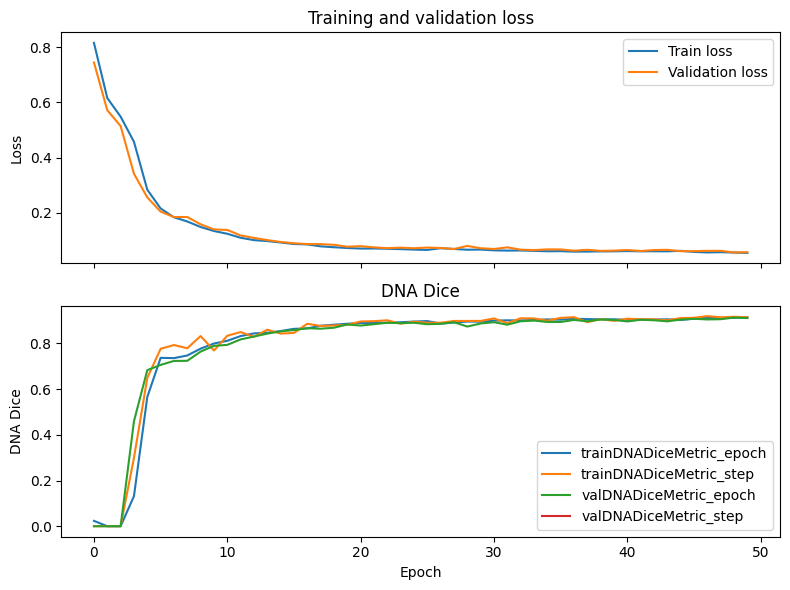

In [102]:
from pathlib import Path

import pandas as pd


def plot_training_metrics(metrics):
    """Plot total loss and DNA Dice curves by epoch.

    Parameters
    ----------
    metrics : pandas.DataFrame or dict
        Training metrics loaded from the CSV logger. The object should
        contain an ``epoch`` column and logged metric columns such as
        ``train_loss_epoch``, ``val_loss_epoch``,
        ``train_dna_dice_epoch``, and ``val_dna_dice_epoch``.

    """

    if not hasattr(metrics, "columns"):
        metrics = pd.DataFrame(metrics)

    metrics = metrics.copy()
    metrics = metrics.sort_values("epoch")
    metrics = metrics.groupby("epoch", as_index=False).last()

    fig, axs = plt.subplots(2, figsize=(8, 6), sharex=True)

    axs[0].plot(
        metrics["epoch"],
        metrics["train_loss_epoch"],
        label="Train loss",
    )
    axs[0].plot(
        metrics["epoch"],
        metrics["val_loss_epoch"],
        label="Validation loss",
    )
    axs[0].set_ylabel("Loss")
    axs[0].set_title("Training and validation loss")
    axs[0].legend()

    dice_columns = [
        col for col in metrics.columns
        if "dice" in col.lower()
    ]

    if dice_columns:
        for col in dice_columns:
            axs[1].plot(
                metrics["epoch"],
                metrics[col],
                label=col,
            )
        axs[1].legend()
    else:
        axs[1].text(
            0.5,
            0.5,
            "No DNA Dice metric was logged.",
            ha="center",
            va="center",
            transform=axs[1].transAxes,
        )

    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("DNA Dice")
    axs[1].set_title("DNA Dice")

    plt.tight_layout()
    plt.show()

metrics = pd.read_csv('/content/logs/train_50_epochs/version_2/metrics.csv')
plot_training_metrics(metrics)

### DNA-focused validation metrics

In [103]:
def dice_score_from_prob(
    prob: torch.Tensor,
    target: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-6,
) -> torch.Tensor:
    """Hard Dice score for binary DNA masks."""

    pred = (prob >= threshold).float()
    dims = tuple(range(1, pred.ndim))
    inter = torch.sum(pred * target, dim=dims)
    denom = torch.sum(pred, dim=dims) + torch.sum(target, dim=dims)
    return ((2.0 * inter + eps) / (denom + eps)).mean()


def iou_score_from_prob(
    prob: torch.Tensor,
    target: torch.Tensor,
    threshold: float = 0.5,
    eps: float = 1e-6,
) -> torch.Tensor:
    """Hard IoU score for binary DNA masks."""

    pred = (prob >= threshold).float()
    dims = tuple(range(1, pred.ndim))
    inter = torch.sum(pred * target, dim=dims)
    union = torch.sum((pred + target) > 0, dim=dims)
    return ((inter + eps) / (union + eps)).mean()


def evaluate_loader(model, loader, stage: str) -> dict[str, float]:
    """Evaluate DNA Dice, DNA IoU, and crossing MSE."""

    model.eval()
    device = next(model.parameters()).device
    totals = dict(loss=0.0, dna_dice=0.0, dna_iou=0.0)
    totals['cross_mse'] = 0.0
    count = 0

    with torch.no_grad():
        for image, target in loader:
            image = image.to(device)
            target = target.to(device)
            pred = model(image)
            loss = loss_fn(pred, target)
            dna_prob = torch.sigmoid(pred[:, 0:1])
            cross_prob = torch.sigmoid(pred[:, 1:2])
            target_dna = target[:, 0:1]
            target_cross = target[:, 1:2]
            batch_size = int(image.shape[0])

            totals['loss'] += float(loss) * batch_size
            totals['dna_dice'] += float(
                dice_score_from_prob(dna_prob, target_dna)
            ) * batch_size
            totals['dna_iou'] += float(
                iou_score_from_prob(dna_prob, target_dna)
            ) * batch_size
            totals['cross_mse'] += float(
                F.mse_loss(cross_prob, target_cross)
            ) * batch_size
            count += batch_size

    metrics = {key: value / max(count, 1) for key, value in totals.items()}
    print(stage, metrics)
    return metrics


val_metrics = evaluate_loader(unet_app, val_loader, 'validation')

validation {'loss': 0.057230790704488756, 'dna_dice': 0.9115970373153687, 'dna_iou': 0.837764310836792, 'cross_mse': 0.0005211589159443974}


### Optional prediction preview

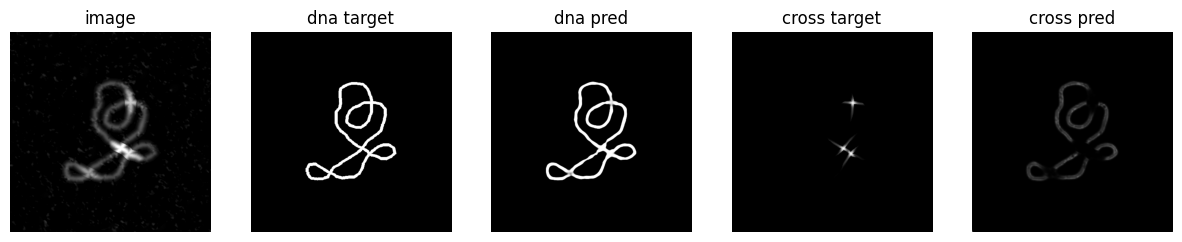

In [107]:
import matplotlib.pyplot as plt

def show_prediction(
    batch: tuple[torch.Tensor, ...],
    model: torch.nn.Module,
    index: int = 1,
) -> None:
    """Visualize the model's predictions against ground truth for one sample.

    This function takes a batch of data, performs an evaluation-mode forward
    pass using the provided model, and plots the image, the DNA segmentation
    (target vs. prediction), and the crossing detection (target vs. prediction)
    masks.

    Parameters
    ----------
    batch : tuple[torch.Tensor, ...]
        A tuple containing (images, targets).
        - images: Tensor of shape (B, C, H, W).
        - targets: Tensor of shape (B, 2, H, W) containing DNA and crossing
          masks.
    model : torch.nn.Module
        The neural network (e.g., U-Net or ResU-Net) used for inference.
    index : int, optional
        The index of the specific sample within the batch to visualize.
        Defaults to 1.

    Returns
    -------
    None
        The function displays a Matplotlib figure and does not return a value.

    Notes
    -----
    The function automatically handles device placement (CPU/GPU) by checking
    the model's parameters and applies a sigmoid activation to the model
    output to transform logits into probabilities.

    """

    image, target = batch
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        pred = model(image.to(device))
        dna_prob = torch.sigmoid(pred[:, 0:1]).cpu()
        cross_prob = torch.sigmoid(pred[:, 1:2]).cpu()

    panels = [
        image[index, 0].cpu(),
        target[index, 0].cpu(),
        dna_prob[index, 0],
        target[index, 1].cpu(),
        cross_prob[index, 0],
    ]
    titles = [
        'image',
        'dna target',
        'dna pred',
        'cross target',
        'cross pred',
    ]

    fig, axes = plt.subplots(1, len(panels), figsize=(15, 3))
    for ax, panel, title in zip(axes, panels, titles):
        ax.imshow(panel, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    plt.show()


batch = next(iter(val_loader))
show_prediction(batch, unet_app)

# 17. Evaluation on real data